# Imports

In [1]:
from pathlib import Path
from typing import Any, Dict, List, Tuple, List

import numpy as np
import pandas as pd

from scripts.model_registry import ModelRegistry
from scripts.shap import excecute_shap, extract_shap_importance

In [2]:
%load_ext autoreload
%autoreload 2

# Data loading

In [3]:
data_path = Path("data")

train_df = pd.read_csv(data_path / "titanic" / "train.csv")
test_df = pd.read_csv(data_path / "titanic" / "test.csv")

combined_df = pd.concat([train_df, test_df])

target = "Survived"

# Feature engineering

## Utils functions for data processing

In [4]:
def corrwt(col_names: List[str]) -> pd.DataFrame:
    return combined_df.groupby(col_names, observed=False)[target].agg(["mean", "count"])


def build_family_size_feature(df: pd.DataFrame) -> pd.Series:
    family_size = df["SibSp"] + df["Parch"] + 1
    return family_size


def build_family_size_cat_feature(df: pd.DataFrame) -> pd.Series:
    family_size = df["SibSp"] + df["Parch"] + 1
    bins = [-np.inf, 1, 2, 4, np.inf]
    labels = ["alone", "small", "medium", "large"]
    return pd.Series(pd.cut(family_size, bins=bins, labels=labels).astype("category"))


def build_ticket_group_size_cat_feature(df: pd.DataFrame) -> pd.Series:
    bins = [-np.inf, 1, 2, 4, np.inf]
    labels = ["alone", "small", "medium", "large"]
    return pd.Series(pd.cut(df["Ticket_group_size"], bins=bins, labels=labels).astype("category"))


def build_age_cat_feature(df: pd.DataFrame) -> pd.Series:
    bins = 5
    labels = ["child", "young", "adult", "middle-aged", "elderly"]
    return pd.Series(pd.cut(df["Age"], bins=bins, labels=labels))


def build_fare_per_person_cat_feature(df: pd.DataFrame) -> pd.Series:
    q = 4
    labels = ["poor", "middle", "upper-middle", "rich"]
    return pd.Series(pd.qcut(df["Fare_per_person"], q=q, labels=labels))


def build_name_len_cat_feature(df: pd.DataFrame) -> pd.Series:
    q = 4
    labels = ["short", "medium", "long", "extra-long"]
    return pd.Series(pd.qcut(df["Name_len"], q=q, labels=labels).astype("category"))


def build_title_feature(df: pd.DataFrame) -> pd.Series:
    res = df["Name"].str.split(",", expand=True)[1].str.split(" ", expand=True)[1]
    return res


def build_title_cat_feature(df: pd.DataFrame) -> pd.Series:
    labels = ["Mr.", "Miss.", "Mrs.", "Master."]
    res = pd.Series(
            np.where(df["Title"].isin(labels), df["Title"], "else")
            ).astype("category")
    return res


def build_fare_imputed_feature(df: pd.DataFrame) -> pd.Series:
    fare = df["Fare"].copy()
    pclass_median = df.groupby("Pclass")["Fare"].transform("median")
    fare = fare.fillna(pclass_median)
    return fare


def build_age_imputed_feature(df: pd.DataFrame) -> pd.Series:
    age = df["Age"].copy()

    child_median = df.loc[df["Age"] < 18, "Age"].median()
    adult_median = df.loc[df["Age"] >= 18, "Age"].median()
    global_median = df["Age"].median()

    child_median = child_median if pd.notna(child_median) else 5.0
    adult_median = adult_median if pd.notna(adult_median) else 28.0
    global_median = global_median if pd.notna(global_median) else 28.0

    conditions = [
        (df["Title"].isin(["Mrs", "Miss"])) & age.isna(),
        (df["Title"] == "Master") & age.isna(),
        (df["Title"] == "Mr") & age.isna(),
        ]
    choices = [18.0, child_median, adult_median]

    age = pd.Series(np.select(conditions, choices, default=age), index=df.index)
    age = age.fillna(global_median)

    return age

## Data preprocessing and dataset creation

In [5]:
data_path = Path("data")

train_df = pd.read_csv(data_path / "titanic" / "train.csv")
test_df = pd.read_csv(data_path / "titanic" / "test.csv")

combined_df = pd.concat([train_df, test_df], ignore_index=True)

# processing:
combined_df["Sex"] = combined_df["Sex"].astype("category")

combined_df["Family_size"] = build_family_size_feature(combined_df)
combined_df["Family_size_cat"] = build_family_size_cat_feature(combined_df)

combined_df["Ticket_group_size"] = combined_df.groupby("Ticket")["Ticket"].transform("count")
combined_df["Ticket_group_size_cat"] = build_ticket_group_size_cat_feature(combined_df)

combined_df["Fare"] = build_fare_imputed_feature(combined_df)
combined_df["Fare_per_person"] = combined_df["Fare"] / combined_df["Ticket_group_size"]
combined_df["Fare_per_person_cat"] = build_fare_per_person_cat_feature(combined_df)

# based on data I made my own prediction that the 2 missing values are S
combined_df["Embarked"] = combined_df["Embarked"].fillna("S").astype("category")

combined_df["Name_len"] = combined_df["Name"].str.len()
combined_df["Name_len_cat"] = build_name_len_cat_feature(combined_df)

combined_df["Title"] = build_title_feature(combined_df)
combined_df["Title_cat"] = build_title_cat_feature(combined_df)

combined_df["Cabin_cat"] = combined_df["Cabin"].str[0].fillna("U").astype("category")

combined_df["Age"] = build_age_imputed_feature(combined_df)
combined_df["Age_cat"] = build_age_cat_feature(combined_df)

info_df = pd.DataFrame(
        {
            "dtype"         : combined_df.dtypes,
            "non_null_count": combined_df.count(),
            "null_count"    : combined_df.isna().sum(),
            "null_pct"      : (combined_df.isna().mean() * 100).round(2),
            "n_unique"      : combined_df.nunique(),
            }
        )

train_df = combined_df.loc[combined_df[target].notna()]
test_df = combined_df.loc[combined_df[target].isna()]

info_df.reset_index()

,index,dtype,non_null_count,null_count,null_pct,n_unique
0,PassengerId,int64,1309,0,0.00,1309
1,Survived,float64,891,418,31.93,2
2,Pclass,int64,1309,0,0.00,3
3,Name,object,1309,0,0.00,1307
4,Sex,category,1309,0,0.00,2
5,Age,float64,1309,0,0.00,98
6,SibSp,int64,1309,0,0.00,7
7,Parch,int64,1309,0,0.00,8
8,Ticket,object,1309,0,0.00,929
9,Fare,float64,1309,0,0.00,281


# Overview of approaches

**List 1: Single Base Models (Categorized by Algorithmic Family)**

*Linear and Distance-Based Models* (Require strict feature scaling and numerical encoding; sensitive to multicollinearity)
1. Logistic Regression (`LogisticRegression`)
2. Support Vector Classifier (`SVC`)
3. K-Nearest Neighbors (`KNeighborsClassifier`)
4. Linear Discriminant Analysis (`LinearDiscriminantAnalysis`)
5. Gaussian Naive Bayes (`GaussianNB`)

*Tree-Based Ensembles* (Invariant to monotonic scaling; natively handle non-linear relationships and feature interactions)
1. Decision Tree (`DecisionTreeClassifier`)
2. Random Forest (`RandomForestClassifier`)
3. Extra Trees (`ExtraTreesClassifier`)
4. Gradient Boosting (`GradientBoostingClassifier`)
5. AdaBoost (`AdaBoostClassifier`)
6. XGBoost (`XGBClassifier`)
7. LightGBM (`LGBMClassifier`)
8. CatBoost (`CatBoostClassifier`)
9. HistGradientBoosting (`HistGradientBoostingClassifier`)

*Advanced Baselines*
1. TabNet (`TabNetClassifier`) – For pedagogical exploration of attention-based feature selection in tabular deep learning.
2. Modern Tuned MLP: Establishes the strict baseline for feed-forward networks.
3. TabPFN: Demonstrates in-context learning and meta-learning capabilities on small datasets.
4. FT-Transformer: Explores self-attention mechanisms for modeling high-order feature interactions.

**List 2: Ensemble Methodologies**

1. Soft Voting (`VotingClassifier(voting='soft')`) – Baseline ensemble averaging predicted probabilities. Requires all base models to output calibrated probabilities.
2. Optimized Weighted Averaging – Uses constrained optimization (e.g., `scipy.optimize.minimize`) to learn the exact probability weights for each base model that minimize log loss on a hold-out validation fold, superseding uniform soft voting.
3. Out-of-Fold (OOF) Blending – Generates leakage-free predictions by training base models on K-1 folds and predicting the held-out Kth fold. These OOF predictions form the dataset for the next stage, ensuring strict separation between training and meta-evaluation.
4. Stacked Generalization (Stacking) (`StackingClassifier`) – The Kaggle standard. Trains diverse Level-0 base models, generates OOF predictions, and trains a Level-1 meta-learner (e.g., `Ridge` or `LogisticRegression`) to optimally combine the base models' outputs based on their learned error patterns.
5. Ensemble Selection (Greedy Forward Selection) – Iteratively adds the model (or specific hyperparameter configuration) from a candidate pool that yields the maximum marginal improvement to the cross-validated ensemble score, automatically pruning redundant or noisy models.

## Classification Metrics Suite

### Overview

Before training any model, we establish a unified evaluation protocol. The Titanic dataset presents a **binary classification** problem with mild class imbalance (~62% perished, ~38% survived). Relying solely on `accuracy` can be misleading: a naive model that always predicts "perished" achieves 62% accuracy while learning nothing. Therefore, we define a battery of metrics that capture complementary aspects of model performance—discriminative power, calibration, and robustness to imbalance.

---

### Metric Definitions

**1. Accuracy**

*Definition:* The proportion of correctly classified instances among all instances.

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

*Interpretation:* Measures overall correctness. Most intuitive when classes are balanced. On imbalanced data, accuracy can be inflated by the majority class and should always be reported alongside other metrics.

*Direction:* Higher is better.

---

**2. Balanced Accuracy**

*Definition:* The arithmetic mean of sensitivity (recall) and specificity, computed per class and averaged.

$$\text{Balanced Accuracy} = \frac{1}{2} \left( \frac{TP}{TP + FN} + \frac{TN}{TN + FP} \right)$$

*Interpretation:* Adjusts for class imbalance by weighting each class equally. A model that predicts only the majority class receives 50% balanced accuracy, exposing the failure mode that raw accuracy hides.

*Direction:* Higher is better.

---

**3. Precision (Positive Predictive Value)**

*Definition:* The proportion of true positives among all instances predicted as positive.

$$\text{Precision} = \frac{TP}{TP + FP}$$

*Interpretation:* Answers: *"Of all passengers we predicted would survive, how many actually survived?"* Critical when the cost of false alarms is high. In a disaster scenario, falsely predicting survival might lead to inadequate resource allocation.

*Direction:* Higher is better.

---

**4. Recall (Sensitivity / True Positive Rate)**

*Definition:* The proportion of true positives correctly identified among all actual positives.

$$\text{Recall} = \frac{TP}{TP + FN}$$

*Interpretation:* Answers: *"Of all passengers who actually survived, how many did we find?"* Critical when the cost of missing a positive is high. In medical or safety contexts, recall often dominates precision.

*Direction:* Higher is better.

---

**5. F1-Score**

*Definition:* The harmonic mean of precision and recall.

$$F_1 = 2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$$

*Interpretation:* Provides a single scalar that balances precision and recall. The harmonic mean penalizes extreme imbalances between the two: a model with perfect precision but zero recall (or vice versa) scores zero. More informative than accuracy on imbalanced datasets.

*Direction:* Higher is better.

---

**6. Matthews Correlation Coefficient (MCC)**

*Definition:* A correlation coefficient between the observed and predicted binary classifications.

$$\text{MCC} = \frac{TP \cdot TN - FP \cdot FN}{\sqrt{(TP+FP)(TP+FN)(TN+FP)(TN+FN)}}$$

*Interpretation:* Ranges from $-1$ (perfect inverse prediction) to $+1$ (perfect prediction), with $0$ indicating random guessing. Considered one of the most robust single metrics for binary classification because it accounts for all four cells of the confusion matrix and is symmetric with respect to class labels.

*Direction:* Higher is better.

---

**7. ROC-AUC (Area Under the Receiver Operating Characteristic Curve)**

*Definition:* The area under the curve traced by plotting the True Positive Rate against the False Positive Rate across all possible classification thresholds.

*Interpretation:* Measures the model's ability to discriminate between classes independent of any specific decision threshold. An AUC of 0.5 indicates no discriminative power (equivalent to random guessing); 1.0 indicates perfect separation. Valuable for comparing models before committing to a threshold.

*Direction:* Higher is better.

---

**8. Log-Loss (Binary Cross-Entropy)**

*Definition:* The negative log-likelihood of the true labels under the model's predicted probabilities.

$$\text{Log-Loss} = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(p_i) + (1 - y_i) \log(1 - p_i) \right]$$

*Interpretation:* Penalizes confident wrong predictions heavily. A model that outputs probabilities of 0.9 for a positive example receives low loss, while predicting 0.99 for a negative example incurs severe penalty. Measures **calibration**: whether predicted probabilities match true likelihoods. Essential for ensemble methods that rely on probability-weighted voting.

*Direction:* Lower is better.

---

### Metric Registry Dataclass

We encapsulate the entire suite in a dataclass that provides a unified interface for `sklearn` cross-validation, bulk computation, and reporting. This ensures that every model in the notebook is evaluated against the exact same protocol.

# Code

## ModelRegistry

In [6]:
from dataclasses import dataclass, field
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, List, Optional, Tuple, Union
import numpy as np
import pandas as pd
from IPython.display import display

In [9]:
from dataclasses import dataclass
from typing import Any, Dict, Optional


@dataclass
class ModelEntry:
    name: str
    variant: str
    pipeline: Optional[Any] = None
    params: Dict[str, Any] = None
    metrics: Dict[str, Any] = None
    feature_config: Dict[str, Any] = None
    timestamp: Optional[str] = None

    def __post_init__(self):
        if self.params is None:
            self.params = {}
        if self.metrics is None:
            self.metrics = {}
        if self.feature_config is None:
            self.feature_config = {}

In [28]:
class ModelRegistry:
    def __init__(self, results_dir: Union[str, Path] = "data/results") -> None:
        self._entries: List[ModelEntry] = []
        self.results_dir = Path(results_dir)
        self.results_dir.mkdir(parents=True, exist_ok=True)

    def register(self, entry: Dict[str, Any]) -> None:
        model_entry = ModelEntry(
            name=entry["name"],
            variant=entry["variant"],
            pipeline=entry.get("pipeline"),
            params=entry.get("params", {}),
            metrics=entry.get("metrics", {}),
            feature_config=entry.get("feature_config", {}),
            timestamp=datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        )
        self._entries.append(model_entry)

    def get(self, name: str, variant: Optional[str] = None) -> Union[ModelEntry, List[ModelEntry]]:
        matches = [e for e in self._entries if e.name == name]
        if not matches:
            raise KeyError(f"No model named '{name}' found in registry.")
        if variant is None:
            return matches
        for m in matches:
            if m.variant == variant:
                return m
        raise KeyError(f"Variant '{variant}' not found for '{name}'. Available: {[e.variant for e in matches]}")

    def get_pipeline(self, name: str, variant: str = "production") -> Any:
        entry = self.get(name, variant)
        if isinstance(entry, list):
            raise ValueError(f"Multiple variants found for '{name}'. Specify variant.")
        return entry.pipeline

    def list_models(self) -> pd.DataFrame:
        if not self._entries:
            return pd.DataFrame()
        return pd.DataFrame([{"name": e.name, "variant": e.variant, "timestamp": e.timestamp} for e in self._entries])

    def to_dataframe(self, sort_by: Optional[str] = None, ascending: bool = False) -> pd.DataFrame:
        if not self._entries:
            return pd.DataFrame()
        rows: List[Dict[str, Any]] = []
        for e in self._entries:
            row: Dict[str, Any] = {"model_name": e.name, "variant": e.variant, "timestamp": e.timestamp, "params": str(e.params)}
            row.update(e.metrics)
            rows.append(row)
        df = pd.DataFrame(rows)
        if sort_by is None:
            numeric_cols = [c for c in df.columns if c not in {"model_name", "variant", "timestamp", "params"}]
            if numeric_cols:
                sort_by = numeric_cols[0]
        if sort_by and sort_by in df.columns:
            df = df.sort_values(by=sort_by, ascending=ascending, na_position="last")
        return df.reset_index(drop=True)

    def show(self, sort_by: Optional[str] = None, ascending: bool = False) -> pd.DataFrame | None:
        df = self.to_dataframe(sort_by=sort_by, ascending=ascending)
        if df.empty:
            print("No models registered.")
            return
        metric_cols = [c for c in df.columns if c not in {"model_name", "variant", "timestamp", "params"}]
        return df[metric_cols]

    def save_csv(self, path: Optional[Union[str, Path]] = None, sort_by: Optional[str] = None, ascending: bool = False) -> Path:
        if path is None:
            ts = datetime.now().strftime("%Y%m%d_%H%M%S")
            path = self.results_dir / f"{ts}_models_results.csv"
        else:
            path = Path(path)
        self.to_dataframe(sort_by=sort_by, ascending=ascending).to_csv(path, index=False)
        print(f"Registry saved to: {path}")
        return path

    #TODO: extract_model
    def extract_model(self):
        pass

    #TODO: from_csv loader
    def from_csv(self):
        pass

    def reset(self) -> None:
        self._entries.clear()

In [29]:
registry = ModelRegistry()

In [16]:
from sklearn.metrics import \
    (make_scorer, matthews_corrcoef, accuracy_score, balanced_accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, log_loss)

In [17]:
@dataclass
class MetricEntry:
    name: str
    sklearn_name: str
    greater_is_better: bool
    description: str
    custom_scorer: Optional[Any] = None


@dataclass
class ClassificationMetricSuite:
    metrics: List[MetricEntry] = field(default_factory=list)
    primary_metric_name: str = "Accuracy"

    def __post_init__(self):
        if not self.metrics:
            self.metrics = self._default_metrics()

    @staticmethod
    def _default_metrics() -> List[MetricEntry]:
        return [
            MetricEntry("Accuracy", "accuracy", True, "Overall proportion of correct predictions."),
            MetricEntry("Balanced Accuracy", "balanced_accuracy", True, "Class-balanced mean of sensitivity and specificity."),
            MetricEntry("Precision", "precision", True, "Fraction of predicted positives that are true positives."),
            MetricEntry("Recall", "recall", True, "Fraction of actual positives correctly identified."),
            MetricEntry("F1", "f1", True, "Harmonic mean of precision and recall."),
            MetricEntry("MCC", "matthews_corrcoef", True, "Correlation coefficient between observed and predicted classifications.", make_scorer(matthews_corrcoef)),
            MetricEntry("ROC-AUC", "roc_auc", True, "Discriminative power across all classification thresholds."),
            MetricEntry("Log-Loss", "neg_log_loss", False, "Probabilistic calibration penalty (lower is better)."),
        ]

    @property
    def primary_metric(self) -> MetricEntry:
        for m in self.metrics:
            if m.name == self.primary_metric_name:
                return m
        raise ValueError(f"Primary metric '{self.primary_metric_name}' not found.")

    def get_sklearn_scoring_dict(self) -> Dict[str, Any]:
        return {m.name: (m.custom_scorer if m.custom_scorer is not None else m.sklearn_name) for m in self.metrics}

    def get_primary_sklearn_name(self) -> str:
        return self.primary_metric.sklearn_name

    def summarize_cv_results(self, cv_results: Dict[str, np.ndarray]) -> Dict[str, Dict[str, float]]:
        summary: Dict[str, Dict[str, float]] = {}
        for m in self.metrics:
            key = f"test_{m.name}"
            if key in cv_results:
                arr = cv_results[key]
                summary[m.name] = {"mean": float(np.mean(arr)), "std": float(np.std(arr))}
        return summary

    def compute_all(self, y_true: np.ndarray, y_pred: np.ndarray, y_proba: Optional[np.ndarray] = None) -> Dict[str, float]:
        results: Dict[str, float] = {
            "Accuracy": accuracy_score(y_true, y_pred),
            "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
            "Precision": precision_score(y_true, y_pred, zero_division=0),
            "Recall": recall_score(y_true, y_pred, zero_division=0),
            "F1": f1_score(y_true, y_pred, zero_division=0),
            "MCC": matthews_corrcoef(y_true, y_pred),
        }
        if y_proba is not None:
            results["ROC-AUC"] = roc_auc_score(y_true, y_proba)
            results["Log-Loss"] = log_loss(y_true, y_proba)
        else:
            results["ROC-AUC"] = np.nan
            results["Log-Loss"] = np.nan
        return results

    def format_report(self, results: Dict[str, float]) -> str:
        lines = [f"{'Metric':<20} {'Value':>10}", "-" * 32]
        for m in self.metrics:
            lines.append(f"{m.name:<20} {results.get(m.name, np.nan):>10.4f}")
        return "\n".join(lines)

In [18]:
METRIC_SUITE = ClassificationMetricSuite(primary_metric_name="Accuracy")

## Feature set class

In [19]:
from dataclasses import dataclass
from typing import List, Optional

@dataclass
class FeatureConfig:
    numeric: List[str]
    nominal_categorical: List[str] = None
    ordinal_categorical: List[str] = None
    target: str = "Survived"

    def all_features(self) -> List[str]:
        cols = []
        if self.numeric:
            cols.extend(self.numeric)
        if self.nominal_categorical:
            cols.extend(self.nominal_categorical)
        if self.ordinal_categorical:
            cols.extend(self.ordinal_categorical)
        return cols

## Base model class

In [20]:
from abc import ABC, abstractmethod

from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score, log_loss,
    make_scorer, matthews_corrcoef, precision_score, recall_score, roc_auc_score,
)
from sklearn.model_selection import (
    StratifiedKFold, cross_val_predict, cross_validate, GridSearchCV, RandomizedSearchCV,
)
from sklearn.pipeline import Pipeline

In [21]:
class BaseModel(ABC):
    def __init__(self, feature_config: FeatureConfig, metric_suite: Optional[ClassificationMetricSuite] = None, random_state: int = 42):
        self.feature_config = feature_config
        self.metric_suite = metric_suite or METRIC_SUITE
        self.random_state = random_state
        self.pipeline_: Optional[Any] = None
        self.best_params_: Optional[Dict[str, Any]] = None
        self.best_score_: Optional[float] = None
        self._is_fitted = False

    @property
    @abstractmethod
    def model_name(self) -> str:
        ...

    @abstractmethod
    def build_preprocessor(self) -> ColumnTransformer:
        ...

    @abstractmethod
    def build_pipeline(self) -> Any:
        ...

    @abstractmethod
    def define_search_space(self, **overrides) -> Dict[str, List[Any]]:
        ...

    @property
    def is_sklearn_native(self) -> bool:
        return True

    def prepare_features_and_target(self, df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
        return df[self.feature_config.all_features()].copy(), df[self.feature_config.target].copy()

    def train_and_evaluate(self, x: pd.DataFrame, y: pd.Series, n_splits: int = 5, params: Optional[Dict[str, Any]] = None) -> Dict[str, Dict[str, float]]:
        estimator = self.build_pipeline()
        if params is not None:
            estimator.set_params(**params)
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=self.random_state)
        scoring = self.metric_suite.get_sklearn_scoring_dict()
        cv_results = cross_validate(estimator=estimator, X=x, y=y, cv=cv, scoring=scoring, return_train_score=False, n_jobs=-1 if self.is_sklearn_native else 1)
        return self.metric_suite.summarize_cv_results(cv_results)

    def tune_hyperparameters(self, x: pd.DataFrame, y: pd.Series, search_type: str = "grid", n_iter: int = 50, n_splits: int = 5, n_jobs: int = -1, search_space: Optional[Dict[str, List[Any]]] = None, **cv_kwargs) -> Dict[str, Any]:
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=self.random_state)
        estimator = self.build_pipeline()
        space = search_space if search_space is not None else self.define_search_space()
        primary = self.metric_suite.get_primary_sklearn_name()
        if search_type == "grid":
            search = GridSearchCV(estimator=estimator, param_grid=space, scoring=primary, cv=cv, n_jobs=n_jobs, refit=True, error_score="raise", **cv_kwargs)
        elif search_type == "random":
            search = RandomizedSearchCV(estimator=estimator, param_distributions=space, n_iter=n_iter, scoring=primary, cv=cv, n_jobs=n_jobs, refit=True, random_state=self.random_state, error_score="raise", **cv_kwargs)
        else:
            raise ValueError(f"Unknown search_type: {search_type}")
        search.fit(x, y)
        self.pipeline_ = search.best_estimator_
        self.best_params_ = search.best_params_
        self.best_score_ = float(search.best_score_)
        self._is_fitted = True
        return {"best_pipeline": self.pipeline_, "best_parameters": self.best_params_, "best_score": self.best_score_}

    def fit(self, x: pd.DataFrame, y: pd.Series) -> "BaseModel":
        if self.pipeline_ is None:
            self.pipeline_ = self.build_pipeline()
        self.pipeline_.fit(x, y)
        self._is_fitted = True
        return self

    def predict(self, x: pd.DataFrame) -> np.ndarray:
        if not self._is_fitted:
            raise RuntimeError(f"{self.model_name} has not been fitted yet.")
        return self.pipeline_.predict(x)

    def predict_proba(self, x: pd.DataFrame) -> np.ndarray:
        if not self._is_fitted:
            raise RuntimeError(f"{self.model_name} has not been fitted yet.")
        if not hasattr(self.pipeline_, "predict_proba"):
            raise AttributeError(f"{self.model_name} does not support probability predictions.")
        return self.pipeline_.predict_proba(x)

    def get_oof_predictions(self, x: pd.DataFrame, y: pd.Series, n_splits: int = 5) -> Tuple[np.ndarray, np.ndarray]:
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=self.random_state)
        estimator = self.build_pipeline()
        n_jobs = -1 if self.is_sklearn_native else 1
        oof_pred = cross_val_predict(estimator, x, y, cv=cv, method="predict", n_jobs=n_jobs)
        oof_proba = cross_val_predict(estimator, x, y, cv=cv, method="predict_proba", n_jobs=n_jobs)
        return oof_pred, oof_proba[:, 1] if oof_proba.ndim > 1 else oof_proba

    def evaluate(self, x: pd.DataFrame, y: pd.Series) -> Dict[str, float]:
        y_pred = self.predict(x)
        y_proba = None
        if hasattr(self.pipeline_, "predict_proba"):
            proba = self.predict_proba(x)
            y_proba = proba[:, 1] if proba.ndim > 1 else proba
        return self.metric_suite.compute_all(y_true=y.values, y_pred=y_pred, y_proba=y_proba)

    def fit_and_report(self, x: pd.DataFrame, y: pd.Series) -> Tuple[Dict[str, float], np.ndarray, Optional[np.ndarray]]:
        self.fit(x, y)
        y_pred = self.predict(x)
        y_proba = self.predict_proba(x)[:, 1] if hasattr(self.pipeline_, "predict_proba") else None
        metrics = self.metric_suite.compute_all(y_true=y.values, y_pred=y_pred, y_proba=y_proba)
        return metrics, y_pred, y_proba

    def get_registry_entry(self, variant: str, metrics: Optional[Dict[str, Any]] = None) -> Dict[str, Any]:
        return {
            "name": self.model_name,
            "variant": variant,
            "pipeline": self.pipeline_,
            "params": self.best_params_ if self.best_params_ is not None else {},
            "metrics": metrics if metrics is not None else {},
            "feature_config": {
                "numeric": self.feature_config.numeric,
                "nominal_categorical": self.feature_config.nominal_categorical,
                "ordinal_categorical": self.feature_config.ordinal_categorical,
            },
        }

# Single Base models: Linear and Distance-Based Models

## Logistic Regression

### Overview

#### Historical Context
The underlying logistic function was formulated by Pierre François Verhulst between 1838 and 1847 to model population growth. The statistical framework for binary regression was formally established by David R. Cox in 1958 in his seminal paper, *The Regression Analysis of Binary Sequences*.

#### Mathematical Formulation
Logistic regression models the log-odds of the probability of a binary event as a linear combination of independent variables.

Let $\mathbf{x} \in \mathbb{R}^d$ be the feature vector, $\mathbf{w} \in \mathbb{R}^d$ the weight vector, and $b \in \mathbb{R}$ the bias term. The linear predictor is defined as:
$$ z = \mathbf{w}^T\mathbf{x} + b $$

The logistic sigmoid function maps the unbounded linear predictor $z$ to the probability space $[0, 1]$:
$$ P(Y=1|\mathbf{x}) = \sigma(z) = \frac{1}{1 + \exp(-z)} $$

The model parameters are estimated by minimizing the empirical risk, specifically the Binary Cross-Entropy (Log-Loss) function over $N$ training samples:
$$ \mathcal{L}(\mathbf{w}, b) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\sigma(z_i)) + (1 - y_i) \log(1 - \sigma(z_i)) \right] + \lambda \Omega(\mathbf{w}) $$

where $y_i \in \{0, 1\}$ is the true label, and $\lambda \Omega(\mathbf{w})$ represents the regularization penalty (L1/Lasso, L2/Ridge, or Elastic Net). Regularization is mathematically critical in this formulation to constrain model complexity, enforce sparsity (in L1), and mitigate the variance inflation caused by multicollinearity among engineered features.

---

### Feature Engineering & Selection Rationale

#### Algorithm Characteristics

Logistic Regression is a linear probabilistic classifier with several structural constraints that dictate preprocessing strategy:

- **Linear decision boundary in log-odds space:** The model assumes a linear relationship between the independent variables and the log-odds of the target probability. Non-linear relationships must be explicitly engineered; otherwise, the model will systematically underfit.
- **Matrix inversion and multicollinearity sensitivity:** Parameter estimation requires solving a linear system or performing iterative gradient updates on a design matrix. Exact multicollinearity renders the feature covariance matrix singular, causing numerical failure. Near multicollinearity inflates the Variance Inflation Factor (VIF), destabilizing coefficient estimates.
- **No native categorical support:** The algorithm requires strictly numerical inputs. Categorical features must be encoded in a way that either preserves natural ordering or creates orthogonal dimensions without imposing false geometric distances.
- **Distance-based regularization:** L1 and L2 penalties assume comparable feature scales. Without standardization, features with larger natural variances dominate the regularization term, and gradient descent convergence becomes erratic.
- **Probabilistic output:** The sigmoid produces calibrated probabilities, making the model suitable for soft-voting ensembles without additional calibration.

#### Feature Hypotheses

We propose the following features based on domain reasoning about the Titanic disaster:

**1. Socio-Economic Status (`Pclass`)**

*Hypothesis:* Passenger class is a strong predictor of survival. First-class passengers had better access to lifeboats and were given priority during evacuation.

*Decision:* Include `Pclass` as an ordinal categorical feature. The socio-economic hierarchy (1st &gt; 2nd &gt; 3rd) maps naturally to a monotonic integer sequence, enforcing the ordinal constraint and consuming only one degree of freedom.

**2. Sex**

*Hypothesis:* Gender is one of the strongest predictors of survival. The evacuation order prioritized "women and children first," creating a massive survival disparity.

*Decision:* Include `Sex` as a nominal categorical feature. One-Hot Encoding creates orthogonal binary indicators, allowing the model to assign an independent, unconstrained weight to each gender without imposing a false linear distance.

**3. Age (`Age`)**

*Hypothesis:* Age has a continuous, monotonic relationship with survival through the log-odds lens. Children were prioritized, while elderly passengers faced mobility challenges. Binning would discard intra-bin variance and flatten the gradient.

*Decision:* Include `Age` as a continuous numeric feature. Exclude `Age_cat`—the piecewise constant relationship imposed by binning destroys the granular linear signal and dilutes predictive power.

**4. Family Relationships (`SibSp` and `Parch`)**

*Hypothesis:* Family composition affects survival. Having siblings, spouses, parents, or children aboard may influence evacuation behavior, and these relationships may have distinct effects.

*Decision:* Include `SibSp` and `Parch` as separate continuous numeric features. Exclude `Family_size`—the exact linear combination ($SibSp + Parch + 1$) creates a singular design matrix when included alongside its constituents.

**5. Ticket Group Size (`Ticket_group_size`)**

*Hypothesis:* Passengers traveling on the same ticket may have been traveling together. Larger groups may have faced coordination delays or, conversely, may have been more visible during evacuation.

*Decision:* Include `Ticket_group_size` as a continuous numeric feature. The model can learn a linear coefficient for group size directly.

**6. Fare Per Person (`Fare_per_person`)**

*Hypothesis:* Fare reflects socio-economic status more granularly than `Pclass`. Higher per-person fares indicate more affluent passengers with better cabin locations and lifeboat access.

*Decision:* Include `Fare_per_person` as a continuous numeric feature. Exclude raw `Fare`—it is not normalized for group size and is highly collinear with `Fare_per_person`, which provides a more stable, independent proxy for individual status.

**7. Cabin Location (`Cabin_cat`)**

*Hypothesis:* Deck location may correlate with survival due to proximity to lifeboats. The majority of values are missing, but the "unknown" category itself may be informative.

*Decision:* Include `Cabin_cat` (first letter of cabin, `U` for unknown) as an ordinal categorical feature. While deck letters have a weak physical ordering, ordinal encoding is preferred here to conserve degrees of freedom on this small dataset.

**8. Title (`Title_cat`)**

*Hypothesis:* Title extracted from names (Mr., Miss., Mrs., Master.) captures a composite of age, gender, and marital status that may have influenced evacuation priority beyond what `Sex` and `Age` capture alone.

*Decision:* Include `Title_cat` as an ordinal categorical feature. The grouping (`Mr.`, `Miss.`, `Mrs.`, `Master.`, `else`) provides a compact social proxy.

**9. Name Length (`Name_len`)**

*Hypothesis:* Name length may serve as a weak proxy for social standing or cultural background (e.g., aristocratic or certain nationalities may have longer names).

*Decision:* Include `Name_len` as a continuous numeric feature. The regularization penalty will suppress it if the signal is spurious.

**10. Port of Embarkation (`Embarked`)**

*Hypothesis:* Port of embarkation correlates with passenger demographics and potentially cabin assignment. Cherbourg passengers, for example, had a higher proportion of first-class travelers.

*Decision:* Include `Embarked` as a nominal categorical feature. One-Hot Encoding prevents the model from assuming a false linear distance between ports.

#### Multicollinearity and Feature Redundancy

Linear models estimate parameters by inverting the feature covariance matrix ($\mathbf{X}^T\mathbf{X}$). Exact multicollinearity renders this matrix singular; near multicollinearity inflates VIF and destabilizes weights.

- **`Family_size` vs. `SibSp` + `Parch`:** `Family_size` is an exact linear combination ($X_{family} = X_{sibsp} + X_{parch} + 1$). Including all three guarantees a singular matrix. We drop the derived `Family_size` and retain the constituents.
- **`Fare` vs. `Fare_per_person`:** These are highly correlated. We drop raw `Fare` and use `Fare_per_person` to maintain matrix conditioning and numerical stability.
- **`Age` vs. `Age_cat`:** We retain only the continuous `Age`. The binned version is redundant and harmful for a linear log-odds model.
- **`Fare_per_person` vs. `Pclass`:** Retain both. They capture different aspects of socio-economic status (continuous granularity vs. discrete ranking), and their correlation is not exact enough to cause singularity.

#### Scaling

**Decision:** We will apply `StandardScaler` to all continuous numeric features after median imputation. This is mathematically critical because:

1. **Regularization uniformity:** The elasticnet penalty $\lambda \Omega(\mathbf{w})$ treats all coefficients equally. If `Fare_per_person` has a scale 100× larger than `Age`, the regularizer effectively penalizes the `Age` coefficient 10,000× more relative to its contribution.
2. **Gradient descent convergence:** Features with disparate scales create an ill-conditioned loss landscape, forcing the optimizer to oscillate along high-curvature directions and crawl along flat ones.
3. **Numerical stability:** Standardization prevents floating-point underflow/overflow in the exponent during sigmoid and log-loss computations.

#### Categorical Encoding Strategy

- **Nominal Features (`Sex`, `Embarked`):** One-Hot Encoding generates orthogonal binary indicators. This preserves the distinct identity of each category without imposing artificial ordinal distances, which is essential because linear models assign a single scalar weight per feature column.
- **Ordinal Features (`Pclass`, `Title_cat`, `Cabin_cat`):** Ordinal Encoding maps categories to a single integer sequence. This enforces the monotonic constraint, consumes only one degree of freedom per feature, and prevents overfitting to sparse category levels. For `Pclass`, the ordering is strictly meaningful; for `Title_cat` and `Cabin_cat`, the ordering is approximate but preferable to One-Hot on this small dataset to preserve matrix conditioning.

#### Open Questions

We are making several hypotheses that should be validated through experimentation:

- Does Elastic Net regularization drive any coefficients to exact zero, and if so, which features are pruned?
- Does the ordinal encoding of `Title_cat` and `Cabin_cat` impose false geometric constraints that degrade performance compared to One-Hot Encoding?
- Is `Name_len` genuinely predictive, or does the regularization penalty shrink its coefficient toward zero?
- Does the inclusion of both `SibSp` and `Parch` (rather than their sum) allow the model to learn differential effects on survival?
- How sensitive is the cross-validated accuracy to the `l1_ratio` in the elasticnet penalty?

#### Final Feature Partition

| Feature Type | Features | Preprocessing |
|--------------|----------|---------------|
| **Numeric Features** | `Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len` | Median imputation, StandardScaler |
| **Nominal Categorical Features** | `Sex`, `Embarked` | One-Hot Encoding |
| **Ordinal Categorical Features** | `Pclass`, `Title_cat`, `Cabin_cat` | Ordinal Encoding |

---

### Model

In [22]:
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler


class LogisticRegressionModel(BaseModel):
    @property
    def model_name(self) -> str:
        return "LogisticRegression"

    def build_preprocessor(self) -> ColumnTransformer:
        fc = self.feature_config
        transformers = []
        if fc.numeric:
            transformers.append(("num", Pipeline([("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]), fc.numeric))
        if fc.nominal_categorical:
            transformers.append(("nom", OneHotEncoder(handle_unknown="ignore"), fc.nominal_categorical))
        if fc.ordinal_categorical:
            transformers.append(("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), fc.ordinal_categorical))
        return ColumnTransformer(transformers=transformers, remainder="drop")

    def build_pipeline(self) -> Pipeline:
        return Pipeline([("preprocessor", self.build_preprocessor()), ("classifier", LogisticRegression(C=1.0, penalty="elasticnet", l1_ratio=0.0, solver="saga", max_iter=5000, tol=1e-4, random_state=self.random_state))])

    def define_search_space(self) -> Dict[str, List[Any]]:
        return {"classifier__C": [0.01, 0.1, 1.0, 10.0, 100.0], "classifier__l1_ratio": [0.0, 0.25, 0.5, 0.75, 1.0]}

### Automated Workflow

In [77]:
def run_workflow(model_cls, feature_config, train_df, registry, n_splits=5, tuning_technique="direct"):
    model = model_cls(feature_config=feature_config)
    x, y = model.prepare_features_and_target(train_df)

    baseline = model.train_and_evaluate(x, y, n_splits=n_splits)
    registry.register(model.get_registry_entry(variant="baseline", metrics={k: v["mean"] for k, v in baseline.items()}))

    if tuning_technique == "direct":
        tuned = model.tune_hyperparameters(x, y)
    elif tuning_technique == "random":
        tuned = model.tune_hyperparameters(x, y, search_type="random")
    tuned_cv = model.train_and_evaluate(x, y, params=tuned["best_parameters"], n_splits=n_splits)
    registry.register(model.get_registry_entry(variant="tuned", metrics={k: v["mean"] for k, v in tuned_cv.items()}))

    model.fit(x, y)
    prod = model.evaluate(x, y)
    registry.register(model.get_registry_entry(variant="production", metrics=prod))

fc = FeatureConfig(
    numeric=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
    nominal_categorical=["Sex", "Embarked"],
    ordinal_categorical=["Pclass", "Title_cat", "Cabin_cat"],
)

run_workflow(
        model_cls=LogisticRegressionModel,
        feature_config=fc,
        train_df=train_df,
        registry=registry,
        n_splits=5
        )

In [31]:
registry.show(sort_by="Accuracy")

,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,Log-Loss
0,0.806958,0.789881,0.765625,0.716374,0.740181,0.587701,0.869324,0.427466
1,0.800220,0.782142,0.757483,0.704518,0.729718,0.572856,0.861854,-0.438797
2,0.800220,0.782142,0.757483,0.704518,0.729718,0.572856,0.861854,-0.438797


### Example with direct not reusable code

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score, BaseCrossValidator, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

In [10]:
def prepare_features_and_target(
        dataframe: pd.DataFrame,
        target_column: str,
        features: Dict[str, List[str]]
        ) -> Tuple[pd.DataFrame, pd.Series]:
    columns = []
    for key in features.keys():
        columns.extend(features[key])
    features_matrix: pd.DataFrame = dataframe[columns]
    target_vector: pd.Series = dataframe[target_column]
    return features_matrix, target_vector


def train_and_evaluate_model(
        pipeline: Pipeline, feature_matrix: pd.DataFrame, target_vector: pd.Series, n_splits: int = 5,
        random_state: int = 42
        ) -> float:
    cross_validation = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = cross_val_score(
            estimator=pipeline,
            X=feature_matrix,
            y=target_vector,
            cv=cross_validation,
            scoring="accuracy"
            )
    return float(scores.mean())

In [11]:
def define_feature_subsets(
        numeric_features: List[str],
        nominal_categorical_features: List[str],
        ordinal_categorical_features: List[str]
        ) -> dict:
    features = dict()
    features["numeric_features"] = numeric_features
    features["nominal_categorical_features"] = nominal_categorical_features
    features["ordinal_features"] = ordinal_categorical_features
    return features


def build_lr_preprocessor(features: Dict[str, List[str]]) -> ColumnTransformer:
    numeric_transformer = Pipeline(
            steps=[("scaler", StandardScaler())]
            )
    nominal_transformer = Pipeline(
            steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))]
            )
    ordinal_transformer = Pipeline(
            steps=[("ordinal", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1))]
            )

    preprocessor = ColumnTransformer(
            transformers=[
                ("num", numeric_transformer, features["numeric_features"]),
                ("nom", nominal_transformer, features["nominal_categorical_features"]),
                ("ord", ordinal_transformer, features["ordinal_features"]), ]
            )
    return preprocessor


def build_logistic_regression_pipeline(preprocessor: ColumnTransformer) -> Pipeline:
    classifier = LogisticRegression(
            C=1.0,
            penalty="elasticnet",
            l1_ratio=0.0,
            solver="saga",
            max_iter=5000,
            tol=1e-4,
            random_state=42
            )
    pipeline = Pipeline(
            steps=[
                ("preprocessor", preprocessor),
                ("classifier", classifier)
                ]
            )
    return pipeline

#### Baseline prediction

In [61]:
features = define_feature_subsets(
        numeric_features=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
        nominal_categorical_features=["Sex", "Embarked"],
        ordinal_categorical_features=["Pclass", "Title_cat", "Cabin_cat"]
        )

f, t = prepare_features_and_target(train_df, "Survived", features)
lr_preprocessor = build_lr_preprocessor(features)
lr_pipeline = build_logistic_regression_pipeline(lr_preprocessor)
base_score = train_and_evaluate_model(lr_pipeline, f, t)
print(f"Base score: {base_score:.4f}")

Base score: 0.8002


#### Example with categorical features and how they decrease the score

In [13]:
cat_f = [x for x in train_df.columns if train_df[x].dtype == 'category']
print(cat_f)

['Sex', 'Embarked', 'Family_size_cat', 'Ticket_group_size_cat', 'Fare_per_person_cat', 'Name_len_cat', 'Title_cat', 'Cabin_cat', 'Age_cat']


In [14]:
features = define_feature_subsets(
        numeric_features=["Name_len"],
        nominal_categorical_features=["Sex", "Embarked"],
        ordinal_categorical_features=["Pclass", "Title_cat", "Cabin_cat", "Age_cat", "Family_size_cat", "Name_len_cat",
                                      "Fare_per_person_cat", "Ticket_group_size_cat"]
        )

f, t = prepare_features_and_target(train_df, "Survived", features)
lr_preprocessor = build_lr_preprocessor(features)
lr_pipeline = build_logistic_regression_pipeline(lr_preprocessor)
base_score = train_and_evaluate_model(lr_pipeline, f, t)
print(f"Base score: {base_score:.4f}")

Base score: 0.7812


#### Tune hyperparameters

In [15]:
def define_logistic_regression_search_space(
        classifier_c: list[float] | None = None,
        classifier_l1_ratio: list[float] | None = None
        ) -> dict[str, list[Any]]:
    if classifier_c is None:
        classifier_c = [0.01, 0.1, 1.0, 10.0, 100.0]
    if classifier_l1_ratio is None:
        classifier_l1_ratio = [0.0, 0.25, 0.5, 0.75, 1.0]

    search_space: dict[str, list[Any]] = {
        "classifier__C"       : classifier_c,
        "classifier__l1_ratio": classifier_l1_ratio,
        }
    return search_space


def tune_logistic_regression_hyperparameters(
        pipeline: Pipeline,
        feature_matrix: pd.DataFrame,
        target_vector: pd.Series,
        search_space: Dict[str, List[Any]],
        cross_validator: BaseCrossValidator,
        scoring: str = "accuracy"
        ) -> Dict[str, Any]:
    grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=search_space,
            scoring=scoring,
            cv=cross_validator,
            n_jobs=1,
            refit=True,
            error_score="raise"
            )

    grid_search.fit(feature_matrix, target_vector)

    return {
        "best_pipeline"  : grid_search.best_estimator_,
        "best_parameters": grid_search.best_params_,
        "best_score"     : float(grid_search.best_score_)
    }

In [16]:
lr_b_model = tune_logistic_regression_hyperparameters(
        lr_pipeline, f, t, define_logistic_regression_search_space(), StratifiedKFold()
        )

print(f'Best score: {lr_b_model["best_score"]}')

Best score: 0.7688280710564308


#### SHAP analysis

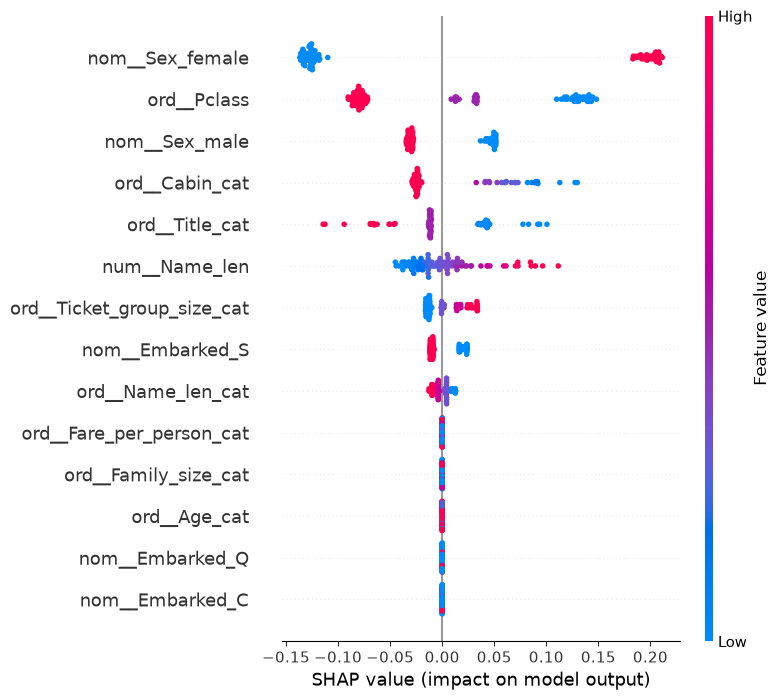

In [17]:
lr_shap_vals = excecute_shap(model_data=lr_b_model, features=f, target=t)

In [18]:
extract_shap_importance(lr_shap_vals)

,feature,mean_abs_shap
0,nom__Sex_female,0.155695
1,ord__Pclass,0.086399
2,nom__Sex_male,0.037590
3,ord__Cabin_cat,0.037174
4,ord__Title_cat,0.031944
5,num__Name_len,0.025336
6,ord__Ticket_group_size_cat,0.015645
7,nom__Embarked_S,0.013439
8,ord__Name_len_cat,0.006874
9,nom__Embarked_C,0.000000


### Semi-conclusion

* **Core Mechanism**: The Linear Boundary
Logistic Regression solves binary classification by constructing a linear hyperplane. The model computes the linear projection of the feature vector onto the weight vector. The hard classification rule is strictly deterministic: a positive projection assigns class 1, and a negative projection assigns class 0. In this geometric sense, it operates identically to a linear perceptron.

* **The Probabilistic Shift**: Sigmoid and Log-Loss
Unlike margin-based classifiers, Logistic Regression does not output a raw geometric distance. Instead, it passes the linear projection through a sigmoid function, mapping the unbounded output into a strict probability between 0 and 1. The model is trained not by maximizing a safety margin, but by minimizing Binary Cross-Entropy (Log-Loss). This objective function optimizes the global probability distribution, heavily penalizing the model for highly confident misclassifications.

* **The Risk of No Margin and Regularization**
Because Logistic Regression lacks a geometric margin, it does not inherently ignore points far from the boundary; every data point influences the hyperplane's position. This makes the standard model highly sensitive to extreme outliers. To mitigate this risk, the algorithm employs L1 or L2 regularization (controlled by the inverse strength parameter $C$). Regularization constrains the magnitude of the weights, preventing any single feature or outlier from exerting disproportionate leverage. This weight constraint acts as a probabilistic substitute for a geometric margin, ensuring a stable and generalizable decision boundary.
---

## Support Vector Classifier (SVC)

### Overview

#### Historical Context

The foundational framework of Statistical Learning Theory was developed by **Vladimir Vapnik** and **Alexey Chervonenkis** in 1963, introducing the concept of the optimal separating hyperplane and the VC-dimension as a measure of model capacity. The modern Support Vector Machine, incorporating the soft margin and the kernel trick for non-linear classification, was formalized by **Corinna Cortes** and **Vapnik** in 1995, building upon the kernel method introduced by **Boser, Guyon, and Vapnik** in 1992.

#### Mathematical Formulation

Support Vector Classification seeks to find the optimal hyperplane that maximizes the geometric margin between distinct classes.

Let $\mathbf{x}_i \in \mathbb{R}^d$ be the feature vector and $y_i \in \{-1, 1\}$ be the corresponding class label. The primal optimization problem for the soft-margin SVM introduces slack variables $\xi_i \geq 0$ to accommodate non-linearly separable data:

$$ \min_{\mathbf{w}, b, \boldsymbol{\xi}} \frac{1}{2} \|\mathbf{w}\|^2 + C \sum_{i=1}^{N} \xi_i $$

subject to the constraints:
$$ y_i(\mathbf{w}^T\mathbf{x}_i + b) \geq 1 - \xi_i, \quad \xi_i \geq 0 \quad \forall i $$

where $C > 0$ is the regularization parameter controlling the trade-off between maximizing the margin and minimizing the classification error.

By applying Lagrangian duality, the problem is transformed into its dual form, which depends exclusively on the dot products of the input vectors $\mathbf{x}_i^T\mathbf{x}_j$. The Kernel Trick substitutes these dot products with a kernel function $K(\mathbf{x}_i, \mathbf{x}_j) = \phi(\mathbf{x}_i)^T\phi(\mathbf{x}_j)$, implicitly mapping the data into a higher-dimensional feature space $\phi(\mathbf{x})$ to achieve non-linear separation without explicit computation of the coordinates.

Equivalently, this can be framed as Empirical Risk Minimization using the Hinge Loss function:
$$ \mathcal{L}(\mathbf{w}, b) = \frac{1}{N} \sum_{i=1}^{N} \max(0, 1 - y_i(\mathbf{w}^T\mathbf{x}_i + b)) + \lambda \|\mathbf{w}\|^2 $$

where $\lambda = \frac{1}{2C}$. The hinge loss penalizes misclassifications and points falling within the margin, enforcing the structural risk minimization principle inherent to the SVM framework.


 ### Feature Engineering & Selection Rationale

#### Algorithm Characteristics

Support Vector Classification relies on distance metrics—specifically Euclidean distance in the RBF kernel space—to construct the optimal separating boundary. This imposes several structural constraints on preprocessing:

- **Distance-based decision boundary:** The kernel function $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2)$ computes similarity strictly through geometric distance. Every feature dimension contributes additively to the norm, making the model exquisitely sensitive to the scale and encoding of inputs.
- **No native categorical support:** SVM requires strictly numerical inputs. Categorical features must be encoded in a way that preserves their discrete, unordered nature without imposing false geometric relationships.
- **Multicollinearity sensitivity:** The dual optimization solves a convex quadratic programming problem. Exact or near-exact multicollinearity can cause numerical instability in the solver and inflate the variance of the decision boundary.
- **Margin maximization via regularization:** The parameter $C$ controls the trade-off between margin width and classification error. Because the regularization term $\|\mathbf{w}\|^2$ treats all coefficients equally, features with larger natural variances dominate the penalty unless standardized.
- **Kernel-induced feature space:** The kernel trick implicitly maps data to a higher-dimensional space. Binning continuous variables destroys intra-bin variance and forces the kernel to operate on piecewise constant manifolds, degrading its capacity to learn smooth, non-linear decision surfaces.

#### Feature Hypotheses

**1. Socio-Economic Status (`Pclass`)**

*Hypothesis:* Passenger class is a strong predictor of survival. First-class passengers had better access to lifeboats and were given priority during evacuation.

*Decision:* Include `Pclass` as a **categorical feature with One-Hot Encoding**. For distance-based algorithms utilizing the RBF kernel, ordinal encoding is mathematically obsolete: mapping $\{1,2,3\}$ to integer coordinates imposes a false linear metric, forcing the model to assume that 3rd class is geometrically "three times farther" from 1st class in a way that may not reflect the true survival gradient. One-Hot Encoding projects categories onto orthogonal vertices of a hypercube, allowing the kernel to measure distance without geometric constraints.

**2. Sex**

*Hypothesis:* Gender is the single strongest predictor of survival. The evacuation order prioritized "women and children first," creating a massive survival disparity.

*Decision:* Include `Sex` as a **categorical feature with One-Hot Encoding**. As a binary nominal variable, One-Hot Encoding creates a single binary indicator, which is mathematically ideal for the RBF kernel.

**3. Age (`Age`)**

*Hypothesis:* Age has a continuous, non-linear relationship with survival. Children were prioritized, while elderly passengers faced mobility challenges. The exact age value carries granular signal about life stage and physical capability.

*Decision:* Include `Age` as a **continuous numeric feature**. Exclude `Age_cat`—binning collapses the continuous distance metric into discrete steps, destroying intra-bin variance and preventing the kernel from recognizing fine-grained similarities (e.g., the difference between age 20 and 29 is meaningful, but binning may place them in the same category with zero distance).

**4. Family Relationships (`Family_size`)**

*Hypothesis:* The total number of family members aboard influences evacuation behavior. Single passengers may have moved independently, while large families faced coordination delays or, conversely, mutual assistance.

*Decision:* Include `Family_size` as a **continuous numeric feature**. Exclude the constituent columns `SibSp` and `Parch`—`Family_size` is an exact linear combination ($X_{family} = X_{sibsp} + X_{parch} + 1$). Including all three gives the concept of "family" triple the geometric weight in the distance calculation and introduces exact multicollinearity that destabilizes the QP solver.

**5. Ticket Group Size (`Ticket_group_size`)**

*Hypothesis:* Passengers traveling on the same ticket traveled together. Larger groups may have faced coordination delays during evacuation or may have been more visible to crew members.

*Decision:* Include `Ticket_group_size` as a **continuous numeric feature**. Exclude `Ticket_group_size_cat`—the kernel can learn its own non-linear decision boundaries from the continuous values; manual binning would arbitrarily flatten the distance metric.

**6. Fare Per Person (`Fare_per_person`)**

*Hypothesis:* Individual fare expenditure reflects socio-economic status more granularly than `Pclass`. Higher per-person fares indicate more affluent passengers with better cabin locations and lifeboat access.

*Decision:* Include `Fare_per_person` as a **continuous numeric feature**. Exclude raw `Fare`—it is not normalized for group size and is mathematically related to `Fare_per_person` through multiplication with `Ticket_group_size`. Using the normalized per-person fare provides a stable, independent proxy for individual status.

**7. Cabin Location (`Cabin_cat`)**

*Hypothesis:* Deck location may correlate with survival due to proximity to lifeboats. The majority of values are missing, but the "unknown" category itself may be informative—passengers without recorded cabins may have been in steerage or had less documentation.

*Decision:* Include `Cabin_cat` (first letter of cabin, `U` for unknown) as a **categorical feature with One-Hot Encoding**. One-Hot Encoding prevents the kernel from assuming a false linear ordering among deck letters (e.g., that deck B is "between" deck A and C in any meaningful survival sense).

**8. Title (`Title_cat`)**

*Hypothesis:* Title extracted from names (Mr., Miss., Mrs., Master.) captures a composite of age, gender, and marital status that may have influenced evacuation priority beyond what `Sex` and `Age` capture alone.

*Decision:* Include `Title_cat` as a **categorical feature with One-Hot Encoding**. While titles have some social hierarchy, the RBF kernel benefits from orthogonal representation. One-Hot Encoding allows the model to assign independent geometric regions to each title without imposing arbitrary distances.

**9. Name Length (`Name_len`)**

*Hypothesis:* Name length may serve as a weak proxy for social standing or cultural background (e.g., aristocratic or certain nationalities may have longer names).

*Decision:* Include `Name_len` as a **continuous numeric feature**. The regularization parameter $C$ will suppress its coefficient if the signal is spurious, and the kernel will ignore it if it does not contribute to margin maximization.

**10. Port of Embarkation (`Embarked`)**

*Hypothesis:* Port of embarkation correlates with passenger demographics and potentially cabin assignment. Cherbourg passengers, for example, had a higher proportion of first-class travelers.

*Decision:* Include `Embarked` as a **categorical feature with One-Hot Encoding**. The three ports have no inherent geometric ordering; One-Hot Encoding ensures the kernel treats each port as an orthogonal dimension.

#### Multicollinearity and Feature Redundancy

The SVM dual optimization requires solving a linear system whose conditioning depends on the feature covariance structure. Exact multicollinearity can render the problem numerically unstable; near multicollinearity inflates the variance of the weight vector and distorts the maximum-margin boundary.

- **`Family_size` vs. `SibSp` + `Parch`:** `Family_size` is an exact linear combination ($X_{family} = X_{sibsp} + X_{parch} + 1$). Including all three guarantees redundant distance contributions and multicollinearity. We retain the derived `Family_size` and drop the constituents.
- **`Fare` vs. `Fare_per_person`:** Raw `Fare` is mathematically related to `Fare_per_person` and introduces redundant scale information. We drop raw `Fare` and retain the normalized `Fare_per_person`.
- **`Age` vs. `Age_cat`:** We retain only the continuous `Age`. The binned version is redundant and actively harmful for a distance-based kernel.
- **`Fare_per_person` vs. `Pclass`:** Retain both. They capture different aspects of socio-economic status (continuous granularity vs. discrete ranking), and their correlation is not exact enough to cause numerical failure in the QP solver.

#### Scaling

**Decision:** We will apply `StandardScaler` to all continuous numeric features after median imputation. This is mathematically critical because:

1. **Distance metric uniformity:** The RBF kernel computes $K(\mathbf{x}_i, \mathbf{x}_j) = \exp(-\gamma \|\mathbf{x}_i - \mathbf{x}_j\|^2)$. If `Fare_per_person` has a scale 100× larger than `Age`, the distance is overwhelmingly dominated by fare differences, and age becomes geometrically invisible.
2. **Regularization uniformity:** The soft-margin penalty $\frac{1}{2}\|\mathbf{w}\|^2$ treats all dimensions equally. Without standardization, the optimizer must compensate for scale disparities, leading to an ill-conditioned problem.
3. **Numerical stability:** Standardization prevents floating-point overflow in the exponent during kernel computation and ensures stable QP solver convergence.

#### Categorical Encoding Strategy

**Decision:** All categorical features—without exception—receive **One-Hot Encoding**.

The RBF kernel computes similarity based on Euclidean distance. If ordinal encoding (e.g., mapping categories to $1, 2, 3$) is applied, the algorithm assumes a strict linear metric between categories. This imposes an artificial geometric constraint, forcing the decision boundary to respect false distances between discrete states (e.g., assuming 'Q' is mathematically between 'S' and 'C' for `Embarked`). One-Hot Encoding maps all categorical variables to orthogonal vertices of a high-dimensional hypercube. This preserves the true categorical nature of the data, ensuring that the distance between any two distinct categories is uniform and that the kernel constructs non-linear margins without geometric bias.

#### Open Questions

We are making several hypotheses that should be validated through experimentation:

- Does the RBF kernel outperform linear or polynomial kernels on this specific feature set, or does the data remain approximately linearly separable in the original space?
- Does the uniform One-Hot treatment of all categorical features—including `Pclass`, which has a clear socio-economic ordering—sacrifice monotonic structure that an ordinal encoding could exploit, despite the geometric risks?
- Is `Family_size` genuinely more stable for the SVC than the decomposed `SibSp` + `Parch` used in linear models, or does the loss of granular family relationship information degrade performance?
- How sensitive is the cross-validated accuracy to the joint choice of $C$ and $\gamma$? Does the optimal boundary require a narrow margin with high $C$, or a wide margin tolerant of misclassification?
- Does the `CalibratedClassifierCV` wrapper meaningfully improve probability calibration for downstream ensemble voting, given that raw SVM outputs are not probabilistic?

#### Final Feature Partition

| Feature Type | Features | Preprocessing |
|--------------|----------|---------------|
| **Numeric Features** | `Age`, `Fare_per_person`, `Family_size`, `Ticket_group_size`, `Name_len` | Median imputation, StandardScaler |
| **Categorical Features** | `Pclass`, `Sex`, `Embarked`, `Title_cat`, `Cabin_cat` | One-Hot Encoding |

### Model

In [37]:
from sklearn.calibration import CalibratedClassifierCV
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC


class SVCModel(BaseModel):
    @property
    def model_name(self) -> str: return "SVC"

    def build_preprocessor(self) -> ColumnTransformer:
        fc = self.feature_config
        transformers = [
            ("num", Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler())]), fc.numeric),
            ("nom", OneHotEncoder(handle_unknown="ignore"), fc.nominal_categorical),
            ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), fc.ordinal_categorical)
        ]
        # Only unpack and include transformers where the column list (t[2]) is not empty
        return ColumnTransformer([t for t in transformers if t[2]], remainder="drop")

    def build_pipeline(self) -> Pipeline:
        # C=1.0, kernel="rbf", and gamma="scale" are omitted as they are SVC defaults
        clf = CalibratedClassifierCV(SVC(random_state=self.random_state), method="sigmoid", cv=5)
        return Pipeline([("preprocessor", self.build_preprocessor()), ("classifier", clf)])

    def define_search_space(self) -> Dict[str, List[Any]]:
        return {
            "classifier__estimator__C": [0.1, 1.0, 10.0, 100.0],
            "classifier__estimator__gamma": ["scale", "auto", 0.01, 0.1, 1.0],
        }

### Workflow

In [34]:
feature_config = FeatureConfig(
    numeric=["Age", "Fare_per_person", "Family_size", "Ticket_group_size", "Name_len"],
    nominal_categorical=["Pclass", "Sex", "Embarked", "Title_cat", "Cabin_cat"],
)

run_workflow(
    model_cls=SVCModel,
    feature_config=feature_config,
    train_df=train_df,
    registry=registry,
    n_splits=5,
)

In [36]:
registry.to_dataframe()

,model_name,variant,timestamp,params,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,Log-Loss
0,SVC,production,2026-07-26 17:48:15,"{'classifier__estimator__C': 10.0, 'classifier...",0.838384,0.820894,0.817308,0.745614,0.779817,0.654297,0.881563,0.414600
1,SVC,tuned,2026-07-26 17:48:15,"{'classifier__estimator__C': 10.0, 'classifier...",0.837254,0.819339,0.817108,0.742498,0.777534,0.652010,0.863145,-0.426905
2,SVC,baseline,2026-07-26 17:48:10,{},0.833890,0.817735,0.805721,0.748380,0.775214,0.645684,0.880707,-0.411390
3,LogisticRegression,production,2026-07-26 17:14:43,"{'classifier__C': 1.0, 'classifier__l1_ratio':...",0.806958,0.789881,0.765625,0.716374,0.740181,0.587701,0.869324,0.427466
4,LogisticRegression,baseline,2026-07-26 17:14:40,{},0.800220,0.782142,0.757483,0.704518,0.729718,0.572856,0.861854,-0.438797
5,LogisticRegression,tuned,2026-07-26 17:14:43,"{'classifier__C': 1.0, 'classifier__l1_ratio':...",0.800220,0.782142,0.757483,0.704518,0.729718,0.572856,0.861854,-0.438797


### Semi-conclusion
* **Core Mechanism**: The Maximum Margin Hyperplane
Unlike models that consider every data point to draw a boundary, the Support Vector Classifier seeks the "widest possible street" that separates the classes. The decision boundary is placed exactly in the center of this street. Crucially, the model's geometry is defined entirely by the data points that lie on the edges of the street—these are the "support vectors." Points located far from the boundary have zero influence on the model, making the algorithm inherently focused only on the most difficult, borderline cases.

* **The Kernel Trick**: Non-Linear Separation
When data cannot be separated by a flat plane in the original feature space, the SVC employs the "Kernel Trick." Instead of explicitly calculating new, complex coordinates, it uses a mathematical function (such as the Radial Basis Function) to measure the similarity between points as if they were projected into a much higher-dimensional space. This allows the algorithm to construct complex, non-linear decision boundaries in the original space without ever performing the computationally expensive coordinate transformations directly.

* **The Soft Margin and Regularization**: The $C$ Parameter
Real-world data is rarely perfectly separable, and outliers are inevitable. The SVC addresses this by introducing a "soft margin," which allows some data points to cross the street boundaries or even the center line. This flexibility is governed by the regularization parameter $C$. A small $C$ creates a wider street, tolerating more misclassifications to achieve a smoother, more generalized boundary. Conversely, a large $C$ creates a narrow, strict street, heavily penalizing any point that falls inside the margin, which risks overfitting to the noise and outliers of the training set.
---

## K-Nearest Neighbors (KNN)

### Overview

#### Historical Context

The K-Nearest Neighbors algorithm was originally introduced by **Evelyn Fix** and **Joseph Hodges** in 1951 as a non-parametric method for discriminant analysis. It was later formalized for statistical pattern recognition and remains one of the foundational algorithms in machine learning due to its intuitive, instance-based learning paradigm.

#### Mathematical Formulation

K-Nearest Neighbors is a lazy, instance-based learning algorithm that classifies a query point based on the majority class of its $k$ closest training examples in the feature space.

Let $\mathbf{x}_q \in \mathbb{R}^d$ be the query feature vector, and $\mathcal{D} = \{(\mathbf{x}_1, y_1), \dots, (\mathbf{x}_N, y_N)\}$ be the training dataset. The algorithm first computes the distance between the query point and all training instances using the Minkowski distance:

$$ D(\mathbf{x}_q, \mathbf{x}_i) = \left( \sum_{j=1}^{d} |x_{q,j} - x_{i,j}|^p \right)^{1/p} $$

where $p=2$ corresponds to the standard Euclidean distance.

The algorithm then identifies the subset $\mathcal{N}_k(\mathbf{x}_q) \subset \mathcal{D}$ containing the $k$ training instances with the smallest distances to $\mathbf{x}_q$.

The predicted class label $\hat{y}_q$ is determined by a majority vote among the labels of these $k$ neighbors:

$$ \hat{y}_q = \arg\max_{c} \sum_{(\mathbf{x}_i, y_i) \in \mathcal{N}_k(\mathbf{x}_q)} \mathbb{I}(y_i = c) $$

where $\mathbb{I}(\cdot)$ is the indicator function, and $c$ represents a possible class label.

Optionally, the voting can be weighted by the inverse of the distance to give closer neighbors more influence:

$$ \hat{y}_q = \arg\max_{c} \sum_{(\mathbf{x}_i, y_i) \in \mathcal{N}_k(\mathbf{x}_q)} w_i \mathbb{I}(y_i = c), \quad \text{where } w_i = \frac{1}{D(\mathbf{x}_q, \mathbf{x}_i)} $$

This formulation highlights that KNN does not learn an explicit global decision boundary during training; instead, it constructs local, non-linear boundaries implicitly at inference time based strictly on the geometric distribution of the training data.

### Feature Engineering & Selection Rationale

#### Algorithm Characteristics

K-Nearest Neighbors is a lazy, instance-based learner that constructs no explicit global model during training. Classification occurs entirely at inference time through geometric proximity in the feature space. This imposes distinct preprocessing constraints:

- **Distance metric as the sole decision mechanism:** The model classifies by computing distances between the query point and stored training instances. Every feature dimension contributes additively to the distance; therefore, the scale, distribution, and encoding of each feature directly determine the geometry of the decision boundary.
- **Feature scaling is mathematically mandatory:** Because distance is computed as a sum of per-dimension differences, a feature with a natural range of 0–1000 will geometrically dominate a feature with a range of 0–1. Without standardization, the nearest-neighbor relationship is determined almost exclusively by large-scale features, rendering small-scale features irrelevant.
- **No native categorical support:** The algorithm requires strictly numerical inputs to compute geometric distances. Categorical features must be encoded such that the resulting numerical values preserve the true relationships between categories—or at least do not introduce spurious geometric relationships.
- **The bias-variance trade-off is controlled by $k$:** A small $k$ produces a highly flexible, jagged decision boundary (high variance); a large $k$ smooths the boundary by averaging over many neighbors (high bias). Feature engineering must ensure the distance metric captures meaningful similarity regardless of $k$.
- **Local, non-linear boundaries:** Unlike global parametric models, KNN constructs implicit decision boundaries that adapt locally to the data density. Preserving fine-grained continuous structure is essential because binning collapses local neighborhoods into discrete equivalence classes.

#### Feature Hypotheses

**1. Socio-Economic Status (`Pclass`)**

*Hypothesis:* Passenger class is a strong predictor of survival. First-class passengers had better access to lifeboats and were given priority during evacuation.

*Decision:* Include `Pclass` as an **ordinal categorical feature**. The socio-economic hierarchy (1st > 2nd > 3rd) maps naturally to a monotonic integer sequence. For KNN, this is mathematically ideal: the Euclidean distance between 1st and 3rd class ($|1-3|=2$) is greater than between 1st and 2nd ($|1-2|=1$), correctly reflecting that 3rd class is "farther" from 1st in terms of survival probability.

**2. Sex**

*Hypothesis:* Gender is the single strongest predictor of survival. The evacuation order prioritized "women and children first," creating a massive survival disparity.

*Decision:* Include `Sex` as a **nominal categorical feature with One-Hot Encoding**. Assigning a single integer to male/female would impose a false geometric distance (e.g., male=0, female=1 implies a distance of 1, but there is no meaningful gradient between genders). One-Hot Encoding creates orthogonal binary dimensions, ensuring the distance between male and female is uniform and does not bias the metric.

**3. Age (`Age`)**

*Hypothesis:* Age has a continuous, non-linear relationship with survival through the distance lens. Children were prioritized, while elderly passengers faced mobility challenges. Two passengers aged 20 and 29 are more similar than two passengers placed in the same coarse bin.

*Decision:* Include `Age` as a **continuous numeric feature**. Exclude `Age_cat`—binning collapses the continuous distance metric into discrete, arbitrary steps. Two passengers aged 20 and 29 would have zero distance if placed in the same bin, destroying the algorithm's ability to recognize fine-grained similarities.

**4. Family Relationships (`SibSp` and `Parch`)**

*Hypothesis:* Family composition affects survival. Having siblings, spouses, parents, or children aboard may influence evacuation behavior, and these relationships may have distinct effects.

*Decision:* Include `SibSp` and `Parch` as **separate continuous numeric features**. Exclude `Family_size`—the exact linear combination ($SibSp + Parch + 1$) creates redundant distance contributions. Including all three gives the concept of "family" triple the geometric weight in the distance calculation compared to a single independent feature, distorting the nearest-neighbor search.

**5. Ticket Group Size (`Ticket_group_size`)**

*Hypothesis:* Passengers traveling on the same ticket may have been traveling together. Larger groups may have faced coordination delays or, conversely, may have been more visible during evacuation.

*Decision:* Include `Ticket_group_size` as a **continuous numeric feature**. Exclude `Ticket_group_size_cat`—the algorithm can learn its own optimal thresholds through distance neighborhoods; manual binning would arbitrarily flatten the distance metric.

**6. Fare Per Person (`Fare_per_person`)**

*Hypothesis:* Fare reflects socio-economic status more granularly than `Pclass`. Higher per-person fares indicate more affluent passengers with better cabin locations and lifeboat access.

*Decision:* Include `Fare_per_person` as a **continuous numeric feature**. Exclude raw `Fare`—it is not normalized for group size and is highly collinear with `Fare_per_person`, which provides a more stable, independent proxy for individual status.

**7. Cabin Location (`Cabin_cat`)**

*Hypothesis:* Deck location may correlate with survival due to proximity to lifeboats. The majority of values are missing, but the "unknown" category itself may be informative.

*Decision:* Include `Cabin_cat` (first letter of cabin, `U` for unknown) as a **nominal categorical feature with One-Hot Encoding**. Deck letters have no meaningful geometric ordering; ordinal encoding would impose false distances (e.g., deck B is not necessarily "between" deck A and deck C in survival probability).

**8. Title (`Title_cat`)**

*Hypothesis:* Title extracted from names (Mr., Miss., Mrs., Master.) captures a composite of age, gender, and marital status that may have influenced evacuation priority beyond what `Sex` and `Age` capture alone.

*Decision:* Include `Title_cat` as a **nominal categorical feature with One-Hot Encoding**. While titles encode social information, they do not form a strict monotonic hierarchy suitable for ordinal distance. One-Hot Encoding allows the distance metric to treat each title as an independent dimension.

**9. Name Length (`Name_len`)**

*Hypothesis:* Name length may serve as a weak proxy for social standing or cultural background (e.g., aristocratic or certain nationalities may have longer names).

*Decision:* Include `Name_len` as a **continuous numeric feature**. Exclude `Name_len_cat`—the distance metric will naturally weight this feature according to its predictive utility; if it is noise, the regularizing effect of choosing an appropriate $k$ will suppress its influence.

**10. Port of Embarkation (`Embarked`)**

*Hypothesis:* Port of embarkation correlates with passenger demographics and potentially cabin assignment. Cherbourg passengers, for example, had a higher proportion of first-class travelers.

*Decision:* Include `Embarked` as a **nominal categorical feature with One-Hot Encoding**. The three ports have no inherent geometric ordering; One-Hot Encoding prevents the algorithm from assuming false linear distances between Southampton, Cherbourg, and Queenstown.

#### Multicollinearity and Feature Redundancy

In distance-based algorithms, every feature dimension contributes additively to the total distance calculation. Including linearly dependent or highly correlated features artificially inflates the "weight" of that underlying concept in the proximity metric.

- **`Family_size` vs. `SibSp` + `Parch`:** `Family_size` is an exact linear combination ($X_{family} = X_{sibsp} + X_{parch} + 1$). Including all three gives the concept of "family" triple the influence on the distance calculation compared to a single independent feature. The derived column is dropped; the constituents are retained to preserve potentially distinct signals.
- **`Fare` vs. `Fare_per_person`:** These are highly correlated. The raw `Fare` is dropped in favor of the normalized `Fare_per_person` to prevent redundant distance contributions and maintain a clean feature space.
- **`Age` vs. `Age_cat`:** We retain only the continuous `Age`. The binned version is redundant and actively harmful for a distance-based model.
- **`Ticket_group_size` vs. `Ticket_group_size_cat`:** Retain only the continuous `Ticket_group_size`.
- **`Name_len` vs. `Name_len_cat`:** Retain only the continuous `Name_len`.
- **`Fare_per_person` vs. `Pclass`:** Retain both. They capture different aspects of socio-economic status (continuous granularity vs. discrete ranking), and their correlation is not exact enough to distort the distance metric severely.

#### Scaling

**Decision:** We will apply `StandardScaler` to all continuous numeric features after median imputation. This is mathematically critical because:

1. **Distance metric uniformity:** The Euclidean distance $D(\mathbf{x}_q, \mathbf{x}_i) = \sqrt{\sum_j (x_{q,j} - x_{i,j})^2}$ treats all dimensions equally. If `Fare_per_person` has a scale 100× larger than `Age`, the distance is overwhelmingly dominated by fare differences, and age becomes geometrically invisible.
2. **Neighbor selection integrity:** Without standardization, the nearest neighbors of a query point are determined primarily by large-scale features, regardless of whether those features are predictive. Standardization ensures each feature contributes proportionally to the similarity judgment.
3. **k-hyperparameter stability:** The optimal value of $k$ depends on the density of the feature space. Standardization creates a more isotropic density landscape, making the choice of $k$ more robust across different feature subsets.

#### Categorical Encoding Strategy

The encoding strategy must align with how KNN processes distances:

- **Ordinal Features (`Pclass`):** Ordinal Encoding maps the inherent hierarchy to a single integer sequence. This is mathematically ideal for KNN because the Euclidean distance correctly reflects that 3rd class is farther from 1st class than 2nd class is. The monotonic relationship is preserved, and only one degree of freedom is consumed.
- **Nominal Features (`Sex`, `Embarked`, `Title_cat`, `Cabin_cat`):** One-Hot Encoding generates orthogonal binary indicators. This is essential because assigning integers to unordered categories would impose false geometric distances (e.g., assuming 'C' is mathematically between 'S' and 'Q' for `Embarked`). One-Hot Encoding ensures that the distance between any two distinct categories is uniform and does not bias the nearest-neighbor search.

#### Open Questions

We are making several hypotheses that should be validated through experimentation:

- Does the ordinal encoding of `Pclass` genuinely improve performance over One-Hot Encoding, or does the imposed linear distance structure harm the model when the true survival gradient is non-linear across classes?
- Is $k=5$ optimal, or does a larger $k$ (e.g., $k=11$ or $k=15$) produce a smoother, more generalizable decision boundary on this dataset?
- Does distance-weighted voting (inverse of distance) outperform uniform majority voting, particularly when class clusters have varying densities?
- Does Manhattan distance ($p=1$) outperform Euclidean distance ($p=2$) given the mixture of continuous and encoded categorical features?
- Does `Name_len` genuinely influence the nearest-neighbor relationship, or does the distance metric naturally suppress it due to its weak signal?

#### Final Feature Partition

| Feature Type | Features | Preprocessing |
|--------------|----------|---------------|
| **Numeric Features** | `Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len` | Median imputation, StandardScaler |
| **Nominal Categorical Features** | `Sex`, `Embarked`, `Title_cat`, `Cabin_cat` | One-Hot Encoding |
| **Ordinal Categorical Features** | `Pclass` | Ordinal Encoding |

### Model

In [41]:
from sklearn.neighbors import KNeighborsClassifier


class KNNModel(BaseModel):
    @property
    def model_name(self) -> str: return "KNN"

    def build_preprocessor(self) -> ColumnTransformer:
        fc = self.feature_config
        transformers = [
            ("num", Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler())]), fc.numeric),
            ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), fc.nominal_categorical),
            ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), fc.ordinal_categorical)
        ]
        return ColumnTransformer([t for t in transformers if t[2]], remainder="drop")

    def build_pipeline(self) -> Pipeline:
        # Defaults (n_neighbors=5, weights="uniform", algorithm="auto", p=2) are omitted
        clf = KNeighborsClassifier(n_jobs=-1)
        return Pipeline([("preprocessor", self.build_preprocessor()), ("classifier", clf)])

    def define_search_space(self) -> Dict[str, List[Any]]:
        return {
            "classifier__n_neighbors": [3, 5, 7, 9, 11, 15, 21],
            "classifier__weights": ["uniform", "distance"],
            "classifier__p": [1, 2],
        }

### Workflow

In [42]:
feature_config = FeatureConfig(
    numeric=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
    nominal_categorical=["Sex", "Embarked", "Title_cat", "Cabin_cat"],
    ordinal_categorical=["Pclass"],
)

run_workflow(
    model_cls=KNNModel,
    feature_config=feature_config,
    train_df=train_df,
    registry=registry,
    n_splits=5,
)

In [43]:
registry.to_dataframe()

,model_name,variant,timestamp,params,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,Log-Loss
0,KNN,production,2026-07-26 18:08:49,"{'classifier__n_neighbors': 11, 'classifier__p...",0.996633,0.995614,1.000000,0.991228,0.995595,0.992895,0.999976,0.004668
1,KNN,tuned,2026-07-26 18:08:49,"{'classifier__n_neighbors': 11, 'classifier__p...",0.840613,0.823810,0.819247,0.751407,0.783485,0.659694,0.869694,-1.087669
2,SVC,production,2026-07-26 17:48:15,"{'classifier__estimator__C': 10.0, 'classifier...",0.838384,0.820894,0.817308,0.745614,0.779817,0.654297,0.881563,0.414600
3,SVC,tuned,2026-07-26 17:48:15,"{'classifier__estimator__C': 10.0, 'classifier...",0.837254,0.819339,0.817108,0.742498,0.777534,0.652010,0.863145,-0.426905
4,SVC,baseline,2026-07-26 17:48:10,{},0.833890,0.817735,0.805721,0.748380,0.775214,0.645684,0.880707,-0.411390
5,KNN,baseline,2026-07-26 18:08:47,{},0.828253,0.810437,0.802238,0.733802,0.766047,0.632832,0.863096,-1.786145
6,LogisticRegression,production,2026-07-26 17:14:43,"{'classifier__C': 1.0, 'classifier__l1_ratio':...",0.806958,0.789881,0.765625,0.716374,0.740181,0.587701,0.869324,0.427466
7,LogisticRegression,baseline,2026-07-26 17:14:40,{},0.800220,0.782142,0.757483,0.704518,0.729718,0.572856,0.861854,-0.438797
8,LogisticRegression,tuned,2026-07-26 17:14:43,"{'classifier__C': 1.0, 'classifier__l1_ratio':...",0.800220,0.782142,0.757483,0.704518,0.729718,0.572856,0.861854,-0.438797


### Semi-conclusion

* **Core Mechanism**: Instance-Based Lazy Learning
Unlike models that construct a global mathematical equation or decision boundary during a dedicated training phase, K-Nearest Neighbors is a lazy learner. It performs no explicit parametric optimization; instead, it memorizes the entire training dataset. The actual computation—measuring distances to stored instances and aggregating their labels—occurs entirely at inference time. This means the model's decision boundary is not a fixed geometric object but an implicit, local, and highly adaptive surface that reshapes itself around the query point based on the density and distribution of its neighbors.

* **The Geometry of Similarity**: Distance Metrics and Scaling
KNN classifies a query point based on its geometric proximity to training examples in the feature space, typically measured using Minkowski or Euclidean distance. Because the algorithm relies on raw geometric distance, it is exquisitely sensitive to the scale of the features. If one feature has a much larger numerical range than another, it will artificially dominate the distance calculation, rendering other features effectively invisible. This makes strict feature scaling mathematically mandatory, not merely a best practice. The choice of distance metric and weighting scheme further defines the geometry of the neighborhood and directly controls which training instances exert influence.

* **The Bias-Variance Trade-off**: The $k$ Parameter
The hyperparameter $k$ dictates the number of neighbors consulted to make a prediction, serving as the sole control over model complexity. A small $k$ creates a highly complex, jagged decision boundary that hugs the training data, capturing local noise and leading to high variance and severe overfitting. Conversely, a large $k$ smooths the decision boundary into a coarse, stable surface that may miss genuine local structure, increasing bias and risking underfitting. Tuning $k$ is therefore a direct exercise in balancing the fundamental bias-variance trade-off: each increment of $k$ trades local sensitivity for global stability.

## Linear Discriminant Analysis (LDA)

### Overview

#### Historical Context

Linear Discriminant Analysis was originally formulated by **Ronald A. Fisher** in 1936 in his seminal paper *The Use of Multiple Measurements in Taxonomic Problems*, as a method for dimensionality reduction and classification. It was later generalized for multi-class problems and formally integrated into the broader framework of statistical pattern recognition and generative probabilistic modeling.

#### Mathematical Formulation

Linear Discriminant Analysis is a generative classification algorithm that models the class-conditional densities to construct linear decision boundaries. It operates under the strict assumption that the features within each class are drawn from a multivariate Gaussian distribution and that all classes share an identical covariance matrix (homoscedasticity).

Let $\mathbf{x} \in \mathbb{R}^d$ be the feature vector and $y \in \{1, \dots, C\}$ be the class label. Assuming $P(\mathbf{x}|y=c) \sim \mathcal{N}(\boldsymbol{\mu}_c, \boldsymbol{\Sigma})$, the discriminant function for class $c$ is derived by taking the logarithm of the posterior probability via Bayes' theorem:

$$ \delta_c(\mathbf{x}) = \mathbf{x}^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_c - \frac{1}{2} \boldsymbol{\mu}_c^T \boldsymbol{\Sigma}^{-1} \boldsymbol{\mu}_c + \log P(y=c) $$

The predicted class is determined by selecting the class with the maximum discriminant score:

$$ \hat{y} = \arg\max_{c} \delta_c(\mathbf{x}) $$

Equivalently, from a geometric perspective, Fisher's Linear Discriminant seeks a projection vector $\mathbf{w}$ that maximizes the separability between classes. This is achieved by maximizing the Rayleigh quotient, which is the ratio of the between-class variance to the within-class variance:

$$ J(\mathbf{w}) = \frac{\mathbf{w}^T \mathbf{S}_B \mathbf{w}}{\mathbf{w}^T \mathbf{S}_W \mathbf{w}} $$

where $\mathbf{S}_B = \sum_{c=1}^{C} N_c (\boldsymbol{\mu}_c - \boldsymbol{\mu})(\boldsymbol{\mu}_c - \boldsymbol{\mu})^T$ is the between-class scatter matrix, and $\mathbf{S}_W = \sum_{c=1}^{C} \sum_{\mathbf{x}_i \in c} (\mathbf{x}_i - \boldsymbol{\mu}_c)(\mathbf{x}_i - \boldsymbol{\mu}_c)^T$ is the within-class scatter matrix.

The optimal projection vector $\mathbf{w}$ is analytically solved as the eigenvector corresponding to the largest eigenvalue of the matrix $\mathbf{S}_W^{-1} \mathbf{S}_B$. This dual formulation highlights that LDA constructs linear boundaries by explicitly modeling the underlying probability distributions, making it highly sensitive to violations of the Gaussian and equal-covariance assumptions.

### Feature Engineering & Selection Rationale

#### Algorithm Characteristics

Linear Discriminant Analysis is a generative classifier that explicitly models class-conditional probability densities. Its mathematical structure imposes strict constraints on feature preparation:

- **Gaussian assumption:** The algorithm assumes features within each class follow a multivariate normal distribution. Binning continuous variables destroys the variance structure and violates this assumption, distorting mean and covariance estimates.
- **Shared covariance requirement:** LDA assumes all classes share an identical covariance matrix $\boldsymbol{\Sigma}$ (homoscedasticity). The decision boundary is derived by inverting the within-class scatter matrix $\mathbf{S}_W$, which estimates this shared covariance. Exact multicollinearity renders $\mathbf{S}_W$ singular; near multicollinearity makes it ill-conditioned, causing numerical instability and exploding variance in discriminant vectors.
- **No native categorical support:** The model requires strictly numerical inputs to compute means, covariances, and Mahalanobis distances. Categorical features must be encoded without introducing false geometric relationships that corrupt the Gaussian density estimates.
- **Affine invariance in theory, numerical sensitivity in practice:** While the final decision boundary is theoretically invariant to scaling, the estimation of $\mathbf{S}_W^{-1}$ is numerically unstable when features have vastly different ranges. Standardization prevents underflow/overflow during matrix inversion and ensures stable covariance estimation.
- **Linear boundary in feature space:** The model cannot learn non-linear decision surfaces. Feature interactions must be captured through the covariance structure or engineered explicitly; the model relies on the linear discriminant function to separate classes.

#### Feature Hypotheses

**1. Socio-Economic Status (`Pclass`)**

*Hypothesis:* Passenger class is a strong predictor of survival. First-class passengers had better access to lifeboats and were given priority during evacuation.

*Decision:* Include `Pclass` as an **ordinal categorical feature**. The socio-economic hierarchy (1st > 2nd > 3rd) maps naturally to a monotonic integer sequence. Ordinal encoding consumes only one degree of freedom, preserving the stability of the scatter matrix inversion while enforcing the natural ordering that the linear discriminant can exploit.

**2. Sex**

*Hypothesis:* Gender is the single strongest predictor of survival. The evacuation order prioritized "women and children first," creating a massive survival disparity.

*Decision:* Include `Sex` as a **nominal categorical feature with One-Hot Encoding**. Binary features technically violate the Gaussian assumption, but One-Hot Encoding is the standard least-damaging workaround. It prevents the model from assuming a false linear distance between male and female, allowing the discriminant function to assign independent weights to each gender.

**3. Age (`Age`)**

*Hypothesis:* Age has a continuous, monotonic relationship with survival. Children were prioritized, while elderly passengers faced mobility challenges. The exact age value carries granular variance required for accurate Gaussian density estimation.

*Decision:* Include `Age` as a **continuous numeric feature**. Exclude `Age_cat`—binning destroys the continuous variance structure and violates the core Gaussian assumption. The linear discriminant can model the continuous gradient directly.

**4. Family Relationships (`SibSp` and `Parch`)**

*Hypothesis:* Family composition affects survival. Having siblings, spouses, parents, or children aboard may influence evacuation behavior, and these relationships may have distinct effects.

*Decision:* Include `SibSp` and `Parch` as **separate continuous numeric features**. Exclude `Family_size`—the exact linear combination ($SibSp + Parch + 1$) creates a singular within-class scatter matrix when included alongside its constituents. The matrix inversion required for the discriminant function would fail or produce numerically unstable results.

**5. Ticket Group Size (`Ticket_group_size`)**

*Hypothesis:* Passengers traveling on the same ticket traveled together. Larger groups may have faced coordination delays or may have been more visible during evacuation.

*Decision:* Include `Ticket_group_size` as a **continuous numeric feature**. The model can estimate its mean and variance within each class and incorporate it into the shared covariance matrix.

**6. Fare Per Person (`Fare_per_person`)**

*Hypothesis:* Individual fare expenditure reflects socio-economic status more granularly than `Pclass`. Higher per-person fares indicate more affluent passengers with better cabin locations and lifeboat access.

*Decision:* Include `Fare_per_person` as a **continuous numeric feature**. Exclude raw `Fare`—it is not normalized for group size and is highly collinear with `Fare_per_person`, which would destabilize the covariance matrix estimation.

**7. Cabin Location (`Cabin_cat`)**

*Hypothesis:* Deck location may correlate with survival due to proximity to lifeboats. The majority of values are missing, but the "unknown" category itself may be informative.

*Decision:* Include `Cabin_cat` (first letter of cabin, `U` for unknown) as an **ordinal categorical feature**. While deck letters have only a weak physical ordering, ordinal encoding is preferred here to conserve degrees of freedom on this small dataset. The high proportion of missing values (`U`) means the category distribution is sparse; One-Hot Encoding would create many near-zero-variance binary features that degrade the conditioning of the scatter matrix.

**8. Title (`Title_cat`)**

*Hypothesis:* Title extracted from names (Mr., Miss., Mrs., Master.) captures a composite of age, gender, and marital status that may have influenced evacuation priority beyond what `Sex` and `Age` capture alone.

*Decision:* Include `Title_cat` as an **ordinal categorical feature**. The grouping (`Mr.`, `Miss.`, `Mrs.`, `Master.`, `else`) provides a compact social proxy. Ordinal encoding preserves matrix conditioning while allowing the linear discriminant to model the social hierarchy as a single dimension.

**9. Name Length (`Name_len`)**

*Hypothesis:* Name length may serve as a weak proxy for social standing or cultural background (e.g., aristocratic or certain nationalities may have longer names).

*Decision:* Include `Name_len` as a **continuous numeric feature**. The Gaussian model will estimate its class-conditional mean and variance; if the signal is spurious, the shared covariance structure will reflect near-zero discriminative power without destabilizing the model.

**10. Port of Embarkation (`Embarked`)**

*Hypothesis:* Port of embarkation correlates with passenger demographics and potentially cabin assignment. Cherbourg passengers, for example, had a higher proportion of first-class travelers.

*Decision:* Include `Embarked` as a **nominal categorical feature with One-Hot Encoding**. The three ports have no inherent ordering; One-Hot Encoding prevents the model from assuming false geometric distances that would corrupt the Gaussian density estimates.

#### Multicollinearity and Feature Redundancy

LDA constructs its decision boundary by computing the inverse of the within-class scatter matrix ($\mathbf{S}_W$). Exact multicollinearity renders $\mathbf{S}_W$ singular (non-invertible), causing the optimization to fail entirely. Near multicollinearity makes the matrix ill-conditioned, leading to extreme numerical instability and inflated variance in the discriminant vectors.

- **`Family_size` vs. `SibSp` + `Parch`:** `Family_size` is an exact linear combination ($X_{family} = X_{sibsp} + X_{parch} + 1$). Including all three guarantees a singular $\mathbf{S}_W$ matrix. The derived column must be dropped; the constituents are retained.
- **`Fare` vs. `Fare_per_person`:** These are highly correlated. To maintain matrix conditioning and numerical stability, the raw `Fare` is dropped in favor of the normalized `Fare_per_person`.
- **`Age` vs. `Age_cat`:** We retain only the continuous `Age`. The binned version destroys the Gaussian variance structure and is redundant for the discriminant function.
- **`Fare_per_person` vs. `Pclass`:** Retain both. They capture different aspects of socio-economic status (continuous granularity vs. discrete ranking), and their correlation is not exact enough to cause singularity.

#### Scaling

**Decision:** We will apply `StandardScaler` to all continuous numeric features after median imputation. While LDA is theoretically affine-invariant (making scaling mathematically optional for the final boundary), scaling is critically important in practice because:

1. **Numerical stability in matrix inversion:** The inversion of $\mathbf{S}_W$ involves dividing by determinants of submatrices. Features with vastly different natural ranges (e.g., `Fare_per_person` vs. `SibSp`) cause the matrix to be ill-conditioned, leading to floating-point underflow/overflow and numerically unstable discriminant vectors.
2. **Stable covariance estimation:** Standardization ensures that covariance off-diagonal terms are computed from comparable scales, preventing any single feature from dominating the variance structure.
3. **Regularization interaction:** If shrinkage is applied (e.g., Ledoit-Wolf), the regularization target assumes comparable feature variances.

#### Categorical Encoding Strategy

- **Nominal Features (`Sex`, `Embarked`):** One-Hot Encoding generates orthogonal binary indicators. While binary features technically violate the Gaussian assumption, One-Hot Encoding is the standard least-damaging workaround. It prevents the model from assuming false geometric distances between unordered categories, which would corrupt the mean vectors and covariance estimates.
- **Ordinal Features (`Pclass`, `Title_cat`, `Cabin_cat`):** Ordinal Encoding maps categories to a single integer sequence. This enforces the monotonic constraint, consumes only one degree of freedom per feature, and preserves the stability of the scatter matrix inversion. For `Pclass`, the ordering is strictly meaningful; for `Title_cat` and `Cabin_cat`, the ordering is approximate but preferable to One-Hot Encoding on this small dataset to prevent matrix ill-conditioning from sparse binary columns.

#### Open Questions

We are making several hypotheses that should be validated through experimentation:

- Does the strict Gaussian assumption hold for the engineered features, or do heavy-tailed distributions (e.g., `Fare_per_person`) violate the normality premise and degrade discriminative power?
- Does the ordinal encoding of `Title_cat` and `Cabin_cat` impose false geometric constraints that degrade performance compared to One-Hot Encoding, despite the matrix conditioning benefits?
- How sensitive is the cross-validated accuracy to violations of the homoscedasticity assumption? Would Quadratic Discriminant Analysis (QDA), which relaxes the shared covariance constraint, achieve better generalization?
- Does shrinkage regularization (e.g., `shrinkage='auto'`) improve numerical stability and generalization on this small dataset?
- Is `Name_len` genuinely predictive, or does the shared covariance structure effectively ignore it?

#### Final Feature Partition

| Feature Type | Features | Preprocessing |
|--------------|----------|---------------|
| **Numeric Features** | `Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len` | Median imputation, StandardScaler |
| **Nominal Categorical Features** | `Sex`, `Embarked` | One-Hot Encoding |
| **Ordinal Categorical Features** | `Pclass`, `Title_cat`, `Cabin_cat` | Ordinal Encoding |

### Model

In [46]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis


class LDAModel(BaseModel):
    @property
    def model_name(self) -> str: return "LDA"

    def build_preprocessor(self) -> ColumnTransformer:
        fc = self.feature_config
        transformers = [
            ("num", Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler())]), fc.numeric),
            ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), fc.nominal_categorical),
            ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), fc.ordinal_categorical)
        ]
        return ColumnTransformer([t for t in transformers if t[2]], remainder="drop")

    def build_pipeline(self) -> Pipeline:
        # solver="svd" is omitted as it is the scikit-learn default
        clf = LinearDiscriminantAnalysis()
        return Pipeline([("preprocessor", self.build_preprocessor()), ("classifier", clf)])

    def define_search_space(self, **overrides) -> List[Dict[str, List[Any]]]:
        return [
            {"classifier__solver": ["svd"]},
            {"classifier__solver": ["lsqr", "eigen"], "classifier__shrinkage": ["auto"]},
        ]

### Workflow

In [47]:
feature_config = FeatureConfig(
    numeric=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
    nominal_categorical=["Sex", "Embarked"],
    ordinal_categorical=["Pclass", "Title_cat", "Cabin_cat"],
)

run_workflow(
    model_cls=LDAModel,
    feature_config=feature_config,
    train_df=train_df,
    registry=registry,
    n_splits=5,
)

In [48]:
registry.to_dataframe()

,model_name,variant,timestamp,params,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,Log-Loss
0,KNN,production,2026-07-26 18:08:49,"{'classifier__n_neighbors': 11, 'classifier__p...",0.996633,0.995614,1.000000,0.991228,0.995595,0.992895,0.999976,0.004668
1,KNN,tuned,2026-07-26 18:08:49,"{'classifier__n_neighbors': 11, 'classifier__p...",0.840613,0.823810,0.819247,0.751407,0.783485,0.659694,0.869694,-1.087669
2,SVC,production,2026-07-26 17:48:15,"{'classifier__estimator__C': 10.0, 'classifier...",0.838384,0.820894,0.817308,0.745614,0.779817,0.654297,0.881563,0.414600
3,SVC,tuned,2026-07-26 17:48:15,"{'classifier__estimator__C': 10.0, 'classifier...",0.837254,0.819339,0.817108,0.742498,0.777534,0.652010,0.863145,-0.426905
4,SVC,baseline,2026-07-26 17:48:10,{},0.833890,0.817735,0.805721,0.748380,0.775214,0.645684,0.880707,-0.411390
5,KNN,baseline,2026-07-26 18:08:47,{},0.828253,0.810437,0.802238,0.733802,0.766047,0.632832,0.863096,-1.786145
6,LogisticRegression,production,2026-07-26 17:14:43,"{'classifier__C': 1.0, 'classifier__l1_ratio':...",0.806958,0.789881,0.765625,0.716374,0.740181,0.587701,0.869324,0.427466
7,LDA,production,2026-07-26 18:33:21,{'classifier__solver': 'svd'},0.801347,0.783122,0.760252,0.704678,0.731411,0.575199,0.867374,0.438035
8,LogisticRegression,baseline,2026-07-26 17:14:40,{},0.800220,0.782142,0.757483,0.704518,0.729718,0.572856,0.861854,-0.438797
9,LogisticRegression,tuned,2026-07-26 17:14:43,"{'classifier__C': 1.0, 'classifier__l1_ratio':...",0.800220,0.782142,0.757483,0.704518,0.729718,0.572856,0.861854,-0.438797


### Semi-conclusion
* **Core Mechanism**: Maximizing Class Separability
Unlike discriminative models that attempt to draw a boundary directly between classes, Linear Discriminant Analysis is a generative approach that seeks to project the data to maximize the distance between class means while minimizing the variance within each individual class. It achieves this by optimizing the Rayleigh quotient—the mathematical ratio of between-class scatter to within-class scatter.

* **The Probabilistic Foundation**: Gaussian Assumptions
LDA mathematically models the distribution of features within each class as a multivariate Gaussian distribution and applies Bayes' theorem to estimate posterior probabilities. This generative nature allows it to handle multi-class problems naturally and provides a probabilistic interpretation, but it strictly relies on the assumption that the data within each class follows a normal distribution.

* **The Linearity Constraint**: Homoscedasticity
The defining characteristic of LDA is its strict assumption that all classes share an identical covariance matrix (homoscedasticity). Because the shared covariance matrices cancel out during the derivation of the decision boundary, the resulting boundary is strictly linear. If this assumption is violated—meaning classes have significantly different variances—the linear boundary will fail to capture the true geometry of the data, necessitating a transition to Quadratic Discriminant Analysis (QDA).
---

## Gaussian Naive Bayes (GNB)

### Overview

#### Historical Context

The algorithm is rooted in **Bayes' Theorem**, formulated by **Thomas Bayes** in 1763 and published posthumously by **Richard Price**. **Pierre-Simon Laplace** later formalized the mathematical framework in 1812, applying it to probability and celestial mechanics. The "naive" conditional independence assumption, which simplifies the joint probability calculation, was introduced to machine learning and document classification by **Marvin Minsky** and colleagues in the 1960s. The Gaussian variant specifically adapts this framework for continuous variables by assuming a normal distribution.

#### Mathematical Formulation

Gaussian Naive Bayes is a generative probabilistic classifier that models the distribution of each feature independently within each class.

The foundation is Bayes' Theorem, which calculates the posterior probability of a class $c$ given a feature vector $\mathbf{x} \in \mathbb{R}^d$:

$$ P(Y=c|\mathbf{x}) = \frac{P(\mathbf{x}|Y=c)P(Y=c)}{P(\mathbf{x})} $$

The "naive" assumption posits that all features are conditionally independent given the class label. This simplifies the joint likelihood $P(\mathbf{x}|Y=c)$ into the product of marginal probabilities:

$$ P(\mathbf{x}|Y=c) = \prod_{i=1}^{d} P(x_i|Y=c) $$

For continuous features, the Gaussian Naive Bayes model assumes that $P(x_i|Y=c)$ follows a normal (Gaussian) distribution parameterized by the class-specific mean $\mu_{c,i}$ and variance $\sigma_{c,i}^2$:

$$ P(x_i|Y=c) = \frac{1}{\sqrt{2\pi\sigma_{c,i}^2}} \exp\left(-\frac{(x_i - \mu_{c,i})^2}{2\sigma_{c,i}^2}\right) $$

The predicted class $\hat{y}$ is determined by selecting the class that maximizes the posterior probability. Since the denominator $P(\mathbf{x})$ is constant for all classes, it is omitted during maximization:

$$ \hat{y} = \arg\max_{c} P(Y=c) \prod_{i=1}^{d} P(x_i|Y=c) $$

To prevent numerical underflow caused by multiplying many small probabilities, the computation is transformed into log-space. The classification rule becomes:

$$ \hat{y} = \arg\max_{c} \left[ \log P(Y=c) - \frac{1}{2} \sum_{i=1}^{d} \left( \log(2\pi\sigma_{c,i}^2) + \frac{(x_i - \mu_{c,i})^2}{\sigma_{c,i}^2} \right) \right] $$

This formulation highlights that GNB estimates the parameters ($\mu$ and $\sigma^2$) directly from the training data via Maximum Likelihood Estimation, requiring no iterative optimization or gradient descent, making it exceptionally fast and highly scalable.

### Feature Engineering & Selection Rationale

#### Algorithm Characteristics

Gaussian Naive Bayes is a generative probabilistic classifier with structural assumptions that dictate preprocessing strategy:

- **Explicit Gaussian density estimation:** The algorithm calculates the mean $\mu$ and variance $\sigma^2$ for each feature within each class under a continuous Normal distribution. Binning continuous variables forces the model to estimate parameters on discrete, arbitrary intervals, severely distorting likelihood calculations.
- **The naive independence assumption:** The model assumes all features are conditionally independent given the class label. When features are highly correlated, the model "double-counts" the same underlying evidence, inflating posterior probabilities and producing overconfident, unstable predictions.
- **No native categorical support:** GNB is designed for continuous variables. Categorical features must be encoded numerically without introducing false mathematical relationships that corrupt the Gaussian likelihoods.
- **Log-space computation for numerical stability:** The classification rule operates in log-space to prevent underflow. Extreme feature scales can cause the exponent $(x_i - \mu_{c,i})^2 / \sigma_{c,i}^2$ to overflow or underflow during evaluation.
- **Maximum Likelihood Estimation:** Parameters are estimated directly from training data via closed-form solutions. There is no iterative optimization, so the model cannot learn to ignore redundant features or adapt to multicollinearity.

#### Feature Hypotheses

**1. Socio-Economic Status (`Pclass`)**

*Hypothesis:* Passenger class is a strong predictor of survival. First-class passengers had better access to lifeboats and were given priority during evacuation.

*Decision:* Include `Pclass` as an **ordinal categorical feature**. Mapping the hierarchy to integers allows GNB to treat it as a continuous gradient. While not perfectly Gaussian, this is the most mathematically sound approach for ordered categories on a small dataset, consuming only one degree of freedom.

**2. Sex**

*Hypothesis:* Gender is the single strongest predictor of survival. The evacuation order prioritized "women and children first," creating a massive survival disparity.

*Decision:* Include `Sex` as a **nominal categorical feature with One-Hot Encoding**. Assigning a single integer would impose a false continuous distance (e.g., male=0, female=1 implies a distance of 1 with an ordering that does not exist). One-Hot Encoding creates orthogonal binary indicators, allowing the model to evaluate each gender independently without false geometric assumptions.

**3. Age (`Age`)**

*Hypothesis:* Age has a continuous relationship with survival. Children were prioritized, while elderly passengers faced mobility challenges. The exact age value is required for accurate Gaussian probability density estimation.

*Decision:* Include `Age` as a **continuous numeric feature**. Exclude `Age_cat`—binning destroys the continuous variance structure and forces the algorithm to calculate means and variances on discrete, arbitrary bins, violating the core Gaussian assumption.

**4. Family Relationships (`SibSp` and `Parch`)**

*Hypothesis:* Family composition affects survival. Having siblings, spouses, parents, or children aboard may influence evacuation behavior, and these relationships may have distinct effects.

*Decision:* Include `SibSp` and `Parch` as **separate continuous numeric features**. Exclude `Family_size`—the exact linear combination ($SibSp + Parch + 1$) guarantees that the "family" evidence is counted twice under the independence assumption, artificially inflating the posterior probability for family-related predictions.

**5. Ticket Group Size (`Ticket_group_size`)**

*Hypothesis:* Passengers traveling on the same ticket traveled together. Larger groups may have faced coordination delays or may have been more visible during evacuation.

*Decision:* Include `Ticket_group_size` as a **continuous numeric feature**. The model will estimate class-conditional means and variances for this feature directly.

**6. Fare Per Person (`Fare_per_person`)**

*Hypothesis:* Individual fare expenditure reflects socio-economic status more granularly than `Pclass`. Higher per-person fares indicate more affluent passengers with better cabin locations and lifeboat access.

*Decision:* Include `Fare_per_person` as a **continuous numeric feature**. Exclude raw `Fare`—it is not normalized for group size and is highly correlated with `Fare_per_person`. Including both would violate the independence assumption and cause the model to double-count socio-economic evidence.

**7. Cabin Location (`Cabin_cat`)**

*Hypothesis:* Deck location may correlate with survival due to proximity to lifeboats. The majority of values are missing, but the "unknown" category itself may be informative.

*Decision:* Include `Cabin_cat` (first letter of cabin, `U` for unknown) as an **ordinal categorical feature**. While deck letters have only a weak physical ordering, ordinal encoding is preferred here to conserve degrees of freedom on this small dataset and prevent the sparse binary columns of One-Hot Encoding from destabilizing the variance estimates.

**8. Title (`Title_cat`)**

*Hypothesis:* Title extracted from names (Mr., Miss., Mrs., Master.) captures a composite of age, gender, and marital status that may have influenced evacuation priority beyond what `Sex` and `Age` capture alone.

*Decision:* Include `Title_cat` as an **ordinal categorical feature**. The grouping (`Mr.`, `Miss.`, `Mrs.`, `Master.`, `else`) provides a compact social proxy. Ordinal encoding maps this to a single integer sequence, minimizing parameter count while preserving approximate social hierarchy.

**9. Name Length (`Name_len`)**

*Hypothesis:* Name length may serve as a weak proxy for social standing or cultural background (e.g., aristocratic or certain nationalities may have longer names).

*Decision:* Include `Name_len` as a **continuous numeric feature**. The Gaussian model will estimate its class-conditional mean and variance; if the signal is spurious, the likelihood ratios will be near unity and the feature will have minimal impact on the posterior.

**10. Port of Embarkation (`Embarked`)**

*Hypothesis:* Port of embarkation correlates with passenger demographics and potentially cabin assignment. Cherbourg passengers, for example, had a higher proportion of first-class travelers.

*Decision:* Include `Embarked` as a **nominal categorical feature with One-Hot Encoding**. The three ports have no inherent ordering; One-Hot Encoding prevents the model from assuming false geometric distances that would corrupt the Gaussian likelihoods.

#### Multicollinearity and Feature Redundancy

The foundational mathematical assumption of GNB is that all features are conditionally independent given the class label. When features are highly correlated, this assumption is severely violated. The model will effectively "double-count" the same underlying evidence, artificially inflating the posterior probabilities and leading to overconfident, unstable predictions.

- **`Family_size` vs. `SibSp` + `Parch`:** `Family_size` is an exact linear combination ($X_{family} = X_{sibsp} + X_{parch} + 1$). Including it guarantees that the "family" evidence is counted twice. The derived column must be dropped.
- **`Fare` vs. `Fare_per_person`:** These are highly correlated. To prevent redundant evidence inflation, the raw `Fare` is dropped in favor of the normalized `Fare_per_person`.
- **`Age` vs. `Age_cat`:** We retain only the continuous `Age`. The binned version destroys the Gaussian variance structure and is redundant.
- **`Fare_per_person` vs. `Pclass`:** Retain both. They capture different aspects of socio-economic status (continuous granularity vs. discrete ranking), and their correlation is not exact enough to cause catastrophic independence violation.

#### Scaling

**Decision:** We will apply `StandardScaler` to all continuous numeric features after median imputation. While GNB is theoretically invariant to monotonic transformations (the Gaussian PDF is shape-preserving under linear scaling), scaling is practically critical to prevent numerical underflow or overflow when computing the exponent in the Gaussian probability density function. Features with large natural variances (e.g., `Fare_per_person`) can produce squared deviations that overflow floating-point representations, while features with very small variances can underflow to zero.

#### Categorical Encoding Strategy

- **Nominal Features (`Sex`, `Embarked`):** One-Hot Encoding generates orthogonal binary indicators. This is essential because assigning integers to unordered categories would impose a false continuous distance (e.g., assuming 'C' is mathematically between 'S' and 'Q'). The binary representation allows the model to evaluate each category independently without corrupting the Gaussian likelihoods.
- **Ordinal Features (`Pclass`, `Title_cat`, `Cabin_cat`):** Ordinal Encoding maps categories to a single integer sequence. For `Pclass`, the ordering is strictly meaningful (1st > 2nd > 3rd). For `Title_cat` and `Cabin_cat`, the ordering is approximate but preferable to One-Hot Encoding on this small dataset to prevent sparse binary columns from destabilizing the variance estimates and consuming degrees of freedom.

#### Open Questions

We are making several hypotheses that should be validated through experimentation:

- Does the Gaussian assumption hold for skewed features like `Fare_per_person`, or does the heavy tail violate the normality premise and degrade discriminative power?
- Does the ordinal encoding of `Cabin_cat` and `Title_cat` introduce false geometric constraints that degrade performance compared to One-Hot Encoding, despite the independence benefits?
- How severely does the correlation between `Fare_per_person` and `Pclass` violate the naive independence assumption, and does it cause overconfident probability estimates?
- Does `var_smoothing` regularization improve generalization by preventing zero-variance features from dominating the likelihood calculation?
- Is `Name_len` genuinely predictive, or does the model assign it near-uniform likelihoods across classes?

#### Final Feature Partition

| Feature Type | Features | Preprocessing |
|--------------|----------|---------------|
| **Numeric Features** | `Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len` | Median imputation, StandardScaler |
| **Nominal Categorical Features** | `Sex`, `Embarked` | One-Hot Encoding |
| **Ordinal Categorical Features** | `Pclass`, `Title_cat`, `Cabin_cat` | Ordinal Encoding |

### Model

In [49]:
from sklearn.naive_bayes import GaussianNB


class GNBModel(BaseModel):
    @property
    def model_name(self) -> str: return "GNB"

    def build_preprocessor(self) -> ColumnTransformer:
        fc = self.feature_config
        transformers = [
            ("num", Pipeline([("i", SimpleImputer(strategy="median")), ("s", StandardScaler())]), fc.numeric),
            ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), fc.nominal_categorical),
            ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), fc.ordinal_categorical)
        ]
        return ColumnTransformer([t for t in transformers if t[2]], remainder="drop")

    def build_pipeline(self) -> Pipeline:
        return Pipeline([("preprocessor", self.build_preprocessor()), ("classifier", GaussianNB())])

    def define_search_space(self, **overrides) -> Dict[str, List[Any]]:
        return {"classifier__var_smoothing": [1e-9, 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3]}

### Workflow

In [50]:
feature_config = FeatureConfig(
    numeric=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
    nominal_categorical=["Sex", "Embarked"],
    ordinal_categorical=["Pclass", "Title_cat", "Cabin_cat"],
)

run_workflow(
    model_cls=GNBModel,
    feature_config=feature_config,
    train_df=train_df,
    registry=registry,
    n_splits=5,
)

In [51]:
registry.to_dataframe()

,model_name,variant,timestamp,params,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,Log-Loss
0,KNN,production,2026-07-26 18:08:49,"{'classifier__n_neighbors': 11, 'classifier__p...",0.996633,0.995614,1.000000,0.991228,0.995595,0.992895,0.999976,0.004668
1,KNN,tuned,2026-07-26 18:08:49,"{'classifier__n_neighbors': 11, 'classifier__p...",0.840613,0.823810,0.819247,0.751407,0.783485,0.659694,0.869694,-1.087669
2,SVC,production,2026-07-26 17:48:15,"{'classifier__estimator__C': 10.0, 'classifier...",0.838384,0.820894,0.817308,0.745614,0.779817,0.654297,0.881563,0.414600
3,SVC,tuned,2026-07-26 17:48:15,"{'classifier__estimator__C': 10.0, 'classifier...",0.837254,0.819339,0.817108,0.742498,0.777534,0.652010,0.863145,-0.426905
4,SVC,baseline,2026-07-26 17:48:10,{},0.833890,0.817735,0.805721,0.748380,0.775214,0.645684,0.880707,-0.411390
5,KNN,baseline,2026-07-26 18:08:47,{},0.828253,0.810437,0.802238,0.733802,0.766047,0.632832,0.863096,-1.786145
6,LogisticRegression,production,2026-07-26 17:14:43,"{'classifier__C': 1.0, 'classifier__l1_ratio':...",0.806958,0.789881,0.765625,0.716374,0.740181,0.587701,0.869324,0.427466
7,LDA,production,2026-07-26 18:33:21,{'classifier__solver': 'svd'},0.801347,0.783122,0.760252,0.704678,0.731411,0.575199,0.867374,0.438035
8,LogisticRegression,baseline,2026-07-26 17:14:40,{},0.800220,0.782142,0.757483,0.704518,0.729718,0.572856,0.861854,-0.438797
9,LogisticRegression,tuned,2026-07-26 17:14:43,"{'classifier__C': 1.0, 'classifier__l1_ratio':...",0.800220,0.782142,0.757483,0.704518,0.729718,0.572856,0.861854,-0.438797


### Semi-conclusion

* **Core Mechanism**: The "Naive" Independence Assumption
Gaussian Naive Bayes classifies data by calculating the probability of each class and multiplying the individual probabilities of each feature. The "naive" assumption is that every feature contributes independently to the outcome, completely ignoring any complex interactions or correlations between features. It evaluates each variable in strict isolation, making the posterior computation tractable through simple multiplication of marginal likelihoods.

* **The Probabilistic Foundation**: The Gaussian Bell Curve
To handle continuous variables like Age or Fare, the algorithm assumes the data for each class follows a normal (Gaussian) distribution. It simply calculates the mean and variance for each feature within each class, effectively fitting a bell curve to the training data. A new data point is classified based on which class's bell curves it aligns with most naturally, as measured by the probability density at that point.

* **The Trade-off**: Speed and Simplicity vs. Reality
In the real world, features are rarely completely independent, which means the model's probability estimates can become artificially overconfident when correlated features reinforce the same evidence. However, this "naive" simplification is also its greatest strength: because it does not attempt to learn complex feature interactions or perform iterative optimization, it is exceptionally fast, highly scalable, and remarkably resistant to overfitting, even when trained on very small datasets.

# Single Base models: Tree-Based Ensembles

## Decision Tree

### Overview

#### Historical Context

The foundational algorithms for decision trees were developed in the 1960s by **Hunt, Landis, and Moore** (Concept Learning Systems). The modern framework was formalized in the 1980s through two parallel paradigms: **J. Ross Quinlan's** ID3 (1986) and C4.5 algorithms, which utilized Information Gain (Entropy) for feature selection, and **Leo Breiman et al.'s** CART (1984) algorithm, which introduced the Gini Impurity metric and the recursive binary partitioning methodology standard in modern implementations.

#### Mathematical Formulation

A decision tree constructs a predictive model by recursively partitioning the feature space $\mathcal{X} \subset \mathbb{R}^d$ into $M$ disjoint, non-overlapping regions $R_1, R_2, \dots, R_M$. Each region is defined by a sequence of binary split rules of the form $X_j \leq t$, where $X_j$ is a specific feature and $t$ is a threshold.

For a given region $R_m$, let $p_{mk}$ represent the proportion of training samples belonging to class $k \in \{1, \dots, K\}$. The tree selects the optimal feature $j$ and threshold $t$ at each node by maximizing the reduction in node impurity $\Phi$. The two standard impurity measures are Gini Impurity and Entropy:

$$ \text{Gini}(R_m) = 1 - \sum_{k=1}^{K} p_{mk}^2 $$

$$ \text{Entropy}(R_m) = -\sum_{k=1}^{K} p_{mk} \log_2(p_{mk}) $$

The algorithm greedily searches for the split that minimizes the weighted sum of the impurities of the resulting child nodes ($R_{left}$ and $R_{right}$):

$$ \arg\min_{j, t} \left( \frac{N_{left}}{N_{parent}} \Phi(R_{left}) + \frac{N_{right}}{N_{parent}} \Phi(R_{right}) \right) $$

where $N$ denotes the number of samples in the respective nodes.

Once the tree is fully grown, the prediction $\hat{y}$ for a query point $\mathbf{x}$ falling into region $R_m$ is determined by the majority class (mode) of the training samples within that region:

$$ \hat{y}(\mathbf{x}) = \arg\max_{k} p_{mk} \quad \text{for } \mathbf{x} \in R_m $$

Because an unconstrained decision tree will recursively partition the space until every leaf node is perfectly pure, it is highly susceptible to overfitting (high variance). Therefore, structural constraints—such as maximum depth, minimum samples per split, and minimum samples per leaf—are mathematically critical to act as pre-pruning mechanisms, controlling the model's complexity and ensuring generalization.

### Feature Engineering & Selection Rationale

#### Algorithm Characteristics

Decision trees construct predictive models through recursive binary partitioning. Their mathematical structure imposes distinct preprocessing constraints compared to parametric models:

- **Invariant to monotonic transformations:** Tree splits depend solely on rank order, not absolute scale. StandardScaler provides no mathematical benefit and is computationally wasteful.
- **No matrix singularity:** Unlike linear models, trees do not invert covariance matrices. Exact linear combinations do not cause numerical failure.
- **Feature importance dilution:** When highly correlated features are present, the algorithm randomly selects one to split on at each node. The predictive power of the underlying concept is fractured across variables, artificially suppressing individual importance scores in post-hoc analysis.
- **Greedy impurity minimization:** At each node, the algorithm exhaustively searches for the single feature and threshold that maximally reduces Gini or Entropy impurity. Both continuous and properly encoded categorical features are viable candidates.
- **Native threshold search on continuous features:** Trees can find optimal split points on continuous variables automatically. However, explicit binning injects domain knowledge that may guide the tree toward structurally meaningful boundaries rather than noise-driven thresholds.
- **No native categorical support in scikit-learn:** The implementation requires numerical inputs. Categorical features must be encoded to enable split evaluation.

#### Feature Hypotheses

**1. Socio-Economic Status (`Pclass`)**

*Hypothesis:* Passenger class is a strong predictor of survival. First-class passengers had better access to lifeboats and were given priority during evacuation.

*Decision:* Include `Pclass` as an **ordinal categorical feature**. Mapping the hierarchy to integers allows the tree to capture the relationship with a single, clean threshold split (e.g., `Pclass <= 2` to separate first and second class from third).

**2. Sex**

*Hypothesis:* Gender is the single strongest predictor of survival. The evacuation order prioritized "women and children first," creating a massive survival disparity.

*Decision:* Include `Sex` as a **nominal categorical feature with One-Hot Encoding**. A single binary indicator allows the tree to achieve a near-perfect split with one threshold.

**3. Age (`Age`) and Age Category (`Age_cat`)**

*Hypothesis:* Age has a non-linear relationship with survival. Children were prioritized, while elderly passengers faced mobility challenges. The raw continuous value carries granular signal, but human-interpretable life-stage boundaries may provide stronger inductive bias.

*Decision:* Include **both** `Age` as a continuous numeric feature and `Age_cat` as an ordinal categorical feature. The tree will evaluate both representations at each node and select the one that yields the highest information gain. The binned version encodes domain knowledge about life stages; the continuous version allows data-driven threshold discovery.

**4. Family Relationships (`SibSp`, `Parch`, and `Family_size_cat`)**

*Hypothesis:* Family composition affects survival. Single passengers may have moved independently, while large families faced coordination delays or mutual assistance.

*Decision:* Include `SibSp` and `Parch` as **separate continuous numeric features**. Exclude the derived continuous `Family_size`—it is an exact linear combination ($SibSp + Parch + 1$) that would fracture the family signal across correlated variables, diluting measured importance. Retain `Family_size_cat` as an **ordinal categorical feature**; the binned version is not an exact linear combination and provides a compact, interpretable grouping that the tree can exploit with a single threshold.

**5. Ticket Group Size (`Ticket_group_size`) and Ticket Group Size Category (`Ticket_group_size_cat`)**

*Hypothesis:* Passengers traveling on the same ticket traveled together. Larger groups may have faced coordination delays or may have been more visible during evacuation.

*Decision:* Include **both** `Ticket_group_size` as a continuous numeric feature and `Ticket_group_size_cat` as an ordinal categorical feature. The tree will select the representation that maximizes impurity reduction at each split.

**6. Fare Per Person (`Fare_per_person`) and Fare Per Person Category (`Fare_per_person_cat`)**

*Hypothesis:* Individual fare expenditure reflects socio-economic status more granularly than `Pclass`. Higher per-person fares indicate more affluent passengers with better cabin locations and lifeboat access.

*Decision:* Include **both** `Fare_per_person` as a continuous numeric feature and `Fare_per_person_cat` as an ordinal categorical feature. Exclude raw `Fare`—it is not normalized for group size and is highly correlated with `Fare_per_person`, which would dilute importance across redundant variables.

**7. Cabin Location (`Cabin_cat`)**

*Hypothesis:* Deck location may correlate with survival due to proximity to lifeboats. The majority of values are missing, but the "unknown" category itself may be informative.

*Decision:* Include `Cabin_cat` (first letter of cabin, `U` for unknown) as an **ordinal categorical feature**. While deck letters have a weak physical ordering, ordinal encoding enables efficient single-threshold splits and conserves degrees of freedom on this small dataset.

**8. Title (`Title_cat`)**

*Hypothesis:* Title extracted from names (Mr., Miss., Mrs., Master.) captures a composite of age, gender, and marital status that may have influenced evacuation priority beyond what `Sex` and `Age` capture alone.

*Decision:* Include `Title_cat` as an **ordinal categorical feature**. The grouping allows the tree to isolate social demographics with single-threshold splits (e.g., `Title_cat <= 2` to separate children and women from adult men).

**9. Name Length (`Name_len`) and Name Length Category (`Name_len_cat`)**

*Hypothesis:* Name length may serve as a weak proxy for social standing or cultural background.

*Decision:* Include **both** `Name_len` as a continuous numeric feature and `Name_len_cat` as an ordinal categorical feature. The tree will evaluate both; if the signal is spurious, neither will be selected for splitting.

**10. Port of Embarkation (`Embarked`)**

*Hypothesis:* Port of embarkation correlates with passenger demographics and potentially cabin assignment. Cherbourg passengers, for example, had a higher proportion of first-class travelers.

*Decision:* Include `Embarked` as a **nominal categorical feature with One-Hot Encoding**. This allows the tree to evaluate each port independently without assuming false geometric distances.

#### Multicollinearity and Feature Redundancy

Tree-based models do not suffer from matrix singularity, but they suffer from *feature importance dilution*. When highly correlated features are present, the algorithm randomly selects one to split on at a given node. The predictive power of the underlying concept is fractured across correlated variables, artificially suppressing their individual importance scores in post-hoc analysis.

- **`Family_size` vs. `SibSp` + `Parch`:** `Family_size` is an exact linear combination ($X_{family} = X_{sibsp} + X_{parch} + 1$). Including it guarantees that the "family" signal is split, diluting its measured importance. The derived continuous column is dropped; its binned version `Family_size_cat` is retained.
- **`Fare` vs. `Fare_per_person`:** The raw `Fare` is dropped in favor of the normalized `Fare_per_person` and its binned counterpart `Fare_per_person_cat` to maintain a clean, undiluted feature space.
- **`Age` vs. `Age_cat`:** Both are retained. The tree will naturally evaluate and select the representation that yields the highest information gain at each node.
- **`Ticket_group_size` vs. `Ticket_group_size_cat`:** Both are retained for the same reason.
- **`Name_len` vs. `Name_len_cat`:** Both are retained for the same reason.

#### Scaling

**Decision:** We will **not** apply StandardScaler or any other scaling. Decision tree splits are strictly invariant to monotonic transformations; scaling does not alter the order of the data or the resulting split thresholds. Applying StandardScaler would add computational overhead with no mathematical benefit.

#### Categorical Encoding Strategy

- **Ordinal Features (`Pclass`, `Title_cat`, `Cabin_cat`, `Age_cat`, `Family_size_cat`, `Ticket_group_size_cat`, `Fare_per_person_cat`, `Name_len_cat`):** Ordinal Encoding maps categories to a single integer sequence. This allows the tree to capture relationships with a single, clean threshold split (e.g., `Age_cat <= 1` to isolate the "child" group). It is computationally efficient and consumes minimal degrees of freedom.
- **Nominal Features (`Sex`, `Embarked`):** One-Hot Encoding generates orthogonal binary indicators. This is essential because assigning integers to unordered categories would force the tree to create multiple, inefficient, and disjoint splits to capture the true relationship.

#### Open Questions

We are making several hypotheses that should be validated through experimentation:

- Does the inclusion of both raw and binned versions of the same feature (e.g., `Age` and `Age_cat`) actually improve performance, or does it create redundancy that confuses the greedy split selection?
- Does the ordinal encoding of `Cabin_cat` and `Title_cat` impose false geometric constraints that degrade performance compared to One-Hot Encoding?
- Is `Family_size_cat` genuinely informative beyond what `SibSp` and `Parch` capture separately?
- How sensitive is the cross-validated accuracy to the choice of `criterion` (Gini vs. Entropy)?
- Does pre-pruning via `max_depth`, `min_samples_split`, or `min_samples_leaf` prevent the expected overfitting on this small dataset?

#### Final Feature Partition

| Feature Type | Features | Preprocessing |
|--------------|----------|---------------|
| **Numeric Features** | `Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len` | Passthrough (no scaling) |
| **Nominal Categorical Features** | `Sex`, `Embarked` | One-Hot Encoding |
| **Ordinal Categorical Features** | `Pclass`, `Title_cat`, `Cabin_cat`, `Age_cat`, `Family_size_cat`, `Ticket_group_size_cat`, `Fare_per_person_cat`, `Name_len_cat` | Ordinal Encoding |

### Model

In [54]:
from sklearn.tree import DecisionTreeClassifier


class DecisionTreeModel(BaseModel):
    @property
    def model_name(self) -> str: return "DecisionTree"

    def build_preprocessor(self) -> ColumnTransformer:
        fc = self.feature_config
        transformers = [
            ("num", "passthrough", fc.numeric),
            ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), fc.nominal_categorical),
            ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), fc.ordinal_categorical)
        ]
        return ColumnTransformer([t for t in transformers if t[2]], remainder="drop")

    def build_pipeline(self) -> Pipeline:
        # criterion="gini" is omitted as it is the scikit-learn default
        clf = DecisionTreeClassifier(random_state=self.random_state)
        return Pipeline([("preprocessor", self.build_preprocessor()), ("classifier", clf)])

    def define_search_space(self, **overrides) -> Dict[str, List[Any]]:
        return {
            "classifier__criterion": ["gini", "entropy"],
            "classifier__max_depth": [None, 5, 10, 15, 20],
            "classifier__min_samples_split": [2, 5, 10],
            "classifier__min_samples_leaf": [1, 2, 4],
        }

### Workflow

In [55]:
feature_config = FeatureConfig(
    numeric=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
    nominal_categorical=["Sex", "Embarked"],
    ordinal_categorical=["Pclass", "Title_cat", "Cabin_cat", "Age_cat", "Family_size_cat", "Ticket_group_size_cat", "Fare_per_person_cat", "Name_len_cat"],
)

run_workflow(
    model_cls=DecisionTreeModel,
    feature_config=feature_config,
    train_df=train_df,
    registry=registry,
    n_splits=5,
)

In [56]:
registry.to_dataframe()

,model_name,variant,timestamp,params,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,Log-Loss
0,KNN,production,2026-07-26 18:08:49,"{'classifier__n_neighbors': 11, 'classifier__p...",0.996633,0.995614,1.000000,0.991228,0.995595,0.992895,0.999976,0.004668
1,DecisionTree,production,2026-07-26 18:49:34,"{'classifier__criterion': 'entropy', 'classifi...",0.861953,0.852699,0.824926,0.812865,0.818851,0.707397,0.909303,0.330317
2,KNN,tuned,2026-07-26 18:08:49,"{'classifier__n_neighbors': 11, 'classifier__p...",0.840613,0.823810,0.819247,0.751407,0.783485,0.659694,0.869694,-1.087669
3,SVC,production,2026-07-26 17:48:15,"{'classifier__estimator__C': 10.0, 'classifier...",0.838384,0.820894,0.817308,0.745614,0.779817,0.654297,0.881563,0.414600
4,SVC,tuned,2026-07-26 17:48:15,"{'classifier__estimator__C': 10.0, 'classifier...",0.837254,0.819339,0.817108,0.742498,0.777534,0.652010,0.863145,-0.426905
5,SVC,baseline,2026-07-26 17:48:10,{},0.833890,0.817735,0.805721,0.748380,0.775214,0.645684,0.880707,-0.411390
6,DecisionTree,tuned,2026-07-26 18:49:34,"{'classifier__criterion': 'entropy', 'classifi...",0.832741,0.813976,0.812598,0.733589,0.769968,0.642284,0.856064,-1.192429
7,KNN,baseline,2026-07-26 18:08:47,{},0.828253,0.810437,0.802238,0.733802,0.766047,0.632832,0.863096,-1.786145
8,LogisticRegression,production,2026-07-26 17:14:43,"{'classifier__C': 1.0, 'classifier__l1_ratio':...",0.806958,0.789881,0.765625,0.716374,0.740181,0.587701,0.869324,0.427466
9,LDA,production,2026-07-26 18:33:21,{'classifier__solver': 'svd'},0.801347,0.783122,0.760252,0.704678,0.731411,0.575199,0.867374,0.438035


### Semi-conclusion
* **Core Mechanism**: Recursive Binary Partitioning
The Decision Tree constructs a predictive model by recursively dividing the feature space into disjoint, rectangular regions. At each node, the algorithm evaluates features and thresholds to find the single best binary split that most effectively separates the classes. In practice, the model operates as a transparent, interpretable cascade of if-then logical rules, routing each data point down a specific path to a final leaf node.

* **The Structural Shift**: Greedy Impurity Optimization
Unlike models that optimize a global mathematical function via gradient descent or geometric margins, the tree builds its structure greedily, one node at a time. It relies on impurity metrics—such as Gini Impurity or Information Entropy—to quantify class mixing. The algorithm strictly seeks the split that yields the maximum immediate reduction in impurity, making locally optimal decisions at each step without calculating the global optimality of the entire tree structure.

* **The Risk**: Unconstrained Overfitting and High Variance
Because the algorithm will recursively partition the data until every leaf node is perfectly pure (containing only a single class), an unconstrained tree will inevitably memorize the training data, capturing all underlying noise and outliers. This results in a model with extremely high variance and poor generalization to unseen data. To mitigate this risk, strict structural constraints (pre-pruning)—such as maximum depth, minimum samples per split, or minimum samples per leaf—must be mathematically enforced to halt the tree's growth and ensure a robust, generalized decision boundary.
---

## Random Forest

### Overview

#### Historical Context

The Random Forest algorithm was formally introduced by **Leo Breiman** in 2001, building upon his earlier work on Bootstrap Aggregating (bagging) in 1996 and **Tin Kam Ho's** stochastic subspace method from 1995. It was designed to address the high variance and overfitting tendencies of individual decision trees by introducing controlled randomness into both the data sampling and the feature selection processes.

#### Mathematical Formulation

Random Forest is an ensemble learning method that constructs a multitude of decision trees during training and outputs the mode of their predictions. It introduces two distinct layers of randomness to decorrelate the individual estimators.

Let $\mathcal{D} = \{(\mathbf{x}_1, y_1), \dots, (\mathbf{x}_N, y_N)\}$ be the training dataset. The algorithm constructs an ensemble of $K$ decision trees $\{T_1, T_2, \dots, T_K\}$.

1. **Bootstrap Aggregating (Bagging):** Each tree $T_k$ is trained on a bootstrap sample $\mathcal{D}_k$ of size $N$, drawn uniformly with replacement from $\mathcal{D}$. This ensures each tree is trained on a slightly different distribution of the data, reducing the model's sensitivity to specific noise points.

2. **Feature Randomness (Random Subspace):** During the recursive partitioning of each tree, at every node split, the algorithm does not evaluate all $d$ features. Instead, it randomly selects a subset of $m$ features (typically $m \approx \sqrt{d}$ for classification) and chooses the optimal split only from this subset.

3. **Aggregation:** For a query point $\mathbf{x}$, the final predicted class label $\hat{y}$ is determined by a majority vote across all $K$ trees:

$$ \hat{y} = \arg\max_{c} \sum_{k=1}^{K} \mathbb{I}(T_k(\mathbf{x}) = c) $$
where $\mathbb{I}(\cdot)$ is the indicator function.

4. **Variance Reduction:** The core mathematical justification for the feature randomness is the decorrelation of the trees. The variance of the ensemble of $K$ trees is given by $\rho \sigma^2$, where $\sigma^2$ is the variance of a single tree and $\rho$ is the Pearson correlation between any two trees in the ensemble. By restricting the candidate features at each split, the algorithm forces the trees to utilize different structural pathways, thereby minimizing $\rho$. This drastically reduces the overall variance of the ensemble without increasing the bias, yielding a highly robust and generalizable model.

 ### Feature Engineering & Selection Rationale

#### Algorithm Characteristics

Random Forest is an ensemble of decorrelated decision trees. Its mathematical structure inherits tree properties while adding ensemble-specific constraints:

- **Invariant to monotonic transformations:** Like single decision trees, splits depend on rank order, not absolute scale. StandardScaler is unnecessary and computationally wasteful.
- **No matrix singularity:** The ensemble does not invert covariance matrices. Exact linear combinations do not cause numerical failure.
- **Feature importance dilution:** When highly correlated features are present, the algorithm randomly selects one to split on at each node. The predictive power of the underlying concept is fractured across variables, artificially suppressing individual importance scores in post-hoc analysis (e.g., SHAP).
- **Bootstrap variance reduction:** Each tree trains on a resampled subset. Features that are noisy in one sample may be clean in another, but redundancy still wastes splits across the ensemble.
- **Random subspace decorrelation:** By restricting splits to random feature subsets, the ensemble forces trees to explore diverse structural pathways. Redundant features reduce the effective diversity of these pathways.
- **Native threshold search:** The ensemble can find optimal continuous split points automatically, but explicit binning injects domain knowledge that may guide trees toward structurally meaningful boundaries.

#### Feature Hypotheses

**1. Socio-Economic Status (`Pclass`)**

*Hypothesis:* Passenger class is a strong predictor of survival. First-class passengers had better access to lifeboats and were given priority during evacuation.

*Decision:* Include `Pclass` as an **ordinal categorical feature**. The integer hierarchy enables efficient single-threshold splits, and the ensemble will naturally exploit this ordering across many trees.

**2. Sex**

*Hypothesis:* Gender is the single strongest predictor of survival. The evacuation order prioritized "women and children first," creating a massive survival disparity.

*Decision:* Include `Sex` as a **nominal categorical feature with One-Hot Encoding**. A single binary indicator allows individual trees to achieve near-perfect purity with one split.

**3. Age (`Age`) and Age Category (`Age_cat`)**

*Hypothesis:* Age has a non-linear relationship with survival. The raw continuous value carries granular signal, but human-interpretable life-stage boundaries may provide stronger inductive bias that individual trees can exploit.

*Decision:* Include **both** `Age` as a continuous numeric feature and `Age_cat` as an ordinal categorical feature. The ensemble will evaluate both representations across different trees and bootstrap samples, selecting the one that yields the highest information gain in each context.

**4. Family Relationships (`SibSp`, `Parch`, and `Family_size_cat`)**

*Hypothesis:* Family composition affects survival. Single passengers may have moved independently, while large families faced coordination delays or mutual assistance.

*Decision:* Include `SibSp` and `Parch` as **separate continuous numeric features**. Exclude the derived continuous `Family_size`—it is an exact linear combination ($SibSp + Parch + 1$) that would fracture the family signal across correlated variables, diluting measured importance. Retain `Family_size_cat` as an **ordinal categorical feature**; the binned version is not an exact linear combination and provides a compact grouping that trees can exploit with a single threshold.

**5. Ticket Group Size (`Ticket_group_size`) and Ticket Group Size Category (`Ticket_group_size_cat`)**

*Hypothesis:* Passengers traveling on the same ticket traveled together. Larger groups may have faced coordination delays or may have been more visible during evacuation.

*Decision:* Include **both** `Ticket_group_size` as a continuous numeric feature and `Ticket_group_size_cat` as an ordinal categorical feature. The ensemble will leverage whichever representation maximizes impurity reduction in each tree.

**6. Fare Per Person (`Fare_per_person`) and Fare Per Person Category (`Fare_per_person_cat`)**

*Hypothesis:* Individual fare expenditure reflects socio-economic status more granularly than `Pclass`. Higher per-person fares indicate more affluent passengers with better cabin locations and lifeboat access.

*Decision:* Include **both** `Fare_per_person` as a continuous numeric feature and `Fare_per_person_cat` as an ordinal categorical feature. Exclude raw `Fare`—it is not normalized for group size and is highly correlated with `Fare_per_person`, which would dilute importance across redundant variables and reduce the effective random subspace diversity.

**7. Cabin Location (`Cabin_cat`)**

*Hypothesis:* Deck location may correlate with survival due to proximity to lifeboats. The majority of values are missing, but the "unknown" category itself may be informative.

*Decision:* Include `Cabin_cat` (first letter of cabin, `U` for unknown) as an **ordinal categorical feature**. While deck letters have a weak physical ordering, ordinal encoding enables efficient single-threshold splits and conserves degrees of freedom, which is critical given the random subspace constraint on feature sampling.

**8. Title (`Title_cat`)**

*Hypothesis:* Title extracted from names (Mr., Miss., Mrs., Master.) captures a composite of age, gender, and marital status that may have influenced evacuation priority beyond what `Sex` and `Age` capture alone.

*Decision:* Include `Title_cat` as an **ordinal categorical feature**. The grouping allows trees to isolate social demographics with single-threshold splits.

**9. Name Length (`Name_len`) and Name Length Category (`Name_len_cat`)**

*Hypothesis:* Name length may serve as a weak proxy for social standing or cultural background.

*Decision:* Include **both** `Name_len` as a continuous numeric feature and `Name_len_cat` as an ordinal categorical feature. The ensemble will evaluate both; if the signal is spurious, neither will be selected frequently across the forest.

**10. Port of Embarkation (`Embarked`)**

*Hypothesis:* Port of embarkation correlates with passenger demographics and potentially cabin assignment. Cherbourg passengers, for example, had a higher proportion of first-class travelers.

*Decision:* Include `Embarked` as a **nominal categorical feature with One-Hot Encoding**. This allows individual trees to evaluate each port independently without assuming false geometric distances.

#### Multicollinearity and Feature Redundancy

Random Forests do not suffer from matrix singularity, but they are susceptible to *feature importance dilution* and *reduced subspace diversity*. When highly correlated features are present, the algorithm randomly selects one to split on at a given node. The predictive power of the underlying concept is fractured across correlated variables, artificially suppressing their individual importance scores. Additionally, redundant features reduce the effective diversity of the random subspace sampling, causing trees to explore less varied structural pathways.

- **`Family_size` vs. `SibSp` + `Parch`:** `Family_size` is an exact linear combination ($X_{family} = X_{sibsp} + X_{parch} + 1$). Including it guarantees that the "family" signal is split, diluting its measured importance. The derived continuous column is dropped; its binned version `Family_size_cat` is retained.
- **`Fare` vs. `Fare_per_person`:** The raw `Fare` is dropped in favor of `Fare_per_person` and its binned counterpart `Fare_per_person_cat` to maintain a clean, undiluted feature space.
- **`Age` vs. `Age_cat`:** Both are retained. The ensemble will naturally evaluate and select the representation that yields the highest information gain in each tree.
- **`Ticket_group_size` vs. `Ticket_group_size_cat`:** Both are retained for the same reason.
- **`Name_len` vs. `Name_len_cat`:** Both are retained for the same reason.

#### Scaling

**Decision:** We will **not** apply StandardScaler or any other scaling. Decision tree splits are strictly invariant to monotonic transformations; scaling does not alter the order of the data or the resulting split thresholds. Applying StandardScaler would add computational overhead with no mathematical benefit.

#### Categorical Encoding Strategy

- **Ordinal Features (`Pclass`, `Title_cat`, `Cabin_cat`, `Age_cat`, `Family_size_cat`, `Ticket_group_size_cat`, `Fare_per_person_cat`, `Name_len_cat`):** Ordinal Encoding maps categories to a single integer sequence. This allows trees to capture relationships with a single, clean threshold split, which is computationally efficient and consumes minimal degrees of freedom. Given the random subspace constraint ($m \approx \sqrt{d}$), conserving degrees of freedom is critical to ensure meaningful features are sampled frequently.
- **Nominal Features (`Sex`, `Embarked`):** One-Hot Encoding generates orthogonal binary indicators. This is essential because assigning integers to unordered categories would force trees to create multiple, inefficient, and disjoint splits to capture the true relationship.

#### Open Questions

We are making several hypotheses that should be validated through experimentation:

- Does the inclusion of both raw and binned versions of the same feature actually improve ensemble performance, or does it create redundancy that reduces the effective diversity of random subspace sampling?
- Does the ordinal encoding of `Cabin_cat` and `Title_cat` impose false geometric constraints that degrade performance compared to One-Hot Encoding?
- Is `Family_size_cat` genuinely informative beyond what `SibSp` and `Parch` capture separately?
- How sensitive is the cross-validated accuracy to the number of estimators? Does the ensemble variance continue to decrease beyond 300 trees, or does it plateau?
- Does increasing `min_samples_leaf` or constraining `max_depth` improve generalization by preventing individual trees from memorizing noise?

#### Final Feature Partition

| Feature Type | Features | Preprocessing |
|--------------|----------|---------------|
| **Numeric Features** | `Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len` | Passthrough (no scaling) |
| **Nominal Categorical Features** | `Sex`, `Embarked` | One-Hot Encoding |
| **Ordinal Categorical Features** | `Pclass`, `Title_cat`, `Cabin_cat`, `Age_cat`, `Family_size_cat`, `Ticket_group_size_cat`, `Fare_per_person_cat`, `Name_len_cat` | Ordinal Encoding |

### Model

In [58]:
from sklearn.ensemble import RandomForestClassifier


class RandomForestModel(BaseModel):
    @property
    def model_name(self) -> str: return "RandomForest"

    def build_preprocessor(self) -> ColumnTransformer:
        fc = self.feature_config
        transformers = [
            ("num", "passthrough", fc.numeric),
            ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), fc.nominal_categorical),
            ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), fc.ordinal_categorical)
        ]
        return ColumnTransformer([t for t in transformers if t[2]], remainder="drop")

    def build_pipeline(self) -> Pipeline:
        clf = RandomForestClassifier(random_state=self.random_state, n_jobs=-1)
        return Pipeline([("preprocessor", self.build_preprocessor()), ("classifier", clf)])

    def define_search_space(self, **overrides) -> Dict[str, List[Any]]:
        return {
            "classifier__n_estimators": [100, 200, 300],
            "classifier__max_depth": [None, 5, 10, 15],
            "classifier__min_samples_split": [2, 5, 10],
            "classifier__min_samples_leaf": [1, 2, 4],
            "classifier__max_features": ["sqrt", "log2", None],
        }

### Workflow

In [59]:
feature_config = FeatureConfig(
    numeric=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
    nominal_categorical=["Sex", "Embarked"],
    ordinal_categorical=["Pclass", "Title_cat", "Cabin_cat", "Age_cat", "Family_size_cat", "Ticket_group_size_cat", "Fare_per_person_cat", "Name_len_cat"],
)

run_workflow(
    model_cls=RandomForestModel,
    feature_config=feature_config,
    train_df=train_df,
    registry=registry,
    n_splits=5,
)

In [60]:
registry.to_dataframe()

,model_name,variant,timestamp,params,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,Log-Loss
0,KNN,production,2026-07-26 18:08:49,"{'classifier__n_neighbors': 11, 'classifier__p...",0.996633,0.995614,1.000000,0.991228,0.995595,0.992895,0.999976,0.004668
1,RandomForest,production,2026-07-26 20:20:07,"{'classifier__max_depth': None, 'classifier__m...",0.943883,0.934618,0.956250,0.894737,0.924471,0.881138,0.993068,0.178294
2,DecisionTree,production,2026-07-26 18:49:34,"{'classifier__criterion': 'entropy', 'classifi...",0.861953,0.852699,0.824926,0.812865,0.818851,0.707397,0.909303,0.330317
3,RandomForest,tuned,2026-07-26 20:20:07,"{'classifier__max_depth': None, 'classifier__m...",0.845101,0.826890,0.833192,0.748508,0.787273,0.669710,0.878725,-0.452391
4,KNN,tuned,2026-07-26 18:08:49,"{'classifier__n_neighbors': 11, 'classifier__p...",0.840613,0.823810,0.819247,0.751407,0.783485,0.659694,0.869694,-1.087669
5,SVC,production,2026-07-26 17:48:15,"{'classifier__estimator__C': 10.0, 'classifier...",0.838384,0.820894,0.817308,0.745614,0.779817,0.654297,0.881563,0.414600
6,SVC,tuned,2026-07-26 17:48:15,"{'classifier__estimator__C': 10.0, 'classifier...",0.837254,0.819339,0.817108,0.742498,0.777534,0.652010,0.863145,-0.426905
7,SVC,baseline,2026-07-26 17:48:10,{},0.833890,0.817735,0.805721,0.748380,0.775214,0.645684,0.880707,-0.411390
8,DecisionTree,tuned,2026-07-26 18:49:34,"{'classifier__criterion': 'entropy', 'classifi...",0.832741,0.813976,0.812598,0.733589,0.769968,0.642284,0.856064,-1.192429
9,KNN,baseline,2026-07-26 18:08:47,{},0.828253,0.810437,0.802238,0.733802,0.766047,0.632832,0.863096,-1.786145


### Semi-conclusion
* **Core Mechanism**: Ensemble of Decorrelated Trees
Random Forest builds a multitude of decision trees and aggregates their predictions through majority voting. Its core innovation lies in introducing two layers of randomness—bootstrap sampling of the data and random feature selection at each split. This decorrelates the individual trees, ensuring that the ensemble does not simply amplify the mistakes of a single overfit tree.

* **The Variance Reduction**: The Power of Averaging
By averaging the predictions of many high-variance, low-bias models (deep decision trees), Random Forest dramatically reduces the overall variance of the ensemble. The random feature selection forces the trees to explore different structural pathways, preventing a single dominant feature from dictating the structure of every tree in the forest.

* **The Trade-off**: Interpretability vs. Robustness
While a single decision tree is highly interpretable, the Random Forest sacrifices this transparency for predictive power and robustness. It is resistant to overfitting and handles high-dimensional data well, but it operates as a "black box" where the exact decision logic is distributed across hundreds of trees, requiring tools like SHAP to interpret global and local feature importance.
---

## Extra Trees (ExtraTreesClassifier)

### Overview

#### Historical Context

Extremely Randomized Trees (Extra Trees) was introduced by **Pierre Geurts**, **Damien Ernst**, and **Louis Wehenkel** in 2006 in their paper *Extremely Randomized Trees*. It extends the Random Forest framework (Breiman, 2001) by introducing an additional layer of randomization into the split selection process. The key insight was that injecting more randomness into the tree construction could paradoxically reduce variance and improve generalization, particularly on noisy datasets, while simultaneously lowering computational cost by eliminating the exhaustive threshold search.

#### Mathematical Formulation

Extra Trees shares the ensemble architecture of Random Forest but differs in two fundamental ways: it trains each tree on the **entire training set** (no bootstrap sampling), and it **randomizes the split threshold** selection at each node.

Let $\mathcal{D} = \{(\mathbf{x}_1, y_1), \dots, (\mathbf{x}_N, y_N)\}$ be the full training dataset. The ensemble constructs $K$ trees $\{T_1, T_2, \dots, T_K\}$, where each tree is grown on the complete dataset $\mathcal{D}$ rather than a bootstrap sample.

At each candidate split node containing $N_m$ samples, the algorithm proceeds as follows:

1. **Random Feature Selection:** A random subset of $m$ features is drawn from the full feature set (typically $m \approx \sqrt{d}$ for classification).

2. **Random Threshold Selection:** For each candidate feature $j$, a split threshold $t_j$ is drawn **uniformly at random** from the range of that feature's values at the current node:

$$ t_j \sim \mathcal{U}\left(\min_{i \in N_m}(x_{i,j}),\; \max_{i \in N_m}(x_{i,j})\right) $$

3. **Best Random Split:** Among the $m$ randomly generated candidate splits, the algorithm selects the one that minimizes the impurity measure (Gini or Entropy):

$$ (j^*, t^*) = \arg\min_{j, t_j} \left( \frac{N_{left}}{N_m} \Phi(R_{left}) + \frac{N_{right}}{N_m} \Phi(R_{right}) \right) $$

The critical distinction from Random Forest is that Random Forest searches exhaustively over all possible thresholds for each candidate feature to find the optimal $t_j^*$, while Extra Trees draws $t_j$ randomly, eliminating the search entirely.

The final prediction is determined by majority vote across all $K$ trees:

$$ \hat{y}(\mathbf{x}) = \arg\max_{c} \sum_{k=1}^{K} \mathbb{I}(T_k(\mathbf{x}) = c) $$

This double randomization (full dataset + random thresholds) increases the bias of individual trees slightly but dramatically reduces the variance of the ensemble. The net effect is often a lower overall generalization error compared to Random Forest, particularly when the dataset contains noisy or irrelevant features, while also achieving significantly faster training times due to the elimination of the threshold optimization step.

### Feature Engineering & Selection Rationale

1. Continuous vs. Discretized (Binned) Features
Like other tree-based ensembles, Extra Trees is invariant to the scale of continuous variables and can naturally find optimal split points. However, explicitly binning continuous variables into human-interpretable categories (e.g., transforming exact `Age` into a "child" or "young" group) injects structural domain knowledge directly into the model. This provides a strong inductive bias, guiding the trees to evaluate survival-relevant life stages rather than overfitting to noisy, granular continuous values.
* **Decision:** Include both the original continuous features and their engineered categorical counterparts (`Age_cat`, `Fare_per_person_cat`, etc.). The ensemble will naturally evaluate and select the representation (continuous or binned) that yields the highest information gain at each node.

2. Multicollinearity and Feature Importance Dilution
Tree-based ensembles do not suffer from matrix singularity, but they are susceptible to *feature importance dilution*. When highly correlated features are present, the algorithm randomly selects one to split on at a given node. The predictive power of the underlying concept is fractured across the correlated variables, artificially suppressing their individual importance scores in post-hoc analysis.
* `Family_size` is an exact linear combination of `SibSp` and `Parch`. Including it guarantees that the "family" signal is split, diluting its measured importance. The derived continuous column is dropped (though its binned version, `Family_size_cat`, is retained).
* `Fare` and `Fare_per_person` are highly correlated. The raw `Fare` is dropped in favor of the normalized `Fare_per_person` (and its binned counterpart) to maintain a clean, undiluted feature space.

3. Categorical Encoding Strategy (Nominal vs. Ordinal)
Tree algorithms evaluate features by sorting them and searching for split thresholds. The encoding strategy must align with how the tree processes these splits:
* **Ordinal Features:** Categories with a strict hierarchy or natural progression (e.g., `Pclass`, `Age_cat`, `Fare_per_person_cat`). Mapping these to integers allows the tree to capture the relationship with a single, clean threshold split (e.g., `Age_cat <= 1` to isolate the "child" group).
* **Nominal Features:** Categories without inherent ordering (e.g., `Embarked`, `Sex`). If mapped to integers, the tree is forced to create multiple, inefficient, and disjoint splits to capture the true relationship. These must be One-Hot Encoded to provide independent, orthogonal binary split opportunities.

4. Final Feature Partition
The feature space is partitioned into three distinct groups for the preprocessing pipeline:

    * **Numeric Features:**
`Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len`.
        **Preprocessing:** Median imputation only. **Crucial Distinction:** Standard Scaling is mathematically unnecessary and computationally wasteful for tree-based models. Decision tree splits are strictly invariant to monotonic transformations; scaling does not alter the order of the data or the resulting split thresholds.

    * **Ordinal Categorical Features:**
`Pclass`, `Title_cat`, `Cabin_cat`, `Age_cat`, `Family_size_cat`, `Ticket_group_size_cat`, `Fare_per_person_cat`, `Name_len_cat`.
        **Preprocessing:** Ordinal Encoding to map inherent hierarchies and human-defined bins into integer sequences, enabling efficient single-threshold splits.

    * **Nominal Categorical Features:**
`Sex`, `Embarked`.
        **Preprocessing:** One-Hot Encoding to generate orthogonal binary indicators, allowing the tree to evaluate each category independently without assuming false geometric distances.


### Model

In [62]:
from sklearn.ensemble import ExtraTreesClassifier


class ExtraTreesModel(BaseModel):
    @property
    def model_name(self) -> str: return "ExtraTrees"

    def build_preprocessor(self) -> ColumnTransformer:
        fc = self.feature_config
        transformers = [
            ("num", "passthrough", fc.numeric),
            ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), fc.nominal_categorical),
            ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), fc.ordinal_categorical)
        ]
        return ColumnTransformer([t for t in transformers if t[2]], remainder="drop")

    def build_pipeline(self) -> Pipeline:
        # n_estimators=100 and criterion="gini" are omitted as they are scikit-learn defaults
        clf = ExtraTreesClassifier(random_state=self.random_state, n_jobs=-1)
        return Pipeline([("preprocessor", self.build_preprocessor()), ("classifier", clf)])

    def define_search_space(self, **overrides) -> Dict[str, List[Any]]:
        return {
            "classifier__n_estimators": [100, 200, 300],
            "classifier__criterion": ["gini", "entropy"],
            "classifier__max_depth": [None, 5, 10, 15, 20],
            "classifier__min_samples_split": [2, 5, 10],
            "classifier__min_samples_leaf": [1, 2, 4],
            "classifier__max_features": ["sqrt", "log2", None],
        }

### Workflow

In [63]:
feature_config = FeatureConfig(
    numeric=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
    nominal_categorical=["Sex", "Embarked"],
    ordinal_categorical=["Pclass", "Title_cat", "Cabin_cat", "Age_cat", "Family_size_cat", "Ticket_group_size_cat", "Fare_per_person_cat", "Name_len_cat"],
)

run_workflow(
    model_cls=ExtraTreesModel,
    feature_config=feature_config,
    train_df=train_df,
    registry=registry,
    n_splits=5,
)

/opt/homebrew/Caskroom/miniconda/base/envs/kaggle_titanic_312/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


In [69]:
registry.to_dataframe()

,model_name,variant,timestamp,params,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,Log-Loss
0,KNN,production,2026-07-26 18:08:49,"{'classifier__n_neighbors': 11, 'classifier__p...",0.996633,0.995614,1.000000,0.991228,0.995595,0.992895,0.999976,0.004668
1,GradientBoosting,production,2026-07-26 20:49:02,"{'classifier__learning_rate': 0.2, 'classifier...",0.961841,0.953600,0.981250,0.918129,0.948640,0.919621,0.995241,0.124070
2,RandomForest,production,2026-07-26 20:20:07,"{'classifier__max_depth': None, 'classifier__m...",0.943883,0.934618,0.956250,0.894737,0.924471,0.881138,0.993068,0.178294
3,ExtraTrees,production,2026-07-26 20:32:17,"{'classifier__criterion': 'gini', 'classifier_...",0.923681,0.907200,0.959732,0.836257,0.893750,0.839462,0.969336,0.243882
4,DecisionTree,production,2026-07-26 18:49:34,"{'classifier__criterion': 'entropy', 'classifi...",0.861953,0.852699,0.824926,0.812865,0.818851,0.707397,0.909303,0.330317
5,GradientBoosting,tuned,2026-07-26 20:49:01,"{'classifier__learning_rate': 0.2, 'classifier...",0.846199,0.830487,0.823356,0.762958,0.791284,0.671794,0.875119,-0.459033
6,RandomForest,tuned,2026-07-26 20:20:07,"{'classifier__max_depth': None, 'classifier__m...",0.845101,0.826890,0.833192,0.748508,0.787273,0.669710,0.878725,-0.452391
7,ExtraTrees,tuned,2026-07-26 20:32:16,"{'classifier__criterion': 'gini', 'classifier_...",0.842847,0.823906,0.830369,0.742540,0.783491,0.663794,0.877717,-0.403504
8,KNN,tuned,2026-07-26 18:08:49,"{'classifier__n_neighbors': 11, 'classifier__p...",0.840613,0.823810,0.819247,0.751407,0.783485,0.659694,0.869694,-1.087669
9,SVC,production,2026-07-26 17:48:15,"{'classifier__estimator__C': 10.0, 'classifier...",0.838384,0.820894,0.817308,0.745614,0.779817,0.654297,0.881563,0.414600


### Semi-conclusion
* **Core Mechanism**: The Ensemble of Random Thresholds
Like Random Forest, Extra Trees constructs a multitude of decision trees to aggregate predictions and improve generalization. However, its defining characteristic is the introduction of extreme randomness in the split selection: instead of calculating the mathematically optimal threshold for a given feature, the algorithm selects the split threshold completely at random (uniformly distributed between the minimum and maximum values of that feature).

* **The Structural Shift**: Extreme Decorrelation and Computational Efficiency
By abandoning the exhaustive search for the optimal split threshold, Extra Trees significantly accelerates the training process compared to standard decision tree ensembles. This extreme randomization further decorrelates the individual trees, driving the ensemble's variance even lower. The mathematical trade-off is a slight increase in bias, but the net effect is often a more robust model that is highly resistant to overfitting, particularly on noisy datasets.

* **The Risk**: Absence of Bootstrapping and the Bias-Variance Trade-off
Unlike standard ensemble methods that rely on bootstrapping (bagging) to create diverse training subsets, Extra Trees trains every tree on the full, original dataset. While the random threshold selection forces structural decorrelation, the lack of data resampling means the model does not inherently protect against overfitting through sampling variance. Consequently, the algorithm relies entirely on the random split selection and strict structural constraints (such as maximum depth and minimum samples per leaf) to balance the bias-variance trade-off and ensure generalization to unseen data.

## Gradient Boosting

### Overview

**Historical Context**
Gradient Boosting was formally introduced by Jerome H. Friedman in 1999 in his seminal paper *Greedy Function Approximation: A Gradient Boosting Machine*. It builds upon the foundational concept of boosting (pioneered by Robert Schapire and Yoav Freund with AdaBoost in 1995) but fundamentally reframes the boosting process as a gradient descent optimization procedure in function space. This mathematical generalization allows the algorithm to optimize arbitrary differentiable loss functions, making it highly versatile for both classification and regression tasks.

**Mathematical Formulation**
Gradient Boosting constructs an additive predictive model by sequentially combining weak learners (typically shallow decision trees) to minimize a specified loss function $L(y, F(\mathbf{x}))$. The model at iteration $m$ is defined as:
$$ F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \nu \cdot h_m(\mathbf{x}) $$
where $F_{m-1}(\mathbf{x})$ is the current ensemble, $h_m(\mathbf{x})$ is the new base learner, and $\nu \in (0, 1]$ is the learning rate (shrinkage parameter).

The algorithm minimizes the empirical risk by iteratively fitting a new base learner to the negative gradient of the loss function with respect to the current model $F_{m-1}(\mathbf{x})$. The process unfolds in four steps:

1. **Initialization:** The model is initialized with a constant value that minimizes the loss across all training samples:
   $$ F_0(\mathbf{x}) = \arg\min_{\gamma} \sum_{i=1}^{N} L(y_i, \gamma) $$

2. **Pseudo-Residual Calculation:** For each iteration $m = 1, \dots, M$, the negative gradient (pseudo-residuals) is computed for each training instance:
   $$ r_{im} = -\left[ \frac{\partial L(y_i, F(\mathbf{x}_i))}{\partial F(\mathbf{x}_i)} \right]_{F=F_{m-1}} $$

3. **Base Learner Fitting:** A base learner $h_m(\mathbf{x})$ is trained to predict the pseudo-residuals $r_{im}$ using the feature-target pairs $(\mathbf{x}_i, r_{im})_{i=1}^N$.

4. **Model Update:** The ensemble is updated by adding the predictions of the new base learner, scaled by the learning rate:
   $$ F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \nu \cdot h_m(\mathbf{x}) $$

This formulation demonstrates that Gradient Boosting sequentially corrects the functional gradients (errors) of the previous ensemble. When combined with structural constraints (e.g., tree depth, minimum samples per leaf) and stochastic elements (e.g., row and column subsampling), it forms the mathematical foundation for state-of-the-art tabular data algorithms like XGBoost, LightGBM, and CatBoost.

### Feature Engineering & Selection Rationale

#### Algorithm Characteristics

Gradient Boosting sequentially builds decision trees, with each tree correcting the errors of the preceding ensemble. Its mathematical structure imposes specific preprocessing constraints:

- **Invariant to monotonic transformations:** Individual tree splits depend on rank order, not absolute scale. StandardScaler is unnecessary and computationally wasteful.
- **No matrix singularity:** The algorithm does not invert covariance matrices. Exact linear combinations do not cause numerical failure.
- **Feature importance dilution:** When highly correlated features are present, the algorithm may arbitrarily select one to split on at a given node. The predictive power of the underlying concept is fractured across variables, artificially suppressing individual importance scores.
- **Sequential error correction:** Each tree is trained on the pseudo-residuals of the previous ensemble. Because the model aggressively chases remaining error, it is highly susceptible to overfitting if allowed to fit noise in continuous variables or redundant features.
- **Greedy impurity minimization:** At each node, the algorithm exhaustively searches for the optimal feature and threshold. Explicitly binning continuous variables into domain-informed categories acts as a regularizer, constraining the search space and preventing the model from memorizing noise.
- **Native threshold search with regularization:** While trees can find optimal continuous splits, shallow trees (the weak learners in boosting) benefit from strong inductive bias. Binned features provide structural boundaries that limit the complexity of each weak learner.

#### Feature Hypotheses

**1. Socio-Economic Status (`Pclass`)**

*Hypothesis:* Passenger class is a strong predictor of survival. First-class passengers had better access to lifeboats and were given priority during evacuation.

*Decision:* Include `Pclass` as an **ordinal categorical feature**. The integer hierarchy enables efficient single-threshold splits, and the sequential boosting will exploit this ordering across many shallow trees.

**2. Sex**

*Hypothesis:* Gender is the single strongest predictor of survival. The evacuation order prioritized "women and children first," creating a massive survival disparity.

*Decision:* Include `Sex` as a **nominal categorical feature with One-Hot Encoding**. A single binary indicator allows weak learners to achieve substantial error reduction with one split.

**3. Age (`Age`) and Age Category (`Age_cat`)**

*Hypothesis:* Age has a non-linear relationship with survival. The raw continuous value carries granular signal, but human-interpretable life-stage boundaries may provide stronger inductive bias that prevents overfitting to noisy age values.

*Decision:* Include **both** `Age` as a continuous numeric feature and `Age_cat` as an ordinal categorical feature. The boosting sequence will leverage the continuous variable for granular splits while using the binned version to enforce domain-driven structural boundaries that regularize the model.

**4. Family Relationships (`SibSp`, `Parch`, and `Family_size_cat`)**

*Hypothesis:* Family composition affects survival. Single passengers may have moved independently, while large families faced coordination delays or mutual assistance.

*Decision:* Include `SibSp` and `Parch` as **separate continuous numeric features**. Exclude the derived continuous `Family_size`—it is an exact linear combination ($SibSp + Parch + 1$) that would fracture the family signal across correlated variables, diluting measured importance and wasting splits. Retain `Family_size_cat` as an **ordinal categorical feature**; the binned version is not an exact linear combination and provides a compact grouping that weak learners can exploit with a single threshold.

**5. Ticket Group Size (`Ticket_group_size`) and Ticket Group Size Category (`Ticket_group_size_cat`)**

*Hypothesis:* Passengers traveling on the same ticket traveled together. Larger groups may have faced coordination delays or may have been more visible during evacuation.

*Decision:* Include **both** `Ticket_group_size` as a continuous numeric feature and `Ticket_group_size_cat` as an ordinal categorical feature. The boosting sequence will use whichever representation maximizes pseudo-residual reduction at each iteration.

**6. Fare Per Person (`Fare_per_person`) and Fare Per Person Category (`Fare_per_person_cat`)**

*Hypothesis:* Individual fare expenditure reflects socio-economic status more granularly than `Pclass`. Higher per-person fares indicate more affluent passengers with better cabin locations and lifeboat access.

*Decision:* Include **both** `Fare_per_person` as a continuous numeric feature and `Fare_per_person_cat` as an ordinal categorical feature. Exclude raw `Fare`—it is not normalized for group size and is highly correlated with `Fare_per_person`, which would dilute importance across redundant variables and waste model capacity chasing the same signal.

**7. Cabin Location (`Cabin_cat`)**

*Hypothesis:* Deck location may correlate with survival due to proximity to lifeboats. The majority of values are missing, but the "unknown" category itself may be informative.

*Decision:* Include `Cabin_cat` (first letter of cabin, `U` for unknown) as an **ordinal categorical feature**. While deck letters have a weak physical ordering, ordinal encoding enables efficient single-threshold splits and conserves degrees of freedom, which is critical for weak learners with limited depth.

**8. Title (`Title_cat`)**

*Hypothesis:* Title extracted from names (Mr., Miss., Mrs., Master.) captures a composite of age, gender, and marital status that may have influenced evacuation priority beyond what `Sex` and `Age` capture alone.

*Decision:* Include `Title_cat` as an **ordinal categorical feature**. The grouping allows weak learners to isolate social demographics with single-threshold splits.

**9. Name Length (`Name_len`) and Name Length Category (`Name_len_cat`)**

*Hypothesis:* Name length may serve as a weak proxy for social standing or cultural background.

*Decision:* Include **both** `Name_len` as a continuous numeric feature and `Name_len_cat` as an ordinal categorical feature. The boosting sequence will evaluate both; if the signal is spurious, neither will contribute meaningfully to pseudo-residual reduction.

**10. Port of Embarkation (`Embarked`)**

*Hypothesis:* Port of embarkation correlates with passenger demographics and potentially cabin assignment. Cherbourg passengers, for example, had a higher proportion of first-class travelers.

*Decision:* Include `Embarked` as a **nominal categorical feature with One-Hot Encoding**. This allows weak learners to evaluate each port independently without assuming false geometric distances.

#### Multicollinearity and Feature Redundancy

Gradient Boosting does not suffer from matrix singularity, but it is susceptible to *feature importance dilution* and *wasted model capacity*. When highly correlated features are present, the algorithm may arbitrarily select one to split on at a given node. The predictive power of the underlying concept is fractured across correlated variables, artificially suppressing their individual importance scores. More critically, redundant features consume splits in shallow weak learners, reducing the ensemble's effective capacity to model diverse patterns.

- **`Family_size` vs. `SibSp` + `Parch`:** `Family_size` is an exact linear combination ($X_{family} = X_{sibsp} + X_{parch} + 1$). Including it guarantees that the "family" signal is split, diluting its measured importance. The derived continuous column is dropped; its binned version `Family_size_cat` is retained.
- **`Fare` vs. `Fare_per_person`:** The raw `Fare` is dropped in favor of `Fare_per_person` and its binned counterpart `Fare_per_person_cat` to maintain a clean, undiluted feature space.
- **`Age` vs. `Age_cat`:** Both are retained. The sequential nature of boosting will leverage the continuous variable for granular splits while using the binned version to enforce domain-driven structural boundaries.
- **`Ticket_group_size` vs. `Ticket_group_size_cat`:** Both are retained for the same reason.
- **`Name_len` vs. `Name_len_cat`:** Both are retained for the same reason.

#### Scaling

**Decision:** We will **not** apply StandardScaler or any other scaling. Decision tree splits are strictly invariant to monotonic transformations; scaling does not alter the order of the data or the resulting split thresholds. Applying StandardScaler would add computational overhead with no mathematical benefit.

#### Categorical Encoding Strategy

- **Ordinal Features (`Pclass`, `Title_cat`, `Cabin_cat`, `Age_cat`, `Family_size_cat`, `Ticket_group_size_cat`, `Fare_per_person_cat`, `Name_len_cat`):** Ordinal Encoding maps categories to a single integer sequence. This allows weak learners to capture relationships with a single, clean threshold split, which is computationally efficient and consumes minimal degrees of freedom. Given that each weak learner is typically shallow (depth 3–5), conserving degrees of freedom is critical.
- **Nominal Features (`Sex`, `Embarked`):** One-Hot Encoding generates orthogonal binary indicators. This is essential because assigning integers to unordered categories would force trees to create multiple, inefficient, and disjoint splits to capture the true relationship.

#### Open Questions

We are making several hypotheses that should be validated through experimentation:

- Does the inclusion of both raw and binned versions of the same feature improve boosting performance by providing complementary split opportunities, or does it create redundancy that wastes weak learner capacity?
- Does the ordinal encoding of `Cabin_cat` and `Title_cat` impose false geometric constraints that degrade performance compared to One-Hot Encoding?
- Is `Family_size_cat` genuinely informative beyond what `SibSp` and `Parch` capture separately?
- How sensitive is the cross-validated accuracy to the interaction between `learning_rate` and `n_estimators`? Does a lower learning rate with more estimators outperform a higher learning rate with fewer?
- Does subsampling (`subsample < 1.0`) improve generalization by introducing stochasticity that prevents the ensemble from overfitting to pseudo-residual noise?

#### Final Feature Partition

| Feature Type | Features | Preprocessing |
|--------------|----------|---------------|
| **Numeric Features** | `Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len` | Passthrough (no scaling) |
| **Nominal Categorical Features** | `Sex`, `Embarked` | One-Hot Encoding |
| **Ordinal Categorical Features** | `Pclass`, `Title_cat`, `Cabin_cat`, `Age_cat`, `Family_size_cat`, `Ticket_group_size_cat`, `Fare_per_person_cat`, `Name_len_cat` | Ordinal Encoding |

### Model

In [65]:
from sklearn.ensemble import GradientBoostingClassifier


class GradientBoostingModel(BaseModel):
    @property
    def model_name(self) -> str: return "GradientBoosting"

    def build_preprocessor(self) -> ColumnTransformer:
        fc = self.feature_config
        transformers = [
            ("num", "passthrough", fc.numeric),
            ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), fc.nominal_categorical),
            ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), fc.ordinal_categorical)
        ]
        return ColumnTransformer([t for t in transformers if t[2]], remainder="drop")

    def build_pipeline(self) -> Pipeline:
        clf = GradientBoostingClassifier(random_state=self.random_state)
        return Pipeline([("preprocessor", self.build_preprocessor()), ("classifier", clf)])

    def define_search_space(self, **overrides) -> Dict[str, List[Any]]:
        return {
            "classifier__n_estimators": [100, 200, 300],
            "classifier__learning_rate": [0.01, 0.1, 0.2],
            "classifier__max_depth": [3, 5, 7],
            "classifier__min_samples_split": [2, 5, 10],
            "classifier__min_samples_leaf": [1, 2, 4],
            "classifier__subsample": [0.8, 0.9, 1.0],
        }

### Workflow

In [66]:
feature_config = FeatureConfig(
    numeric=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
    nominal_categorical=["Sex", "Embarked"],
    ordinal_categorical=["Pclass", "Title_cat", "Cabin_cat", "Age_cat", "Family_size_cat", "Ticket_group_size_cat", "Fare_per_person_cat", "Name_len_cat"],
)

run_workflow(
    model_cls=GradientBoostingModel,
    feature_config=feature_config,
    train_df=train_df,
    registry=registry,
    n_splits=5,
)

/opt/homebrew/Caskroom/miniconda/base/envs/kaggle_titanic_312/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


### Semi-conclusion
* **Core Mechanism**: Sequential Error Correction
Unlike ensemble methods that build estimators independently and average their predictions (such as Random Forest), Gradient Boosting constructs trees strictly sequentially. Each new tree is explicitly trained to model the residual errors—specifically, the negative gradient of the loss function—of the entire preceding ensemble, effectively learning how to correct the accumulated mistakes of the prior models.

* **The Optimization Shift**: Functional Gradient Descent
Rather than optimizing a fixed set of parameters in a finite-dimensional space, Gradient Boosting performs gradient descent directly in an infinite-dimensional function space. By iteratively adding functions that point in the direction of the steepest descent of the loss landscape, the algorithm can naturally capture complex, non-linear feature interactions without requiring explicit manual feature engineering.

* **The Risk**: Sequential Bottlenecks and Overfitting
Because each estimator is mathematically dependent on the residuals of its predecessors, the training process is strictly sequential and cannot be parallelized, making it computationally slower to train than bagging methods. Furthermore, if the learning rate is too high or the number of estimators is not constrained via early stopping, the model will aggressively memorize training noise, leading to severe overfitting.

## AdaBoost


### Historical Context

AdaBoost (Adaptive Boosting) was introduced by **Yoav Freund** and **Robert Schapire** in 1996, building upon earlier theoretical work on boosting by Schapire in 1990. The algorithm was a breakthrough in ensemble learning, demonstrating that a strong classifier could be constructed by sequentially combining many "weak" classifiers—models that perform only slightly better than random guessing.

The development of AdaBoost was driven by a fundamental theoretical question: *Can a set of weak learners be combined to produce a single strong learner?* Freund and Schapire answered this affirmatively and provided both a practical algorithm and a theoretical framework. Their work earned them the prestigious **Gödel Prize** in 2003 and laid the foundation for later boosting methods like Gradient Boosting, XGBoost, and LightGBM.

AdaBoost was one of the first algorithms to show that **ensemble methods** could dramatically improve predictive performance, making it highly influential in the machine learning community.

---

### Mathematical Formulation

AdaBoost is an ensemble method that combines many **weak classifiers** (typically shallow decision trees, often called "stumps") into a single **strong classifier**. The key innovation is that each subsequent weak classifier focuses more heavily on the examples that previous classifiers misclassified.

**Step 1: Initialize Weights**

Given a training set of $N$ samples $(x_1, y_1), \dots, (x_N, y_N)$ where $y_i \in \{-1, +1\}$, we initialize the sample weights uniformly:

$$ w_i^{(1)} = \frac{1}{N} \quad \text{for } i = 1, \dots, N $$

**Step 2: Iterative Boosting**

For $t = 1, \dots, T$ (where $T$ is the number of weak classifiers):

1. **Train a weak classifier** $h_t(x)$ on the weighted training data.

2. **Compute the weighted error** of $h_t$:

   $$ \epsilon_t = \frac{\sum_{i: h_t(x_i) \neq y_i} w_i^{(t)}}{\sum_{i=1}^N w_i^{(t)}} $$

3. **Compute the classifier weight** (how much influence this classifier gets in the final ensemble):

   $$ \alpha_t = \frac{1}{2} \ln\left(\frac{1 - \epsilon_t}{\epsilon_t}\right) $$

   - If $\epsilon_t = 0$ (perfect classification), $\alpha_t$ is large (in practice, a small epsilon is used to avoid division by zero).
   - If $\epsilon_t = 0.5$ (random guessing), $\alpha_t = 0$, meaning this classifier contributes nothing.
   - If $\epsilon_t > 0.5$, the classifier performs worse than random; AdaBoost requires $\epsilon_t < 0.5$.

4. **Update the sample weights** to emphasize misclassified samples:

   $$ w_i^{(t+1)} = w_i^{(t)} \cdot \exp\left(-\alpha_t \cdot y_i \cdot h_t(x_i)\right) $$

   - For correctly classified samples ($y_i = h_t(x_i)$): the weight decreases
   - For misclassified samples ($y_i \neq h_t(x_i)$): the weight increases

5. **Normalize** the weights so they sum to 1:

   $$ w_i^{(t+1)} = \frac{w_i^{(t+1)}}{\sum_{j=1}^N w_j^{(t+1)}} $$

**Step 3: Final Strong Classifier**

The final prediction is a **weighted majority vote** of all weak classifiers:

$$ H(x) = \text{sign}\left(\sum_{t=1}^T \alpha_t \cdot h_t(x)\right) $$

The sign function outputs $+1$ if the weighted sum is positive, and $-1$ otherwise.

---

### Feature Engineering & Selection Rationale

#### Algorithm Characteristics

AdaBoost, at its core, combines many **weak learners**—typically decision trees with a depth of 1 (stumps) in its most common form. This means we need to think about what a single decision stump can and cannot do well:

- **Decision stumps split on a single feature.** Each weak learner considers only one feature at a time. Therefore, we want features that are individually informative about survival, as each stump will evaluate features in isolation.
- **Scaling is irrelevant.** Since decision trees (including stumps) make splits based on thresholds, monotonic transformations like StandardScaler do not affect the splits. Scaling would be computationally wasteful.
- **Feature interactions are handled in the ensemble.** While each individual stump is limited, the sequential weighting process allows the ensemble to capture complex interactions by having different stumps focus on different subsets of the data.
- **Categorical features need careful encoding.** Decision stumps need numerical inputs. How we encode categories affects how the stump finds a split.
- **Imbalanced classes are addressed by the weighting mechanism.** AdaBoost naturally handles class imbalance by assigning higher weights to misclassified samples, which often include minority class examples.

#### Feature Hypotheses

We need to propose a set of features that we hypothesize will be informative for predicting survival, based on domain reasoning about the Titanic disaster:

**1. Socio-Economic Status (`Pclass`)**

*Hypothesis:* Passenger class is likely a strong predictor of survival. First-class passengers had better access to lifeboats and were given priority during evacuation. Third-class passengers were located further from the lifeboats and faced more barriers to reaching the deck.

*Encoding:* `Pclass` is ordinal (1st > 2nd > 3rd), so we encode it as an integer (1, 2, 3). This allows a decision stump to split on a threshold, e.g., `Pclass <= 2` to separate first/second class from third class.

**2. Sex**

*Hypothesis:* Gender is one of the strongest predictors of survival. The evacuation order prioritized "women and children first," and historical records show significantly higher survival rates for women.

*Encoding:* `Sex` is nominal. One-Hot Encoding creates two binary features (`Sex_male`, `Sex_female`). A stump can then split on `Sex_female == 1` to isolate women.

**3. Age and Life Stages**

*Hypothesis:* Age likely has a non-linear relationship with survival. Children were prioritized, young adults were more mobile and could reach lifeboats faster, and elderly passengers may have faced mobility challenges. A simple linear threshold may not capture these nuances.

*Decision:* We hypothesize that **both** the raw continuous `Age` and a binned categorical version (`Age_cat`) should be included. The raw `Age` allows a stump to find the single best threshold (e.g., `Age <= 12` for children), while `Age_cat` encodes our domain knowledge about life stages (child, young adult, adult, middle-aged, elderly) into a single ordinal feature. The ensemble can then decide which representation is more useful.

**4. Family Relationships (`SibSp` and `Parch`)**

*Hypothesis:* Family size likely influenced survival. Single passengers may have been less likely to board lifeboats compared to those with family members. However, very large families may have struggled to stay together and board lifeboats efficiently.

*Decision:* We include both `SibSp` and `Parch` as separate numeric features. We will not include a derived `Family_size` feature at this stage—we hypothesize that the individual components may have different effects on survival (e.g., having a spouse vs. having children), and combining them could dilute this signal. We can test the additive effect implicitly through the ensemble.

**5. Ticket Group Size (`Ticket_group_size`)**

*Hypothesis:* Passengers traveling on the same ticket may have been traveling together. Larger ticket groups may have had more people to coordinate with, potentially delaying their evacuation. However, they may also have been more visible and organized.

*Decision:* We include `Ticket_group_size` as a numeric feature to capture this group dynamic.

**6. Fare Per Person (`Fare_per_person`)**

*Hypothesis:* Fare reflects socio-economic status more granularly than `Pclass`. Higher fares indicate more affluent passengers, who may have had better cabins and easier access to lifeboats.

*Decision:* We use `Fare_per_person` (Fare divided by Ticket_group_size) instead of raw `Fare` to normalize for group size. A family of four paying a total of $100 is very different from a single passenger paying $100 in terms of socio-economic status.

**7. Cabin Information (`Cabin_cat`)**

*Hypothesis:* Cabin location may correlate with survival, as passengers in certain parts of the ship may have had better access to lifeboats. However, many cabin values are missing, so we use `Cabin_cat` (first letter of the cabin, with `U` for unknown) to capture this approximate location without overfitting to sparse values.

*Decision:* We include `Cabin_cat` as an ordinal categorical feature with values grouped by deck letter. This is a compromise—it loses some granularity but avoids data sparsity issues.

**8. Title (`Title_cat`)**

*Hypothesis:* Title extracted from names (Mr., Mrs., Miss., Master.) captures a combination of age, gender, and marital status. For example, "Master." indicates a young boy, "Mr." indicates an adult male, "Mrs." indicates a married woman, and "Miss." indicates an unmarried woman or girl.

*Decision:* We include `Title_cat` as an ordinal categorical feature. This encodes our hypothesis that these social titles are informative proxies for multiple factors that affect survival.

**9. Name Length (`Name_len`) and its Binned Version (`Name_len_cat`)**

*Hypothesis:* Name length could be a subtle proxy for social standing or cultural background. However, this is a weaker hypothesis—we are less certain of its predictive power.

*Decision:* We include both the raw continuous `Name_len` and its binned version (`Name_len_cat`). The ensemble can decide if either representation adds value.

**10. Embarked**

*Hypothesis:* Port of embarkation (Cherbourg, Queenstown, Southampton) may correlate with survival. The distribution of passenger classes varied by port, and the location of the ship at departure time may have affected which passengers had better access to lifeboats.

*Decision:* `Embarked` is nominal, so we use One-Hot Encoding.

#### Multicollinearity and Feature Redundancy

We hypothesize that certain features are strongly correlated and should be handled carefully:

- **`Fare` vs. `Fare_per_person`:** We drop `Fare` and use `Fare_per_person`. We hypothesize that fare per person is a more meaningful measure of individual socio-economic status, as it accounts for group size.
- **`Family_size` vs. `SibSp` + `Parch`:** We drop the derived `Family_size` feature. We hypothesize that the individual components (`SibSp` and `Parch`) may have different effects on survival, and combining them could obscure these differences. The ensemble can approximate the additive effect if needed.
- **`Age` vs. `Age_cat`:** We include both. We hypothesize that the raw continuous `Age` allows the algorithm to find optimal thresholds, while `Age_cat` encodes our domain knowledge about meaningful life stage boundaries. The ensemble can decide which representation is more useful for each decision stump.

#### Scaling

**Decision:** We will **not** apply StandardScaler or any other scaling. Decision stumps are invariant to monotonic transformations. Scaling would add computational overhead with no benefit.

#### Categorical Encoding Strategy

- **Nominal Features (`Sex`, `Embarked`):** We use One-Hot Encoding to create orthogonal binary features. This allows a decision stump to split on a single category without imposing any ordinal relationship.

- **Ordinal Features (`Pclass`, `Title_cat`, `Cabin_cat`, `Age_cat`, `Name_len_cat`, `Fare_per_person_cat`, `Ticket_group_size_cat`, `Family_size_cat`):** We use Ordinal Encoding to map categories to integers. For features like `Pclass`, the ordinal relationship is meaningful (1st > 2nd > 3rd). For nominal categories like `Title_cat`, we hypothesize that the grouping we've created (`Mr.`, `Miss.`, `Mrs.`, `Master.`, `else`) forms a meaningful ordinal structure that a tree can capture with a single split.

#### Open Questions

We are making several hypotheses that would need to be validated through experimentation:

- Does binning `Age` into `Age_cat` actually improve performance, or does the raw continuous value work better?
- Is `Name_len` truly informative, or is it just noise?
- Is `Cabin_cat` useful given the high missing rate (77%), or does it just add noise?
- Does `Title_cat` effectively capture the gender/marital status signal that `Sex` already provides?
- Does the ensemble benefit from having both raw and binned versions of the same feature, or does it create redundancy?

These are questions we can answer through SHAP analysis and feature importance after training.

### Final Feature Partition

Based on our hypotheses, we propose the following feature set for AdaBoost:

| Feature Type | Features | Preprocessing |
|--------------|----------|---------------|
| **Numeric** | `Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len` | Median imputation only (no scaling) |
| **Nominal Categorical** | `Sex`, `Embarked` | One-Hot Encoding |
| **Ordinal Categorical** | `Pclass`, `Title_cat`, `Cabin_cat`, `Age_cat`, `Name_len_cat`, `Fare_per_person_cat`, `Ticket_group_size_cat` | Ordinal Encoding |

**Note:** We have intentionally excluded `Family_size_cat` to avoid redundancy with `SibSp` and `Parch`. We have included both raw and binned versions of `Age` and `Name_len` to let the ensemble decide which representation is more useful.

---

### Model

In [67]:
from sklearn.ensemble import AdaBoostClassifier


class AdaBoostModel(BaseModel):
    @property
    def model_name(self) -> str:
        return "AdaBoost"

    def build_preprocessor(self) -> ColumnTransformer:
        fc = self.feature_config
        transformers = [
            ("num", "passthrough", fc.numeric),
            ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), fc.nominal_categorical),
            ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), fc.ordinal_categorical),
        ]
        return ColumnTransformer([t for t in transformers if t[2]], remainder="drop")

    def build_pipeline(self) -> Pipeline:
        classifier = AdaBoostClassifier(random_state=self.random_state, algorithm="SAMME")
        return Pipeline(
            [
                ("preprocessor", self.build_preprocessor()),
                ("classifier", classifier),
            ]
        )

    def define_search_space(self, **overrides) -> Dict[str, List[Any]]:
        return {
            "classifier__n_estimators": [50, 100, 200, 300],
            "classifier__learning_rate": [0.5, 0.8, 1.0, 1.5],
        }

### Workflow

In [ ]:
feature_config = FeatureConfig(
    numeric=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
    nominal_categorical=["Sex", "Embarked"],
    ordinal_categorical=["Pclass", "Title_cat", "Cabin_cat", "Age_cat", "Ticket_group_size_cat", "Fare_per_person_cat", "Name_len_cat"],
)

run_workflow(
    model_cls=AdaBoostModel,
    feature_config=feature_config,
    train_df=train_df,
    registry=registry,
    n_splits=5,
)

### Semi-conclusion

* **Core Mechanism**: Sequential Reweighting of Weak Learners
AdaBoost constructs a strong classifier by chaining many weak learners—typically decision stumps—into a weighted majority vote. The algorithm does not optimize a global loss landscape through gradient descent; instead, it adaptively reweights the training distribution after each iteration, forcing subsequent weak learners to focus on the examples that the current ensemble misclassifies.

* **The Weight Shift**: Adaptive Focus on Hard Examples
After each weak learner is trained, the algorithm increases the weights of misclassified samples and decreases the weights of correctly classified ones. This creates a dynamic curriculum where the ensemble progressively concentrates its capacity on the "hardest" borderline cases. The final prediction is a weighted vote where more accurate weak learners receive higher influence, and less accurate ones are downweighted or effectively excluded.

* **The Risk**: Outlier Sensitivity and Noise Amplification
Because AdaBoost aggressively reweights misclassified samples, it is highly sensitive to outliers and label noise. A single mislabeled example or extreme outlier will be repeatedly upweighted, forcing the ensemble to waste capacity fitting spurious patterns. Unlike gradient boosting, which uses pseudo-residuals and can be regularized through shrinkage and subsampling, AdaBoost's exponential weight update can diverge if weak learners perform worse than random guessing. This makes the algorithm fragile on noisy datasets and necessitates careful monitoring of individual stump performance.

## XGBoost

### Overview

#### Historical Context

XGBoost (eXtreme Gradient Boosting) was developed by **Tianqi Chen** and his team, with the seminal paper *XGBoost: A Scalable Tree Boosting System* published in 2016 at the ACM SIGKDD Conference. It emerged from the recognition that while gradient boosting was powerful, existing implementations were not optimized for speed, scalability, or handling missing data efficiently.

XGBoost quickly became the dominant algorithm in **tabular data competitions** following its winning performance in the 2015 Kaggle competition "Otto Group Product Classification Challenge." Since then, it has been a key component in countless winning solutions across various domains, from finance to healthcare.

---

#### Mathematical Formulation

XGBoost builds an ensemble of $K$ trees where each tree corrects the errors of the previous ensemble:

$$ \hat{y}_i = \sum_{k=1}^K f_k(x_i), \quad f_k \in \mathcal{F} $$

**Regularized Objective**

The objective function includes both loss and complexity penalty:

$$ \mathcal{L}(\phi) = \sum_i l(y_i, \hat{y}_i) + \sum_k \Omega(f_k) $$

where $\Omega(f) = \gamma T + \frac{1}{2}\lambda \|\mathbf{w}\|^2$ penalizes tree complexity:
- $T$: number of leaves
- $\mathbf{w}$: leaf weights (prediction values)
- $\gamma$: minimum loss reduction for a further partition
- $\lambda$: L2 regularization on leaf weights

**Second-Order Gradient Descent**

At each iteration, XGBoost adds a tree that minimizes:

$$ \mathcal{L}^{(t)} \approx \sum_{i=1}^N \left[ g_i f_t(x_i) + \frac{1}{2} h_i f_t^2(x_i) \right] + \Omega(f_t) $$

where $g_i$ and $h_i$ are the first and second-order derivatives of the loss function.

**Tree Splitting Gain**

Splits are selected by maximizing:

$$ \text{Gain} = \frac{1}{2} \left[ \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} \right] - \gamma $$

where $G_L, G_R$ and $H_L, H_R$ are sums of gradients and Hessians in left and right child nodes.

**Key algorithmic features:**
- Approximate greedy algorithm for large datasets
- Weighted quantile sketches for efficient split finding
- Sparsity-aware learning for missing values
- Block structure for parallel processing
- Cache-aware access patterns for performance

---

### Feature Engineering & Selection Rationale

#### Algorithm Characteristics

XGBoost is a tree-based ensemble that builds trees sequentially. Each tree is trained to correct errors from previous trees. This has several implications:

- **Scaling is unnecessary.** Like all tree-based methods, XGBoost is invariant to monotonic transformations. StandardScaler provides no benefit.
- **Handles non-linear relationships naturally.** Trees can capture complex, non-linear patterns without explicit feature engineering.
- **Tree splits are univariate.** Each split considers a single feature at a time. Features with strong individual predictive power will be selected early and frequently.
- **Built-in regularization ($\lambda$ and $\gamma$)** penalizes tree complexity, helping to prevent overfitting on small datasets.
- **Sparsity-aware learning** can handle missing values directly, though we already imputed values during preprocessing.
- **Feature interactions are captured in the ensemble.** While each tree considers one feature per split, the sequence of splits captures interactions.

#### Feature Hypotheses

**1. Socio-Economic Status (`Pclass`)**

*Hypothesis:* Passenger class is likely the strongest predictor after gender. First-class passengers had better access to lifeboats.

*Decision:* Include `Pclass` as an ordinal integer. Trees can find natural splits (e.g., `Pclass <= 2`).

**2. Sex**

*Hypothesis:* Gender is the single strongest predictor of survival.

*Decision:* One-Hot Encoding to create binary features. A tree can split perfectly on `Sex_female == 1`.

**3. Age and Life Stages**

*Hypothesis:* Age has a non-linear relationship with survival. Children were prioritized, elderly may have faced mobility challenges.

*Decision:* Include both continuous `Age` and binned `Age_cat`. This allows the algorithm to either find an optimal threshold on the raw value (e.g., `Age <= 12`) or use our domain-informed categories. The ensemble will decide which is more useful.

**4. Family Relationships (`SibSp` and `Parch`)**

*Hypothesis:* Family size influences survival—both the ability to organize and speed of evacuation.

*Decision:* Include `SibSp` and `Parch` separately. We hypothesize they may have different effects (e.g., having a spouse vs. having children), and the tree ensemble can capture this difference.

**5. Ticket Group Size**

*Hypothesis:* Larger groups may have faced coordination delays, or conversely may have been more visible.

*Decision:* Include `Ticket_group_size` as a numeric feature.

**6. Fare Per Person**

*Hypothesis:* Fare reflects socio-economic status more precisely than `Pclass`.

*Decision:* Use `Fare_per_person` (fare normalized by ticket group size) instead of raw `Fare`.

**7. Cabin Location (`Cabin_cat`)**

*Hypothesis:* Cabin location may affect survival.

*Decision:* Include `Cabin_cat` (first letter of cabin, `U` for unknown). This is a coarse approximation that avoids sparse categories.

**8. Title (`Title_cat`)**

*Hypothesis:* Title (Mr., Mrs., Miss., Master.) captures combinations of age, gender, and marital status.

*Decision:* Include `Title_cat` as an ordinal categorical feature.

**9. Name Length (`Name_len` and `Name_len_cat`)**

*Hypothesis:* Name length may proxy for social standing or cultural background. This is a weak hypothesis.

*Decision:* Include both raw `Name_len` and binned `Name_len_cat` to let the ensemble decide if either adds value.

**10. Embarked**

*Hypothesis:* Port of embarkation may correlate with passenger demographics and survival.

*Decision:* One-Hot Encoding for `Embarked`.

#### Multicollinearity and Feature Redundancy

XGBoost does not suffer from matrix singularity like linear models, but it does suffer from **feature importance dilution** and **split redundancy**.

When highly correlated features exist, the algorithm may select either one at a given node, fracturing the signal across correlated variables and artificially reducing individual importance scores. Additionally, redundant features can slow training and may cause the model to learn spurious splits.

- **`Family_size` vs. `SibSp` + `Parch`:** `Family_size` is an exact linear combination of `SibSp`, `Parch`, and 1. Including all three would split the "family" signal across features, diluting importance. We drop the derived `Family_size` and retain `SibSp` and `Parch` to allow the model to learn their potentially different effects on survival. The binned version `Family_size_cat` is also dropped.

- **`Fare` vs. `Fare_per_person`:** These are highly correlated. We drop raw `Fare` and use `Fare_per_person` to provide a more direct measure of individual socio-economic status, normalized for group size. The binned `Fare_per_person_cat` is retained.

- **`Age` vs. `Age_cat`:** We include both. We hypothesize they capture different aspects—the raw value allows optimal threshold detection, while the binned version encodes domain knowledge about life stages. While correlated, they represent different information; the ensemble can decide which is more useful or combine both.

#### Open Questions

- Does the continuous `Age` capture better thresholds than our binned `Age_cat`?
- Is `Name_len` truly informative, or does it add noise?
- Does `Ticket_group_size` improve predictions beyond `SibSp` and `Parch`?

### Final Feature Partition

| Feature Type | Features | Preprocessing |
|--------------|----------|---------------|
| **Numeric** | `Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len` | Median imputation only (no scaling) |
| **Nominal Categorical** | `Sex`, `Embarked` | One-Hot Encoding |
| **Ordinal Categorical** | `Pclass`, `Title_cat`, `Cabin_cat`, `Age_cat`, `Name_len_cat`, `Fare_per_person_cat`, `Ticket_group_size_cat` | Ordinal Encoding |

---

### Model

In [78]:
from xgboost import XGBClassifier


class XGBoostModel(BaseModel):
    @property
    def model_name(self) -> str:
        return "XGBoost"

    def build_preprocessor(self) -> ColumnTransformer:
        fc = self.feature_config
        transformers = [
            ("num", "passthrough", fc.numeric),
            ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), fc.nominal_categorical),
            ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), fc.ordinal_categorical),
        ]
        return ColumnTransformer([t for t in transformers if t[2]], remainder="drop")

    def build_pipeline(self) -> Pipeline:
        classifier = XGBClassifier(
            random_state=self.random_state,
            eval_metric="logloss",
            n_jobs=1,
        )
        return Pipeline(
            [
                ("preprocessor", self.build_preprocessor()),
                ("classifier", classifier),
            ]
        )

    def define_search_space(self, **overrides) -> Dict[str, List[Any]]:
        return {
            "classifier__n_estimators": [100, 200, 300],
            "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
            "classifier__max_depth": [3, 5, 7, 9],
            "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
            "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
            "classifier__reg_alpha": [0.0, 0.1, 0.5, 1.0],
            "classifier__reg_lambda": [0.5, 1.0, 1.5, 2.0],
        }

### Workflow

In [71]:
feature_config = FeatureConfig(
    numeric=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
    nominal_categorical=["Sex", "Embarked"],
    ordinal_categorical=["Pclass", "Title_cat", "Cabin_cat", "Age_cat", "Ticket_group_size_cat", "Fare_per_person_cat", "Name_len_cat"],
)

run_workflow(
    model_cls=XGBoostModel,
    feature_config=feature_config,
    train_df=train_df,
    registry=registry,
    n_splits=5,
)

/opt/homebrew/Caskroom/miniconda/base/envs/kaggle_titanic_312/lib/python3.12/site-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


### Semi-conclusion

* **Core Mechanism**: Regularized Gradient Boosting with Second-Order Optimization
XGBoost extends classical gradient boosting by introducing a regularized objective that penalizes tree complexity alongside prediction error. At each iteration, it fits a new tree to the pseudo-residuals of the previous ensemble, but critically, it leverages both first and second-order gradients (the gradient and the Hessian) to approximate the loss landscape more accurately. This second-order Taylor expansion allows the algorithm to find optimal split points and leaf weights that minimize loss more aggressively than first-order methods.

* **The Structural Shift**: Explicit Regularization and Sparsity Awareness
Unlike scikit-learn's GradientBoosting, XGBoost adds explicit regularization terms—L1 (alpha) on leaf weights and L2 (lambda) on tree complexity—that penalize model complexity directly in the objective function. This transforms boosting from a pure error-correction process into a bias-variance controlled optimization. Additionally, XGBoost is sparsity-aware: it learns a default direction for missing values at each split, eliminating the need for manual imputation and allowing the model to exploit the informational content of missingness itself.

* **The Risk**: Hyperparameter Sensitivity and Small-Data Overfitting
XGBoost's capacity for complex interactions and its aggressive optimization make it highly sensitive to hyperparameter choices on small datasets. A high learning rate with many estimators will rapidly overfit; excessive regularization will underfit. The interaction between `max_depth`, `subsample`, `colsample_bytree`, and the regularization parameters creates a high-dimensional search space where suboptimal configurations can easily degrade performance below simpler models. On the Titanic dataset (~891 samples), the model's flexibility often exceeds the data's information content, requiring careful tuning to prevent it from memorizing noise through deep trees and excessive boosting rounds.

## LightGBM


### Overview

#### Historical Context

LightGBM (Light Gradient Boosting Machine) was developed by **Microsoft** and first introduced in 2017 in the paper *LightGBM: A Highly Efficient Gradient Boosting Decision Tree* by Guolin Ke, Qi Meng, Thomas Finley, et al. It was created to address the scalability limitations of existing gradient boosting frameworks like XGBoost, particularly when dealing with large-scale, high-dimensional datasets.

The algorithm gained rapid adoption due to its **significantly faster training speed** and **lower memory usage** compared to XGBoost, while maintaining competitive accuracy. It has become a staple in machine learning competitions and production environments, especially when computational resources are constrained or datasets are very large.

---

#### Mathematical Formulation

LightGBM is a gradient boosting framework that builds trees sequentially, but introduces two key innovations to accelerate training and reduce memory consumption.

**Gradient-based One-Side Sampling (GOSS)**

GOSS is a sampling technique that preserves instances with large gradients while randomly down-sampling instances with small gradients. The intuition is that instances with small gradients are well-predicted and contribute less to the learning signal.

For a subset of training data, the algorithm:
1. Sorts instances by their gradient magnitude
2. Selects the top $a \times 100\%$ instances with the largest gradients
3. Randomly samples $b \times 100\%$ from the remaining instances
4. Applies a weight multiplier to the sampled small-gradient instances

This maintains the data distribution while drastically reducing the number of instances considered at each iteration.

**Exclusive Feature Bundling (EFB)**

EFB is a technique that bundles mutually exclusive features—features that rarely take non-zero values simultaneously. This reduces the dimensionality of the feature space by bundling sparse features together, effectively reducing the number of features the algorithm needs to consider at each split.

**Leaf-wise Tree Growth**

Unlike level-wise growth (used in XGBoost), LightGBM grows trees **leaf-wise**—it splits the leaf with the highest loss reduction at each iteration. This approach can converge faster but requires careful control (via `max_depth` and `num_leaves`) to prevent overfitting on small datasets.

**Histogram-based Split Finding**

LightGBM discretizes continuous features into histograms, reducing the computational cost of finding the optimal split point. This is the primary reason for its speed advantage over XGBoost's pre-sorted approach.

---

### Feature Engineering & Selection Rationale

#### Algorithm Characteristics

LightGBM is a tree-based ensemble with several unique characteristics:

- **Scaling is unnecessary.** Like all tree-based methods, LightGBM is invariant to monotonic transformations.
- **Leaf-wise growth is powerful but risky.** The algorithm grows the leaf with the greatest loss reduction, which can lead to very deep, unbalanced trees. On small datasets like Titanic, this requires strict regularization.
- **Histogram-based discretization** means the algorithm naturally bins continuous features. Explicit binning (`Age_cat`, `Fare_per_person_cat`) may be redundant but can still provide useful domain knowledge.
- **Handles categorical features natively.** LightGBM can handle categorical features directly with `categorical_feature` parameter, but we will use our standard encoding for consistency with the rest of the notebook.
- **Efficient handling of sparse data.** EFB makes LightGBM efficient even with many sparse features.
- **Built-in regularization** through L1/L2 penalties on leaf weights, and constraints on tree structure.

#### Feature Hypotheses

**1. Socio-Economic Status (`Pclass`)**

*Hypothesis:* Passenger class is likely a strong predictor of survival. First-class passengers had better access to lifeboats.

*Decision:* Include `Pclass` as an ordinal integer. LightGBM can find natural splits on this feature.

**2. Sex**

*Hypothesis:* Gender is the single strongest predictor of survival.

*Decision:* One-Hot Encoding to create binary features.

**3. Age and Life Stages**

*Hypothesis:* Age has a non-linear relationship with survival. Children were prioritized, elderly may have faced mobility challenges.

*Decision:* Include both continuous `Age` and binned `Age_cat`. While LightGBM's histogram binning will automatically discretize `Age`, our domain-informed `Age_cat` provides structured knowledge that may improve performance on this small dataset.

**4. Family Relationships (`SibSp` and `Parch`)**

*Hypothesis:* Family size influences survival.

*Decision:* Include `SibSp` and `Parch` separately to allow the model to learn their potentially different effects.

**5. Ticket Group Size**

*Hypothesis:* Larger groups may have faced coordination delays.

*Decision:* Include `Ticket_group_size` as a numeric feature.

**6. Fare Per Person**

*Hypothesis:* Fare reflects socio-economic status more precisely than `Pclass`.

*Decision:* Use `Fare_per_person` instead of raw `Fare`.

**7. Cabin Location (`Cabin_cat`)**

*Hypothesis:* Cabin location may affect survival.

*Decision:* Include `Cabin_cat` as an ordinal categorical feature.

**8. Title (`Title_cat`)**

*Hypothesis:* Title captures combinations of age, gender, and marital status.

*Decision:* Include `Title_cat` as an ordinal categorical feature.

**9. Name Length (`Name_len` and `Name_len_cat`)**

*Hypothesis:* Name length may proxy for social standing.

*Decision:* Include both raw and binned versions.

**10. Embarked**

*Hypothesis:* Port of embarkation may correlate with survival.

*Decision:* One-Hot Encoding for `Embarked`.

#### Multicollinearity and Feature Redundancy

- **`Family_size` vs. `SibSp` + `Parch`:** Drop `Family_size`. Retain `SibSp` and `Parch`.
- **`Fare` vs. `Fare_per_person`:** Drop raw `Fare`. Use `Fare_per_person`. Retain binned `Fare_per_person_cat`.
- **`Age` vs. `Age_cat`:** Include both. LightGBM's histogram binning will naturally bucket `Age`, while `Age_cat` provides our domain-specific buckets.

#### Important Consideration for Small Datasets

The Titanic dataset has only 891 training samples. LightGBM's leaf-wise growth can overfit aggressively on small datasets. We will use stricter regularization in hyperparameter tuning:
- Smaller `num_leaves` (default 31 → tune lower)
- Smaller `max_depth` to limit tree depth
- Higher `min_data_in_leaf` to prevent overfitting
- Higher `reg_alpha` and `reg_lambda` for stronger penalization
- Lower `learning_rate` with more `n_estimators` for smoother learning

#### Open Questions

- Does LightGBM's histogram binning make our explicit `Age_cat` redundant?
- Can LightGBM's native categorical feature handling outperform our encoding approach?
- Will leaf-wise growth overfit on this small dataset despite regularization?

---

### Final Feature Partition

| Feature Type | Features | Preprocessing |
|--------------|----------|---------------|
| **Numeric** | `Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len` | Median imputation only (no scaling) |
| **Nominal Categorical** | `Sex`, `Embarked` | One-Hot Encoding |
| **Ordinal Categorical** | `Pclass`, `Title_cat`, `Cabin_cat`, `Age_cat`, `Name_len_cat`, `Fare_per_person_cat`, `Ticket_group_size_cat` | Ordinal Encoding |

### Model

In [75]:
from lightgbm import LGBMClassifier


class LightGBMModel(BaseModel):
    @property
    def model_name(self) -> str:
        return "LightGBM"

    def build_preprocessor(self) -> ColumnTransformer:
        fc = self.feature_config
        transformers = [
            ("num", "passthrough", fc.numeric),
            ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), fc.nominal_categorical),
            ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), fc.ordinal_categorical),
        ]
        return ColumnTransformer([t for t in transformers if t[2]], remainder="drop")

    def build_pipeline(self) -> Pipeline:
        classifier = LGBMClassifier(
            random_state=self.random_state,
            n_jobs=-1,
            verbose=-1,
        )
        return Pipeline(
            [
                ("preprocessor", self.build_preprocessor()),
                ("classifier", classifier),
            ]
        )

    def define_search_space(self, **overrides) -> Dict[str, List[Any]]:
        return {
            "classifier__n_estimators": [100, 200, 300],
            "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
            "classifier__num_leaves": [15, 31, 63],
            "classifier__max_depth": [-1, 3, 5, 7, 9],
            "classifier__min_child_samples": [5, 10, 20, 30],
            "classifier__subsample": [0.7, 0.8, 0.9, 1.0],
            "classifier__colsample_bytree": [0.7, 0.8, 0.9, 1.0],
            "classifier__reg_alpha": [0.0, 0.1, 0.5, 1.0],
            "classifier__reg_lambda": [0.0, 0.1, 0.5, 1.0],
        }

### Workflow

In [79]:
feature_config = FeatureConfig(
    numeric=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
    nominal_categorical=["Sex", "Embarked"],
    ordinal_categorical=["Pclass", "Title_cat", "Cabin_cat", "Age_cat", "Ticket_group_size_cat", "Fare_per_person_cat", "Name_len_cat"],
)

run_workflow(
    model_cls=LightGBMModel,
    feature_config=feature_config,
    train_df=train_df,
    registry=registry,
    n_splits=5,
    tuning_technique="random"
)

### Semi-conclusion

* **Core Mechanism**: Histogram-Based Leaf-Wise Gradient Boosting
LightGBM accelerates gradient boosting by discretizing continuous features into histogram bins before tree construction, reducing split-finding complexity from $O(N)$ to $O(\text{bins})$. Its defining architectural departure is leaf-wise tree growth: instead of expanding all nodes at a given depth simultaneously (level-wise), it greedily splits the leaf with the largest loss reduction. This allows the model to capture complex, asymmetric patterns with fewer nodes but requires strict regularization to prevent overfitting on small datasets.

* **The Efficiency Shift**: GOSS and EFB
Gradient-based One-Side Sampling (GOSS) preserves instances with large gradients while randomly downsampling well-predicted instances, focusing computational effort on the most informative data points. Exclusive Feature Bundling (EFB) groups sparse, mutually exclusive features to reduce dimensionality. Together, these innovations make LightGBM orders of magnitude faster than exact gradient boosting on large datasets while maintaining competitive accuracy.

* **The Risk**: Aggressive Overfitting on Small Data
Leaf-wise growth is powerful but dangerous on small datasets like Titanic (~891 samples). Without constraints, the algorithm can grow extremely deep, unbalanced trees that memorize training noise. The combination of `num_leaves`, `max_depth`, `min_child_samples`, and regularization parameters must be tightly controlled. On this dataset, LightGBM's speed advantage over exact search is marginal, and its tendency to overfit means it often requires more aggressive regularization than XGBoost or scikit-learn's GradientBoosting to achieve comparable generalization.

## CatBoost

### Overview

#### Historical Context

CatBoost (Categorical Boosting) was developed by **Yandex** and first introduced in 2017 in the paper *CatBoost: Unbiased Boosting with Categorical Features* by Liudmila Prokhorenkova, Gleb Gusev, Aleksandr Vorobev, et al. It was designed to address two fundamental limitations of existing gradient boosting frameworks: the inability to handle categorical features natively without extensive preprocessing, and the problem of **target leakage** in gradient computation.

The algorithm gained rapid adoption due to its **exceptional handling of categorical features**, **robustness to overfitting**, and **competitive performance out-of-the-box**. It has become a preferred choice for tabular data problems, particularly when the dataset contains many categorical variables or when practitioners want to minimize preprocessing effort.

---

#### Mathematical Formulation

CatBoost is a gradient boosting framework that builds trees sequentially, but introduces two key innovations to address the limitations of standard gradient boosting.

**Ordered Boosting (Target Leakage Prevention)**

Standard gradient boosting uses the same training data to compute gradients and build trees, which can lead to target leakage. CatBoost addresses this by using **ordered boosting**:

1. The training data is randomly permuted
2. For each sample, the model is trained only on previous samples in the permutation
3. This prevents the model from using information about the target of the current sample

This technique, combined with **ordered target statistics**, ensures that the model does not overfit to the training data and generalizes better to unseen data.

**Symmetric Trees (Oblivious Trees)**

CatBoost uses **symmetric decision trees** (also known as oblivious trees), where the same split criterion is applied across all nodes at a given depth. This creates a simpler, more regularized model that is less prone to overfitting.

**Ordered Target Statistics for Categorical Features**

For categorical features, CatBoost computes **ordered target statistics** (TS) instead of traditional one-hot encoding or ordinal encoding:

$$ \hat{x}_{i,k} = \frac{\sum_{j=1}^{i-1} [x_{j,k} = x_{i,k}] \cdot y_j + a \cdot p}{\sum_{j=1}^{i-1} [x_{j,k} = x_{i,k}] + a} $$

where:
- $i$ is the index of the current sample in the permutation
- $x_{j,k}$ is the value of categorical feature $k$ for sample $j$
- $y_j$ is the target value of sample $j$
- $a$ is a regularization parameter (prior weight)
- $p$ is the prior value (usually the mean of the target)

This formulation:
- Uses only previous samples to compute the statistic (prevents target leakage)
- Applies Bayesian smoothing with prior $p$ (prevents overfitting for rare categories)
- Captures the relationship between categorical values and the target

**Key algorithmic features:**
- Native categorical feature handling (no one-hot encoding required)
- Ordered boosting to prevent target leakage
- Symmetric trees for regularization
- Efficient GPU implementation
- Built-in cross-validation
- Feature importance and visualization tools

### Feature Engineering & Selection Rationale

#### Algorithm Characteristics

CatBoost is a tree-based ensemble with several unique characteristics:

- **Scaling is unnecessary.** Like all tree-based methods, CatBoost is invariant to monotonic transformations.
- **Native categorical feature handling.** CatBoost can process categorical features directly without encoding. This is one of its key advantages—we can pass categorical features as strings or integers and CatBoost will handle them optimally.
- **Symmetric trees (oblivious trees)** create a simpler, more regularized model that generalizes well on small datasets.
- **Ordered boosting** prevents target leakage, making CatBoost particularly robust to overfitting.
- **Out-of-the-box performance.** CatBoost often performs well with default parameters, requiring less hyperparameter tuning than XGBoost or LightGBM.

#### Feature Hypotheses

**1. Socio-Economic Status (`Pclass`)**

*Hypothesis:* Passenger class is likely a strong predictor of survival. First-class passengers had better access to lifeboats.

*Decision:* Include `Pclass` as a categorical feature. CatBoost will handle it natively.

**2. Sex**

*Hypothesis:* Gender is the single strongest predictor of survival.

*Decision:* Include `Sex` as a categorical feature. CatBoost will handle it natively.

**3. Age and Life Stages**

*Hypothesis:* Age has a non-linear relationship with survival.

*Decision:* Include both continuous `Age` and binned `Age_cat` as features. CatBoost will handle `Age_cat` natively as categorical.

**4. Family Relationships (`SibSp` and `Parch`)**

*Hypothesis:* Family size influences survival.

*Decision:* Include `SibSp` and `Parch` as numerical features.

**5. Ticket Group Size**

*Hypothesis:* Larger groups may have faced coordination delays.

*Decision:* Include `Ticket_group_size` as a numerical feature.

**6. Fare Per Person**

*Hypothesis:* Fare reflects socio-economic status more precisely than `Pclass`.

*Decision:* Use `Fare_per_person` instead of raw `Fare`.

**7. Cabin Location (`Cabin_cat`)**

*Hypothesis:* Cabin location may affect survival.

*Decision:* Include `Cabin_cat` as a categorical feature. CatBoost will handle the `U` (unknown) values natively.

**8. Title (`Title_cat`)**

*Hypothesis:* Title captures combinations of age, gender, and marital status.

*Decision:* Include `Title_cat` as a categorical feature.

**9. Name Length (`Name_len` and `Name_len_cat`)**

*Hypothesis:* Name length may proxy for social standing.

*Decision:* Include both raw and binned versions.

**10. Embarked**

*Hypothesis:* Port of embarkation may correlate with survival.

*Decision:* Include `Embarked` as a categorical feature. CatBoost will handle it natively.

#### Multicollinearity and Feature Redundancy

- **`Family_size` vs. `SibSp` + `Parch`:** Drop `Family_size`. Retain `SibSp` and `Parch`.
- **`Fare` vs. `Fare_per_person`:** Drop raw `Fare`. Use `Fare_per_person`.
- **`Age` vs. `Age_cat`:** Include both. CatBoost will handle `Age_cat` as categorical.

#### Important Consideration for Small Datasets

The Titanic dataset has only 891 training samples. CatBoost's symmetric trees and ordered boosting make it particularly suitable for small datasets. Key advantages:
- **Prevents target leakage**, which is especially important on small datasets
- **Symmetric trees** provide natural regularization
- **Native categorical handling** eliminates the need for one-hot encoding, which can create sparse features on small datasets

#### Open Questions

- Does CatBoost's native categorical handling outperform our encoding approach?
- Will ordered boosting provide better generalization on this small dataset?
- Does the symmetric tree structure limit the model's capacity?

### Final Feature Partition

For CatBoost, we take a different approach to feature specification. Instead of pre-encoding categorical features, we specify them directly to the algorithm.

| Feature Type | Features | CatBoost Handling |
|--------------|----------|-------------------|
| **Numeric** | `Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len` | Pass as numeric (no preprocessing) |
| **Categorical** | `Sex`, `Embarked`, `Pclass`, `Title_cat`, `Cabin_cat`, `Age_cat`, `Name_len_cat`, `Fare_per_person_cat`, `Ticket_group_size_cat` | Specify as `cat_features` parameter |

**Note:** `Pclass` is specified as categorical despite being numeric. This allows CatBoost to treat it with its native categorical handling, which can capture non-linear relationships more effectively than treating it as a simple integer.

### Model

In [80]:
from catboost import CatBoostClassifier


class CatBoostModel(BaseModel):
    @property
    def model_name(self) -> str:
        return "CatBoost"

    def build_preprocessor(self) -> ColumnTransformer:
        fc = self.feature_config
        transformers = [
            ("num", "passthrough", fc.numeric),
            ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), fc.nominal_categorical),
            ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), fc.ordinal_categorical),
        ]
        return ColumnTransformer([t for t in transformers if t[2]], remainder="drop")

    def build_pipeline(self) -> Pipeline:
        classifier = CatBoostClassifier(
            random_seed=self.random_state,
            verbose=0,
            loss_function="Logloss",
            eval_metric="Accuracy",
        )
        return Pipeline(
            [
                ("preprocessor", self.build_preprocessor()),
                ("classifier", classifier),
            ]
        )

    def define_search_space(self, **overrides) -> Dict[str, List[Any]]:
        return {
            "classifier__iterations": [300, 500, 700, 1000],
            "classifier__learning_rate": [0.01, 0.03, 0.05, 0.1, 0.2],
            "classifier__depth": [4, 6, 8, 10],
            "classifier__l2_leaf_reg": [1.0, 3.0, 5.0, 7.0, 9.0],
            "classifier__border_count": [32, 64, 128, 255],
        }

### Workflow

In [81]:
feature_config = FeatureConfig(
    numeric=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
    nominal_categorical=["Sex", "Embarked"],
    ordinal_categorical=["Pclass", "Title_cat", "Cabin_cat", "Age_cat", "Ticket_group_size_cat", "Fare_per_person_cat", "Name_len_cat"],
)

run_workflow(
    model_cls=CatBoostModel,
    feature_config=feature_config,
    train_df=train_df,
    registry=registry,
    n_splits=5,
    tuning_technique="random"
)

In [82]:
registry.to_dataframe()

,model_name,variant,timestamp,params,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,Log-Loss
0,KNN,production,2026-07-26 18:08:49,"{'classifier__n_neighbors': 11, 'classifier__p...",0.996633,0.995614,1.000000,0.991228,0.995595,0.992895,0.999976,0.004668
1,GradientBoosting,production,2026-07-26 20:49:02,"{'classifier__learning_rate': 0.2, 'classifier...",0.961841,0.953600,0.981250,0.918129,0.948640,0.919621,0.995241,0.124070
2,CatBoost,production,2026-07-26 21:53:22,"{'classifier__learning_rate': 0.05, 'classifie...",0.956229,0.946290,0.980952,0.903509,0.940639,0.907987,0.993793,0.150794
3,LightGBM,production,2026-07-26 21:48:59,"{'classifier__subsample': 0.8, 'classifier__re...",0.952862,0.943006,0.974684,0.900585,0.936170,0.900662,0.991026,0.161331
4,XGBoost,production,2026-07-26 20:58:51,"{'classifier__colsample_bytree': 0.7, 'classif...",0.950617,0.941185,0.968553,0.900585,0.933333,0.895693,0.992932,0.165514
5,RandomForest,production,2026-07-26 20:20:07,"{'classifier__max_depth': None, 'classifier__m...",0.943883,0.934618,0.956250,0.894737,0.924471,0.881138,0.993068,0.178294
6,ExtraTrees,production,2026-07-26 20:32:17,"{'classifier__criterion': 'gini', 'classifier_...",0.923681,0.907200,0.959732,0.836257,0.893750,0.839462,0.969336,0.243882
7,DecisionTree,production,2026-07-26 18:49:34,"{'classifier__criterion': 'entropy', 'classifi...",0.861953,0.852699,0.824926,0.812865,0.818851,0.707397,0.909303,0.330317
8,XGBoost,tuned,2026-07-26 20:58:51,"{'classifier__colsample_bytree': 0.7, 'classif...",0.854077,0.836412,0.844304,0.760230,0.799792,0.688134,0.882683,-0.403877
9,LightGBM,tuned,2026-07-26 21:48:58,"{'classifier__subsample': 0.8, 'classifier__re...",0.846218,0.827786,0.833538,0.748465,0.788443,0.670879,0.882888,-0.413353


## HistGradientBoosting


### Overview

#### Historical Context

Histogram-based Gradient Boosting was introduced by **Ping Li** in 2007 in the paper *"Robust LogitBoost and Adaptive Base Classifier (ABC) LogitBoost"*, though the modern formulation most widely recognized was developed and popularized through the **LightGBM** framework by **Guolin Ke** and colleagues at Microsoft Research in 2017. Scikit-learn's `HistGradientBoostingClassifier`, introduced in version 0.21 (2019), represents a native Python implementation of these principles, designed to bring the computational efficiency of histogram-based methods into the scikit-learn ecosystem without external dependencies.

The core insight behind histogram-based methods emerged from the observation that traditional gradient boosting algorithms spend the vast majority of their training time searching for optimal split points by evaluating every possible threshold for every feature—a computational complexity of $O(N \times d \times \text{depth})$ per tree, where $N$ is the number of samples and $d$ is the number of features. For large datasets, this exhaustive search becomes prohibitively expensive.

The histogram approach addresses this by **discretizing continuous features into a fixed number of bins** (typically 256) before tree construction begins. Once binned, the algorithm can:
1. Replace floating-point feature values with integer bin indices
2. Pre-compute histograms of gradient statistics for each bin
3. Find optimal split points by evaluating bin boundaries rather than individual data points

This reduces the split-finding complexity from $O(N)$ to $O(\text{bins})$ per feature per node, yielding dramatic speedups—often 10–100× faster on large datasets—while maintaining competitive predictive accuracy. The technique is particularly impactful for datasets with high cardinality or millions of samples, where exact greedy search becomes a severe bottleneck.

Scikit-learn's implementation follows the LightGBM design philosophy but integrates seamlessly with the scikit-learn API, supporting missing value handling, categorical features (in recent versions), early stopping, and monotonic constraints. It has become the recommended gradient boosting estimator within scikit-learn for datasets with more than 10,000 samples, superseding the older `GradientBoostingClassifier` in both speed and memory efficiency.

#### Mathematical Formulation

Histogram-based Gradient Boosting shares the same additive functional gradient descent framework as traditional Gradient Boosting, but introduces a critical preprocessing step—feature discretization via histogram binning—that fundamentally alters the split-finding optimization.

**1. Feature Discretization (Histogram Construction)**

Before tree construction, each continuous feature $j$ is partitioned into $B$ bins (default $B=256$). For feature $j$ with values $\{x_{1j}, x_{2j}, \dots, x_{Nj}\}$, the binning algorithm finds boundary points $b_1 < b_2 < \dots < b_{B-1}$ such that each bin contains approximately equal numbers of observations (quantile-based binning) or equal-width intervals.

Each sample's feature value is replaced by its bin index:
$$ x_{ij}^{\text{bin}} = \text{bin}(x_{ij}) \in \{1, 2, \dots, B\} $$

This discretization is performed once at the start of training and remains fixed for all trees in the ensemble.

**2. Histogram Accumulation of Gradients**

At each iteration $m$ and for each candidate node, the algorithm must find the optimal split. Rather than iterating over individual samples, it accumulates gradient statistics into histograms per bin.

Let $g_i$ and $h_i$ be the first and second-order gradients (pseudo-residuals and their derivatives) for sample $i$ with respect to the current ensemble prediction $F_{m-1}(\mathbf{x}_i)$. For each feature $j$ and each bin $b$, the histogram aggregates:
$$ G_{j,b} = \sum_{i: x_{ij}^{\text{bin}} = b} g_i, \quad H_{j,b} = \sum_{i: x_{ij}^{\text{bin}} = b} h_i $$

These histograms are computed efficiently in $O(N)$ per node by iterating once over all samples and incrementing the appropriate bin counters.

**3. Split Finding via Histogram Boundaries**

The optimal split for feature $j$ at threshold $t$ (which must coincide with a bin boundary) maximizes the gain:
$$ \text{Gain}_j(t) = \frac{1}{2} \left[ \frac{G_{L}^2}{H_{L} + \lambda} + \frac{G_{R}^2}{H_{R} + \lambda} - \frac{(G_{L} + G_{R})^2}{H_{L} + H_{R} + \lambda} \right] - \gamma $$

where:
- $G_L = \sum_{b \leq t} G_{j,b}$ and $H_L = \sum_{b \leq t} H_{j,b}$ are the cumulative gradient statistics for the left child
- $G_R = \sum_{b > t} G_{j,b}$ and $H_R = \sum_{b > t} H_{j,b}$ are the statistics for the right child
- $\lambda$ is the L2 regularization parameter on leaf weights
- $\gamma$ is the minimum loss reduction required to make a further partition

Because the histograms are pre-computed, the cumulative sums $G_L$ and $H_L$ can be computed in $O(B)$ per feature by a single left-to-right scan, compared to $O(N \log N)$ for sorting-based exact search.

**4. Leaf Weight Computation**

Once the optimal split is found, the prediction value (leaf weight) for a terminal node $T$ is:
$$ w_T = -\frac{\sum_{i \in T} g_i}{\sum_{i \in T} h_i + \lambda} $$

**5. Model Update**

The ensemble is updated additively:
$$ F_m(\mathbf{x}) = F_{m-1}(\mathbf{x}) + \nu \cdot h_m(\mathbf{x}) $$

where $\nu$ is the learning rate and $h_m(\mathbf{x})$ is the new tree's prediction.

**6. Histogram Subtraction Trick (Optimization)**

A key optimization in histogram-based methods is the **histogram subtraction trick**: when a parent node's histogram is known, the histogram for one child can be computed by subtracting the other child's histogram from the parent's. This reduces the histogram construction cost by approximately half, as only one child histogram needs to be built from scratch per split.

**Key Algorithmic Distinctions from Exact Gradient Boosting:**

| Aspect | Exact Gradient Boosting | Histogram-Based |
|--------|------------------------|-----------------|
| Split search | Sort all values, evaluate all thresholds | Pre-bin features, evaluate bin boundaries |
| Complexity per split | $O(N \log N)$ | $O(B)$ where $B \ll N$ |
| Memory access | Random (cache-inefficient) | Sequential (cache-efficient) |
| Handling of continuous features | Exact | Approximate (quantization loss) |
| Recommended dataset size | Small ($N < 10,000$) | Large ($N > 10,000$) |

The quantization introduced by binning introduces a small approximation error in split quality, but empirical results show this is negligible for most practical purposes while delivering orders-of-magnitude speedups.

### Feature Engineering & Selection Rationale

#### Algorithm Characteristics

HistGradientBoosting is a tree-based ensemble that builds trees sequentially, with each tree correcting the errors of the previous ensemble. Its histogram-based nature introduces several distinctive properties that shape our feature engineering decisions:

- **Native handling of missing values.** The algorithm can route missing values to the left or right child at each split based on which direction minimizes loss. This means we do not need explicit imputation strategies for missing values, though we may still choose to impute for consistency with other models in our pipeline.

- **Scaling is unnecessary.** Like all tree-based methods, HistGradientBoosting is invariant to monotonic transformations. StandardScaler provides no benefit and would be computationally wasteful. The histogram binning process inherently handles features with different natural ranges by placing them into comparable bin structures.

- **Built-in feature binning may interact with user-provided binned features.** Because the algorithm already discretizes continuous features into histogram bins, providing pre-binned categorical versions of the same continuous variable creates a redundant representation. The algorithm will bin the continuous feature anyway, and the pre-binned version adds no new information while consuming additional splits and increasing model complexity.

- **Tree splits are univariate but interactions emerge through depth.** Each split considers a single feature, but the sequential path through the tree captures interactions. The histogram approach does not change this fundamental property—it only accelerates split finding.

- **Regularization through `max_iter`, `max_depth`, `min_samples_leaf`, and `l2_regularization`.** The algorithm provides multiple knobs to control complexity. Because it is gradient-based and can overfit if unconstrained, structural regularization is essential.

- **Categorical feature support (scikit-learn &gt;= 1.2).** Recent versions can handle categorical features natively without encoding, though this requires passing categorical feature indices explicitly. For pedagogical consistency and cross-model comparability, we will use explicit encoding.

- **Computational efficiency on large datasets.** The $O(B)$ split-finding complexity makes this algorithm the scikit-learn default for large tabular datasets, though it remains fully applicable to smaller datasets like Titanic.

#### Feature Hypotheses

We need to propose a set of features that we hypothesize will be informative for predicting survival, considering the histogram-based nature of the algorithm and its interaction with our engineered features.

**1. Socio-Economic Status (`Pclass`)**

*Hypothesis:* Passenger class is a strong predictor of survival. First-class passengers had priority access to lifeboats and better cabin locations.

*Decision:* Include `Pclass` as an ordinal integer. Trees can naturally split on thresholds (e.g., `Pclass <= 2`), and the histogram binning will place the three values into separate or adjacent bins with no loss of information.

**2. Sex**

*Hypothesis:* Gender is the single strongest predictor. The "women and children first" evacuation protocol created a massive survival disparity.

*Decision:* One-Hot Encoding to create binary features (`Sex_male`, `Sex_female`). A tree can achieve a near-perfect split on `Sex_female == 1`. The histogram binning is irrelevant here since the feature is already binary.

**3. Age (`Age`)**

*Hypothesis:* Age has a non-linear relationship with survival. Children were explicitly prioritized, and elderly passengers may have faced mobility barriers. The continuous distribution contains granular information that the algorithm can exploit.

*Decision:* Include **only** the continuous `Age`. **Exclude `Age_cat`.** The algorithm will discretize `Age` into histogram bins automatically. Providing a pre-binned `Age_cat` is redundant—the histogram binning already achieves an optimal data-driven discretization. The manual bins in `Age_cat` may not align with the loss-optimal bin boundaries discovered by the histogram algorithm, and including both invites the model to waste splits on a redundant representation.

**4. Family Relationships (`SibSp` and `Parch`)**

*Hypothesis:* Family composition affects survival probability. Having a spouse or parent/child may provide assistance during evacuation, but very large families may face coordination difficulties.

*Decision:* Include `SibSp` and `Parch` as separate numeric features. We hypothesize they have distinct effects (e.g., a spouse may help directly, while children may need protection). The tree ensemble can learn these differences. Exclude `Family_size` and `Family_size_cat` to avoid exact multicollinearity and redundancy.

**5. Ticket Group Size (`Ticket_group_size`)**

*Hypothesis:* Passengers on the same ticket traveled together. Larger groups may have been more visible during evacuation or may have faced delays coordinating.

*Decision:* Include `Ticket_group_size` as a numeric feature. The histogram binning will automatically find appropriate thresholds (e.g., alone vs. group, small vs. large). Exclude `Ticket_group_size_cat` as redundant.

**6. Fare Per Person (`Fare_per_person`)**

*Hypothesis:* Individual fare expenditure reflects socio-economic status more precisely than `Pclass`. Higher per-person fares indicate greater affluence and likely better cabin access.

*Decision:* Include `Fare_per_person` as a continuous numeric feature. Exclude raw `Fare` (correlated, not normalized for group size) and `Fare_per_person_cat` (redundant with automatic histogram binning).

**7. Cabin Location (`Cabin_cat`)**

*Hypothesis:* Deck location may correlate with survival due to proximity to lifeboats. However, cabin data is 77% missing, and the remaining values are sparse.

*Decision:* Include `Cabin_cat` (first letter of cabin, `U` for unknown) as an ordinal categorical feature. The "unknown" category (`U`) is the majority class and may itself be informative—perhaps passengers without recorded cabins were in steerage or had less documentation, correlating with lower survival. The tree can split on specific deck letters or on `U` vs. known.

**8. Title (`Title_cat`)**

*Hypothesis:* Social title (Mr., Mrs., Miss., Master.) captures a combination of age, gender, and marital status that may have influenced evacuation priority.

*Decision:* Include `Title_cat` as an ordinal categorical feature. While `Sex` captures gender directly, titles like "Master." (young boy) and "Mrs." (married woman) encode additional social information that may have affected behavior during the disaster.

**9. Name Length (`Name_len`)**

*Hypothesis:* Name length is a weak, speculative proxy for social standing or cultural background (e.g., aristocratic names may be longer, or certain nationalities may have naming conventions that produce longer names).

*Decision:* Include `Name_len` as a continuous numeric feature. Exclude `Name_len_cat`—the histogram binning will find optimal thresholds if any signal exists. This is a low-confidence hypothesis; SHAP analysis will validate whether the feature contributes meaningfully or is noise.

**10. Port of Embarkation (`Embarked`)**

*Hypothesis:* Port of embarkation correlates with passenger demographics and potentially cabin assignment. Cherbourg passengers, for example, had a higher proportion of first-class travelers.

*Decision:* One-Hot Encoding for `Embarked`. This is a nominal feature with no inherent ordering, and One-Hot Encoding allows the tree to evaluate each port independently.

#### Multicollinearity and Feature Redundancy

HistGradientBoosting does not suffer from matrix singularity like linear models, but it is susceptible to **feature importance dilution**, **split redundancy**, and **wasted model capacity** when redundant features are present.

- **`Family_size` vs. `SibSp` + `Parch`:** `Family_size` is an exact linear combination (`SibSp + Parch + 1`). Including it splits the "family" signal across correlated variables, diluting measured importance and wasting splits. We drop `Family_size` and `Family_size_cat`, retaining only `SibSp` and `Parch`.

- **`Fare` vs. `Fare_per_person`:** Raw `Fare` is not normalized for group size and is highly correlated with `Fare_per_person`. We drop `Fare` and `Fare_per_person_cat`, retaining only `Fare_per_person` as the continuous representation. The histogram binning handles discretization automatically.

- **`Age` vs. `Age_cat`:** We include **only `Age`** (continuous). The histogram algorithm will bin it optimally. `Age_cat` uses manually defined bins that may not align with loss-optimal boundaries and is therefore redundant. Including both would waste splits.

- **`Ticket_group_size` vs. `Ticket_group_size_cat`:** Include only `Ticket_group_size` (continuous). `Ticket_group_size_cat` is redundant with automatic histogram binning.

- **`Name_len` vs. `Name_len_cat`:** Include only `Name_len` (continuous). `Name_len_cat` is redundant.

- **`Fare_per_person` vs. `Pclass`:** These are correlated (higher class → higher fare) but capture different aspects of socio-economic status. `Pclass` is a coarse discrete ranking, while `Fare_per_person` is a continuous, granular measure. We retain both and let the ensemble decide which is more informative for each split context.

#### Scaling

**Decision:** We will **not** apply StandardScaler or any other scaling. Tree-based models, including HistGradientBoosting, are strictly invariant to monotonic transformations. The histogram binning process operates on rank order, not absolute scale. Scaling would add computational overhead with no mathematical benefit and would not affect split quality or model performance.

#### Categorical Encoding Strategy

- **Nominal Features (`Sex`, `Embarked`):** One-Hot Encoding to create orthogonal binary features. This allows the tree to evaluate each category independently without imposing false ordinal distances. For binary nominal features like `Sex`, One-Hot Encoding produces a single binary column, which is ideal for tree splits.

- **Ordinal Features (`Pclass`, `Title_cat`, `Cabin_cat`):** Ordinal Encoding to map categories to integers. For `Pclass`, the ordering is meaningful (1st > 2nd > 3rd). For `Title_cat` and `Cabin_cat`, we treat them as ordinal for computational efficiency, acknowledging that the tree may find splits that do not respect the integer ordering if the true relationship is non-monotonic. The histogram binning will group these integer codes into bins, which is functionally equivalent to treating them as categorical for split purposes given the small number of unique values.

#### Open Questions

We are making several hypotheses that will be validated through experimentation:

- Does the algorithm's automatic histogram binning of `Age` outperform our manually defined `Age_cat` bins? We have excluded `Age_cat` based on this hypothesis, but the comparison could be tested.
- Is `Cabin_cat` useful despite 77% missing values, or does the `U` category simply dominate and add noise?
- Does `Title_cat` provide information beyond what `Sex` and `Age` already capture?
- Is `Name_len` genuinely predictive, or is it noise that the regularization will prune?
- Does the native missing value handling of HistGradientBoosting perform better than our median imputation for numeric features? We use median imputation for pipeline consistency across models, but this is a point of potential optimization.
- How does the interaction between `Pclass` and `Fare_per_person` manifest in the tree structure? Do they split on complementary subsets of the data, or does one dominate?

### Final Feature Partition

Based on our hypotheses, we propose the following feature set for HistGradientBoosting:

| Feature Type | Features | Preprocessing |
|--------------|----------|---------------|
| **Numeric** | `Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len` | Median imputation only (no scaling) |
| **Nominal Categorical** | `Sex`, `Embarked` | One-Hot Encoding |
| **Ordinal Categorical** | `Pclass`, `Title_cat`, `Cabin_cat` | Ordinal Encoding |

**Notes on exclusions:**
- `Family_size`, `Family_size_cat` dropped (redundant with `SibSp` + `Parch`)
- `Fare` dropped (use `Fare_per_person` instead)
- `Fare_per_person_cat`, `Age_cat`, `Ticket_group_size_cat`, `Name_len_cat` dropped (redundant with automatic histogram binning)

### Model

In [83]:
from sklearn.ensemble import HistGradientBoostingClassifier


class HistGradientBoostingModel(BaseModel):
    @property
    def model_name(self) -> str:
        return "HistGradientBoosting"

    def build_preprocessor(self) -> ColumnTransformer:
        fc = self.feature_config
        transformers = [
            ("num", "passthrough", fc.numeric),
            ("nom", OneHotEncoder(handle_unknown="ignore", sparse_output=False), fc.nominal_categorical),
            ("ord", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1), fc.ordinal_categorical),
        ]
        return ColumnTransformer([t for t in transformers if t[2]], remainder="drop")

    def build_pipeline(self) -> Pipeline:
        classifier = HistGradientBoostingClassifier(
            random_state=self.random_state,
        )
        return Pipeline(
            [
                ("preprocessor", self.build_preprocessor()),
                ("classifier", classifier),
            ]
        )

    def define_search_space(self, **overrides) -> Dict[str, List[Any]]:
        return {
            "classifier__learning_rate": [0.01, 0.05, 0.1, 0.2],
            "classifier__max_iter": [100, 200, 300],
            "classifier__max_depth": [None, 3, 5, 7, 10],
            "classifier__min_samples_leaf": [10, 20, 40],
            "classifier__l2_regularization": [0.0, 0.1, 1.0, 10.0],
        }

### Workflow

In [84]:
feature_config = FeatureConfig(
    numeric=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
    nominal_categorical=["Sex", "Embarked"],
    ordinal_categorical=["Pclass", "Title_cat", "Cabin_cat"],
)

run_workflow(
    model_cls=HistGradientBoostingModel,
    feature_config=feature_config,
    train_df=train_df,
    registry=registry,
    n_splits=5,
    tuning_technique="random"
)

In [86]:
registry.to_dataframe()

,model_name,variant,timestamp,params,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,Log-Loss
0,KNN,production,2026-07-26 18:08:49,"{'classifier__n_neighbors': 11, 'classifier__p...",0.996633,0.995614,1.000000,0.991228,0.995595,0.992895,0.999976,0.004668
1,GradientBoosting,production,2026-07-26 20:49:02,"{'classifier__learning_rate': 0.2, 'classifier...",0.961841,0.953600,0.981250,0.918129,0.948640,0.919621,0.995241,0.124070
2,CatBoost,production,2026-07-26 21:53:22,"{'classifier__learning_rate': 0.05, 'classifie...",0.956229,0.946290,0.980952,0.903509,0.940639,0.907987,0.993793,0.150794
3,LightGBM,production,2026-07-26 21:48:59,"{'classifier__subsample': 0.8, 'classifier__re...",0.952862,0.943006,0.974684,0.900585,0.936170,0.900662,0.991026,0.161331
4,XGBoost,production,2026-07-26 20:58:51,"{'classifier__colsample_bytree': 0.7, 'classif...",0.950617,0.941185,0.968553,0.900585,0.933333,0.895693,0.992932,0.165514
5,RandomForest,production,2026-07-26 20:20:07,"{'classifier__max_depth': None, 'classifier__m...",0.943883,0.934618,0.956250,0.894737,0.924471,0.881138,0.993068,0.178294
6,ExtraTrees,production,2026-07-26 20:32:17,"{'classifier__criterion': 'gini', 'classifier_...",0.923681,0.907200,0.959732,0.836257,0.893750,0.839462,0.969336,0.243882
7,HistGradientBoosting,production,2026-07-26 21:58:35,"{'classifier__min_samples_leaf': 40, 'classifi...",0.913580,0.901208,0.920635,0.847953,0.882801,0.816267,0.967490,0.243632
8,DecisionTree,production,2026-07-26 18:49:34,"{'classifier__criterion': 'entropy', 'classifi...",0.861953,0.852699,0.824926,0.812865,0.818851,0.707397,0.909303,0.330317
9,XGBoost,tuned,2026-07-26 20:58:51,"{'classifier__colsample_bytree': 0.7, 'classif...",0.854077,0.836412,0.844304,0.760230,0.799792,0.688134,0.882683,-0.403877


### Semi-conclusion

* **Core Mechanism**: Histogram-Based Acceleration of Gradient Boosting
HistGradientBoosting retains the sequential error-correction framework of traditional Gradient Boosting—each tree models the negative gradient of the loss function relative to the preceding ensemble—but replaces the expensive exact split search with histogram binning. By discretizing continuous features into a fixed number of bins (default 256) before training and accumulating gradient statistics into per-bin histograms, the algorithm reduces split-finding complexity from $O(N \log N)$ to $O(B)$ per feature per node. This yields dramatic training speedups without sacrificing predictive accuracy, making it the recommended gradient boosting implementation in scikit-learn for datasets of non-trivial size.

* **The Quantization Trade-off**: Approximation for Efficiency
The histogram approach introduces a controlled approximation: optimal split thresholds are constrained to bin boundaries rather than exact data values. For most datasets, the information loss from this quantization is negligible because the loss landscape is smooth relative to the bin width. However, for very small datasets (like Titanic, with $N \approx 891$), the computational advantage over exact search is marginal, and the quantization may occasionally miss a marginally better split. The algorithm compensates through its robust regularization framework and the ensemble averaging effect.

* **The Risk**: Redundancy with Pre-Binned Features
Because the algorithm performs its own data-driven binning internally, providing manually discretized categorical versions of continuous features (e.g., `Age_cat` alongside `Age`) is actively harmful. The histogram binning will already find loss-optimal boundaries for the continuous feature; the pre-binned version adds no new information while consuming model capacity and increasing the risk of overfitting. This creates a unique feature engineering constraint: for HistGradientBoosting, we must resist the temptation to include both raw and binned versions of the same variable, a practice that may be beneficial for other models in our comparison suite.

* **Regularization and Early Stopping**
The algorithm provides multiple complementary regularization mechanisms: L2 regularization on leaf weights (`l2_regularization`), constraints on tree depth (`max_depth`), minimum samples per leaf (`min_samples_leaf`), and the number of boosting iterations (`max_iter`). Unlike traditional Gradient Boosting, HistGradientBoosting supports early stopping by monitoring performance on a held-out validation fraction, automatically halting training when improvement stagnates. This is particularly valuable for preventing overfitting on small datasets where the default iteration count may be excessive.

# Single Base models: Advanced Approaches

## TabNet

### Overview

#### Historical Context

TabNet was introduced by **Sercan Ö. Arik** and **Tomas Pfister** in 2019 in their paper *"TabNet: Attentive Interpretable Tabular Learning"*, published at the AAAI Conference on Artificial Intelligence. It emerged from a recognition that while deep learning had achieved transformative success in computer vision and natural language processing, tabular data remained stubbornly resistant to neural network dominance—gradient-boosted trees (XGBoost, LightGBM, CatBoost) continued to reign supreme on structured datasets.

The core insight of TabNet was to adapt the **attention mechanism**—which had revolutionized sequence modeling in NLP through architectures like the Transformer—to the tabular domain. Rather than treating all features equally at every layer, TabNet uses a **sequential attention mechanism** to learn which features to use at each decision step, effectively performing soft feature selection that is both data-driven and interpretable.

This approach was conceptually distinct from prior attempts to apply neural networks to tabular data, which typically relied on standard Multi-Layer Perceptrons (MLPs) or entity embeddings for categorical variables. TabNet proposed that the key to tabular deep learning was not deeper architectures or more parameters, but **sparse, instance-wise feature selection** that mimics the decision-tree-like behavior of examining a subset of features at each step.

The architecture draws inspiration from **Adaptive Boosting** and **decision trees**: like boosting, it builds a prediction through sequential steps where each step focuses on correcting the errors of previous steps; like decision trees, it selects a subset of features at each step to make a localized decision. The attention mechanism provides a differentiable, continuous relaxation of the hard feature selection performed by tree splits.

TabNet gained significant attention in the machine learning community for two reasons: (1) it demonstrated that neural networks could achieve competitive or superior performance to gradient boosting on tabular benchmarks while providing **intrinsic interpretability** through attention masks, and (2) it offered a principled way to handle mixed data types (continuous and categorical) within a unified deep learning framework without requiring extensive manual feature engineering.

The model has been particularly influential in domains where interpretability is paramount—healthcare, finance, and regulatory applications—because the learned attention masks can reveal which features drove each individual prediction, providing a level of transparency that gradient boosting achieves only through post-hoc methods like SHAP.

#### Mathematical Formulation

TabNet constructs predictions through a sequence of **decision steps**, where each step selectively attends to a subset of features and produces a partial prediction. The final output is an aggregation of these step-wise contributions.

**1. Feature Transformer**

The Feature Transformer is a shared or step-specific neural network that processes the selected features at each decision step. It consists of multiple layers of **Gated Linear Units (GLUs)** with skip connections:

$$ \text{GLU}(\mathbf{a}, \mathbf{b}) = \mathbf{a} \odot \sigma(\mathbf{b}) $$

where $\mathbf{a}$ and $\mathbf{b}$ are linear projections of the input, $\odot$ denotes element-wise multiplication, and $\sigma$ is the sigmoid function. The gating mechanism allows the network to suppress irrelevant dimensions dynamically.

The Feature Transformer output at step $t$ is:
$$ \mathbf{h}_t = \text{FeatureTransformer}(\mathbf{f}_t) $$

where $\mathbf{f}_t$ is the feature representation after attention-based selection.

**2. Attentive Transformer and Sparse Feature Selection**

The Attentive Transformer determines which features to use at each step. It takes the previous step's aggregated information $\mathbf{a}_{t-1}$ and produces an attention mask $\mathbf{M}_t \in [0, 1]^d$ over the $d$ input features:

$$ \mathbf{M}_t = \text{sparsemax}\left( \mathbf{P}_{t-1} \cdot \mathbf{h}_{\text{attentive}}(\mathbf{a}_{t-1}) \right) $$

where:
- $\mathbf{P}_{t-1}$ is a **prior scale term** that penalizes features already used in previous steps, enforcing diversity of feature selection across steps
- $\mathbf{h}_{\text{attentive}}$ is a small fully-connected network
- $\text{sparsemax}$ is a sparse attention function that encourages exact zeros in the attention mask (unlike softmax, which assigns infinitesimal but non-zero weights to all features)

The prior scale is updated multiplicatively:
$$ \mathbf{P}_t = \mathbf{P}_{t-1} \cdot (\gamma - \mathbf{M}_t) $$

where $\gamma \geq 1$ is a relaxation factor. When $\gamma = 1$, once a feature is used, it can never be used again; as $\gamma$ increases, features can be reused across steps.

The selected features for step $t$ are:
$$ \mathbf{f}_t = \mathbf{M}_t \odot \mathbf{x} $$

where $\mathbf{x}$ is the raw (or embedded) input feature vector.

**3. Decision Step and Partial Prediction**

Each decision step produces a partial prediction through a linear mapping from the Feature Transformer output:
$$ \mathbf{d}_t = \text{Linear}(\mathbf{h}_t) $$

For classification, the final pre-logit output is the sum of decision step contributions:
$$ \hat{y} = \sum_{t=1}^{N_{\text{steps}}} \mathbf{d}_t $$

**4. Entropy Regularization for Sparsity**

To encourage interpretable, sparse feature selection, TabNet adds an entropy regularization term to the loss function:
$$ \mathcal{L}_{\text{total}} = \mathcal{L}_{\text{task}} + \lambda_{\text{sparse}} \sum_{t=1}^{N_{\text{steps}}} \frac{1}{d} \sum_{j=1}^{d} -M_{t,j} \log(M_{t,j} + \epsilon) $$

This penalizes uniform attention distributions, pushing the model to concentrate on a small subset of features at each step.

**5. Complete Architecture Flow**

The full TabNet forward pass proceeds as follows:

1. **Initialize** prior scale $\mathbf{P}_0 = \mathbf{1}$ and aggregated information $\mathbf{a}_0 = \mathbf{0}$
2. **For each decision step** $t = 1, \dots, N_{\text{steps}}$:
   - Compute attention mask: $\mathbf{M}_t = \text{sparsemax}(\mathbf{P}_{t-1} \cdot \mathbf{h}_{\text{attentive}}(\mathbf{a}_{t-1}))$
   - Select features: $\mathbf{f}_t = \mathbf{M}_t \odot \mathbf{x}$
   - Transform features: $\mathbf{h}_t = \text{FeatureTransformer}(\mathbf{f}_t)$
   - Produce partial prediction: $\mathbf{d}_t = \text{Linear}(\mathbf{h}_t)$
   - Update aggregated information: $\mathbf{a}_t = \text{ReLU}(\mathbf{h}_t)$
   - Update prior scale: $\mathbf{P}_t = \mathbf{P}_{t-1} \cdot (\gamma - \mathbf{M}_t)$
3. **Aggregate** final prediction: $\hat{y} = \sum_{t} \mathbf{d}_t$

**Key Architectural Distinctions:**

| Aspect | MLP | Gradient Boosting | TabNet |
|--------|-----|-------------------|--------|
| Feature interaction | Dense, all-to-all | Univariate splits, depth-based interactions | Sparse, attention-gated, step-wise |
| Feature selection | Implicit (weights near zero) | Hard (exact split threshold) | Soft, instance-wise, interpretable |
| Interpretability | Post-hoc (SHAP, LIME) | Post-hoc (feature importance) | Intrinsic (attention masks per prediction) |
| Handling of irrelevant features | Must learn to ignore | Pruned by structure | Masked out by attention |
| Sequential processing | No | No (trees independent) | Yes (step-wise with memory) |

### Feature Engineering & Selection Rationale

#### Algorithm Characteristics

TabNet is a deep learning architecture specifically designed for tabular data, with several distinctive properties that shape our feature engineering decisions:

- **Native handling of both continuous and categorical features.** TabNet can ingest continuous features directly and categorical features through embeddings, eliminating the need for manual One-Hot Encoding. However, the `pytorch-tabnet` implementation requires explicit specification of categorical feature indices and their cardinalities.

- **Feature selection is learned, not engineered.** The attention mechanism performs instance-wise feature selection automatically. This means we do not need to manually drop redundant or correlated features to prevent the model from "seeing" them—the attention mask will simply assign near-zero weights to irrelevant features. However, extreme multicollinearity may still cause training instability in the neural network.

- **Scaling is essential.** Unlike tree-based models, TabNet is a neural network that uses gradient descent. Features with different scales will cause gradients to flow unevenly, and the attention mechanism's softmax/sparsemax operations are sensitive to the magnitude of inputs. StandardScaler or similar normalization is mandatory.

- **No inherent invariance to monotonic transformations.** The learned attention thresholds and GLU activations depend on the absolute distribution of feature values. Binning continuous variables into categorical ordinals would destroy the fine-grained signal that the attention mechanism can exploit.

- **Requires sufficient data to learn meaningful attention patterns.** With only ~891 training samples, the model may struggle to learn stable attention masks. Regularization (dropout, batch normalization, sparsity constraints) and conservative architecture choices are critical.

- **Embeddings for categorical features.** Categorical variables are mapped to dense embedding vectors, which the model learns jointly with the attention mechanism. This is more parameter-efficient than One-Hot Encoding for high-cardinality features, but requires specifying embedding dimensions.

- **Interpretability through attention masks.** Unlike black-box neural networks, TabNet provides per-instance feature importance through its attention masks. This requires that our feature set be semantically meaningful, as the masks will be inspected post-hoc.

#### Feature Hypotheses

**1. Socio-Economic Status (`Pclass`)**

*Hypothesis:* Passenger class is a strong predictor of survival, with a clear ordinal hierarchy (1st > 2nd > 3rd).

*Decision:* Include `Pclass` as a categorical feature with embedding. The embedding will learn a dense representation of the three classes, potentially capturing non-linear relationships (e.g., the gap between 1st and 2nd may be different from 2nd to 3rd). We do not treat it as continuous because the integer encoding imposes a linear distance assumption that may not hold.

**2. Sex**

*Hypothesis:* Gender is the strongest single predictor of survival.

*Decision:* Include `Sex` as a binary categorical feature with a small embedding (dimension 1 or 2). The attention mechanism will likely assign very high attention to this feature at early decision steps.

**3. Age (`Age`)**

*Hypothesis:* Age contains fine-grained continuous information about life stage that affects survival probability non-linearly (children prioritized, elderly disadvantaged).

*Decision:* Include `Age` as a continuous numeric feature, standardized. Exclude `Age_cat`—the attention mechanism can learn its own non-linear transformations through the Feature Transformer's GLU layers and does not need manual binning. Manual binning would discard intra-bin variance and prevent the model from learning optimal thresholds.

**4. Family Relationships (`SibSp` and `Parch`)**

*Hypothesis:* Family composition affects survival, with potentially different effects for siblings/spouses versus parents/children.

*Decision:* Include `SibSp` and `Parch` as separate continuous numeric features, standardized. Exclude `Family_size` and `Family_size_cat`—the model can learn the additive relationship if it exists, and keeping the components separate preserves potentially distinct signals.

**5. Ticket Group Size (`Ticket_group_size`)**

*Hypothesis:* Group travel dynamics influenced evacuation behavior.

*Decision:* Include `Ticket_group_size` as a continuous numeric feature, standardized. Exclude `Ticket_group_size_cat`—the attention mechanism can learn its own thresholds.

**6. Fare Per Person (`Fare_per_person`)**

*Hypothesis:* Individual fare expenditure is a continuous proxy for socio-economic status and cabin quality.

*Decision:* Include `Fare_per_person` as a continuous numeric feature, standardized. Exclude `Fare` (not normalized for group size) and `Fare_per_person_cat` (redundant with the model's ability to learn non-linear mappings).

**7. Cabin Location (`Cabin_cat`)**

*Hypothesis:* Deck location may correlate with survival, but the feature is 77% missing.

*Decision:* Include `Cabin_cat` as a categorical feature with embedding. The "unknown" category (`U`) is the majority class and may itself be informative. The embedding will learn to represent the deck letters and the unknown category in a shared latent space.

**8. Title (`Title_cat`)**

*Hypothesis:* Social title captures combinations of age, gender, and marital status beyond what `Sex` and `Age` provide.

*Decision:* Include `Title_cat` as a categorical feature with embedding. The embedding can learn that "Master." (young boy) and "Mr." (adult male) are semantically distinct despite both being male, and that "Mrs." and "Miss." encode marital status differences that may have affected evacuation priority.

**9. Name Length (`Name_len`)**

*Hypothesis:* A weak, speculative proxy for social standing or cultural background.

*Decision:* Include `Name_len` as a continuous numeric feature, standardized. The attention mechanism will learn whether this feature deserves attention; if it is noise, the sparsity regularization will suppress it.

**10. Port of Embarkation (`Embarked`)**

*Hypothesis:* Port correlates with passenger demographics and potentially survival.

*Decision:* Include `Embarked` as a categorical feature with embedding. The three ports will be represented in a learned latent space.

#### Multicollinearity and Feature Redundancy

TabNet's attention mechanism provides some protection against redundancy by learning to ignore correlated features, but extreme multicollinearity can still harm training:

- **`Family_size` vs. `SibSp` + `Parch`:** Drop `Family_size` and `Family_size_cat`. The attention mechanism can learn to attend to both `SibSp` and `Parch` simultaneously if their combination is predictive, but providing the pre-computed sum adds no new information and may destabilize gradient updates.

- **`Fare` vs. `Fare_per_person`:** Drop `Fare` and `Fare_per_person_cat`. `Fare_per_person` is the more informative continuous representation.

- **`Age` vs. `Age_cat`:** Drop `Age_cat`. The model learns its own non-linear mappings from continuous `Age`.

- **`Ticket_group_size` vs. `Ticket_group_size_cat`:** Drop `Ticket_group_size_cat`.

- **`Name_len` vs. `Name_len_cat`:** Drop `Name_len_cat`.

- **`Fare_per_person` vs. `Pclass`:** Retain both. They capture different aspects of socio-economic status (`Pclass` is a coarse discrete ranking, `Fare_per_person` is continuous and granular). The attention mechanism can learn to use one or both depending on the instance.

- **`Title_cat` vs. `Sex` + `Age`:** Retain all three. `Title_cat` encodes social information (marital status, age proxy) that is not fully captured by `Sex` and `Age` alone. The embeddings for `Title_cat` can learn these composite relationships.

#### Scaling

**Decision:** We **will** apply StandardScaler to all continuous numeric features. This is mathematically critical for TabNet because:

1. The GLU gating mechanism uses sigmoid activations that are sensitive to input scale—unstandardized features with large variances can saturate gates or suppress them entirely
2. The sparsemax attention operation is scale-sensitive; features with larger magnitudes can dominate the attention distribution
3. Gradient descent converges more reliably when all features contribute comparably to the loss landscape
4. The L2 regularization and sparsity penalties assume comparable feature scales to apply uniformly

Categorical features will not be scaled; they will be passed as integer indices to embedding layers.

#### Categorical Encoding Strategy

TabNet uses **learned embeddings** for categorical features rather than One-Hot Encoding or Ordinal Encoding. Each categorical feature is mapped to an integer index, and the model learns a dense embedding matrix for each feature:

$$ \mathbf{e}_j = \mathbf{E}_j[x_j] $$

where $\mathbf{E}_j \in \mathbb{R}^{C_j \times D_j}$ is the embedding matrix for feature $j$ with $C_j$ categories and embedding dimension $D_j$.

**Embedding dimension selection:**
- For low-cardinality features (`Sex`: 2 categories, `Embarked`: 3 categories), we use small embeddings (dim 1–2)
- For moderate-cardinality features (`Pclass`: 3 categories, `Title_cat`: ~5 categories), we use dim 2–3
- For higher-cardinality features (`Cabin_cat`: ~9 categories), we use dim 3–4

The embedding dimensions are hyperparameters that can be tuned, but for the small Titanic dataset, conservative sizes prevent overfitting.

**Continuous features** are standardized and passed directly to the network without embedding.

**No manual binning** of continuous variables is performed. The Feature Transformer's GLU layers and the attention mechanism jointly learn non-linear feature representations.

#### Open Questions

- Does TabNet's attention mechanism reliably identify `Sex` and `Age` as the most important features, matching domain knowledge and tree-based feature importance?
- With only ~891 samples, can TabNet learn stable attention masks, or does the model overfit to spurious patterns despite regularization?
- Do the learned embeddings for `Title_cat` capture meaningful semantic structure (e.g., proximity of "Master." and "Mr." vs. "Mrs." and "Miss.")?
- Does the sparsity regularization ($\lambda_{\text{sparse}}$) produce genuinely interpretable attention masks, or does it simply degrade performance?
- How does TabNet compare to gradient boosting on this small dataset? Does the inductive bias of attention-based feature selection help or hurt when data is scarce?
- Should we use early stopping based on validation loss, or does the sparsity entropy regularization provide sufficient control over model complexity?

### Final Feature Partition

| Feature Type | Features | Preprocessing |
|--------------|----------|---------------|
| **Continuous Numeric** | `Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len` | Median imputation, StandardScaler |
| **Categorical (with embeddings)** | `Sex`, `Embarked`, `Pclass`, `Title_cat`, `Cabin_cat` | Pass integer indices to TabNet; embeddings learned internally |

**Notes on exclusions:**
- `Family_size`, `Family_size_cat` dropped (redundant with `SibSp` + `Parch`)
- `Fare` dropped (use `Fare_per_person`)
- `Fare_per_person_cat`, `Age_cat`, `Ticket_group_size_cat`, `Name_len_cat` dropped (model learns own non-linearities)

### Model

In [101]:
import itertools
import os
import contextlib
import warnings
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
from pytorch_tabnet.tab_model import TabNetClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler


class TabNetModel(BaseModel):
    @property
    def model_name(self) -> str:
        return "TabNet"

    def build_preprocessor(self) -> ColumnTransformer:
        fc = self.feature_config
        transformers = []
        if fc.numeric:
            transformers.append(("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), fc.numeric))
        if fc.nominal_categorical:
            transformers.append(("nom", OrdinalEncoder(
                handle_unknown="use_encoded_value", unknown_value=-1
            ), fc.nominal_categorical))
        if fc.ordinal_categorical:
            transformers.append(("ord", OrdinalEncoder(
                handle_unknown="use_encoded_value", unknown_value=-1
            ), fc.ordinal_categorical))
        return ColumnTransformer(
            transformers=[t for t in transformers if t[2]], remainder="drop"
        )

    def build_pipeline(self) -> Any:
        # TabNet is not scikit-learn compatible; we manage it manually.
        return None

    def define_search_space(self, **overrides) -> Dict[str, List[Any]]:
        return {
            "n_d": [8, 16],
            "n_a": [8, 16],
            "n_steps": [3, 5, 7],
            "gamma": [1.0, 1.3, 2.0],
            "cat_emb_dim": [1, 2, 3],
            "lr": [1e-2, 2e-2, 5e-2],
        }

    def _get_cat_metadata(self, preprocessor: ColumnTransformer) -> Tuple[List[int], List[int]]:
        fc = self.feature_config
        n_num = len(fc.numeric or [])
        n_nom = len(fc.nominal_categorical or [])
        n_ord = len(fc.ordinal_categorical or [])
        cat_idxs = list(range(n_num, n_num + n_nom + n_ord)) if (n_nom + n_ord) > 0 else []
        cat_dims = []
        if n_nom > 0:
            cat_dims.extend([len(c) for c in preprocessor.named_transformers_["nom"].categories_])
        if n_ord > 0:
            cat_dims.extend([len(c) for c in preprocessor.named_transformers_["ord"].categories_])
        return cat_idxs, cat_dims

    def _build_tabnet(self, cat_idxs: List[int], cat_dims: List[int], params: Optional[Dict] = None):
        p = params or {}
        return TabNetClassifier(
            n_d=p.get("n_d", 8),
            n_a=p.get("n_a", 8),
            n_steps=p.get("n_steps", 3),
            gamma=p.get("gamma", 1.3),
            cat_idxs=cat_idxs or None,
            cat_dims=cat_dims or None,
            cat_emb_dim=p.get("cat_emb_dim", 1),
            optimizer_fn=torch.optim.Adam,
            optimizer_params=dict(lr=p.get("lr", 2e-2)),
            scheduler_params={"step_size": 10, "gamma": 0.9},
            scheduler_fn=torch.optim.lr_scheduler.StepLR,
            mask_type="sparsemax",
            verbose=0,
            seed=self.random_state,
        )

    def _fit_tabnet(self, clf, X_tr, y_tr, X_val, y_val):
        with open(os.devnull, "w") as f, contextlib.redirect_stdout(f):
            clf.fit(
                X_train=X_tr, y_train=y_tr,
                eval_set=[(X_val, y_val)],
                eval_metric=["accuracy"],
                max_epochs=200, patience=20,
                batch_size=256, virtual_batch_size=128,
                num_workers=0, drop_last=False,
            )
        return clf

    # ------------------------------------------------------------------
    # Overrides for BaseModel methods that assume a scikit-learn pipeline
    # ------------------------------------------------------------------

    def train_and_evaluate(self, x: pd.DataFrame, y: pd.Series, n_splits: int = 5, params: Optional[Dict] = None) -> Dict[str, Dict[str, float]]:
        # Fit preprocessor on full data (matches your original notebook design)
        preprocessor = self.build_preprocessor()
        X_proc = preprocessor.fit_transform(x)
        cat_idxs, cat_dims = self._get_cat_metadata(preprocessor)

        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=self.random_state)
        fold_metrics = []

        for tr_idx, val_idx in cv.split(X_proc, y):
            X_tr, X_val = X_proc[tr_idx], X_proc[val_idx]
            y_tr, y_val = y.values[tr_idx], y.values[val_idx]

            clf = self._build_tabnet(cat_idxs, cat_dims, params)
            self._fit_tabnet(clf, X_tr, y_tr, X_val, y_val)

            y_pred = clf.predict(X_val).flatten()
            proba = clf.predict_proba(X_val)
            y_proba = proba[:, 1] if proba.ndim > 1 else proba

            fold_metrics.append(self.metric_suite.compute_all(y_val, y_pred, y_proba))

        # Aggregate into the mean/std format expected by run_workflow
        summary = {}
        for m in self.metric_suite.metrics:
            vals = [fm[m.name] for fm in fold_metrics if not np.isnan(fm.get(m.name, np.nan))]
            if vals:
                summary[m.name] = {"mean": float(np.mean(vals)), "std": float(np.std(vals))}
        return summary

    def tune_hyperparameters(self, x: pd.DataFrame, y: pd.Series, search_type: str = "grid", n_iter: int = 20, n_splits: int = 5, **kwargs) -> Dict[str, Any]:
        preprocessor = self.build_preprocessor()
        X_proc = preprocessor.fit_transform(x)
        cat_idxs, cat_dims = self._get_cat_metadata(preprocessor)

        # Single stratified split for tuning (identical to your original notebook)
        X_tr, X_val, y_tr, y_val = train_test_split(
            X_proc, y.values, test_size=0.2,
            random_state=self.random_state, stratify=y.values
        )

        space = self.define_search_space()
        keys, values = list(space.keys()), list(space.values())
        combos = list(itertools.product(*values))

        if search_type == "random" and len(combos) > n_iter:
            rng = np.random.RandomState(self.random_state)
            combos = [combos[i] for i in rng.choice(len(combos), n_iter, replace=False)]

        best_score, best_params = -np.inf, None

        for combo in combos:
            param_dict = dict(zip(keys, combo))
            clf = self._build_tabnet(cat_idxs, cat_dims, param_dict)
            self._fit_tabnet(clf, X_tr, y_tr, X_val, y_val)
            score = accuracy_score(y_val, clf.predict(X_val).flatten())

            if score > best_score:
                best_score = score
                best_params = param_dict

        self.best_params_, self.best_score_ = best_params, best_score
        self._is_fitted = False
        return {
            "best_pipeline": None,
            "best_parameters": best_params,
            "best_score": best_score,
        }

    def fit(self, x: pd.DataFrame, y: pd.Series) -> "TabNetModel":
        self.preprocessor_ = self.build_preprocessor()
        X_proc = self.preprocessor_.fit_transform(x)
        self.cat_idxs_, self.cat_dims_ = self._get_cat_metadata(self.preprocessor_)

        X_tr, X_val, y_tr, y_val = train_test_split(
            X_proc, y.values, test_size=0.2,
            random_state=self.random_state, stratify=y.values
        )

        self.classifier_ = self._build_tabnet(self.cat_idxs_, self.cat_dims_, self.best_params_)
        self._fit_tabnet(self.classifier_, X_tr, y_tr, X_val, y_val)
        self.pipeline_ = self.classifier_
        self._is_fitted = True
        return self

    def predict(self, x: pd.DataFrame) -> np.ndarray:
        if not self._is_fitted:
            raise RuntimeError(f"{self.model_name} has not been fitted yet.")
        return self.classifier_.predict(self.preprocessor_.transform(x)).flatten()

    def predict_proba(self, x: pd.DataFrame) -> np.ndarray:
        if not self._is_fitted:
            raise RuntimeError(f"{self.model_name} has not been fitted yet.")
        return self.classifier_.predict_proba(self.preprocessor_.transform(x))

    def get_oof_predictions(self, x: pd.DataFrame, y: pd.Series, n_splits: int = 5) -> Tuple[np.ndarray, np.ndarray]:
        preprocessor = self.build_preprocessor()
        X_proc = preprocessor.fit_transform(x)
        cat_idxs, cat_dims = self._get_cat_metadata(preprocessor)

        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=self.random_state)
        oof_pred = np.empty(len(y), dtype=int)
        oof_proba = np.empty(len(y))

        for tr_idx, val_idx in cv.split(X_proc, y):
            X_tr, X_val = X_proc[tr_idx], X_proc[val_idx]
            y_tr = y.values[tr_idx]

            clf = self._build_tabnet(cat_idxs, cat_dims, self.best_params_)
            self._fit_tabnet(clf, X_tr, y_tr, X_val, y.values[val_idx])

            oof_pred[val_idx] = clf.predict(X_val).flatten()
            proba = clf.predict_proba(X_val)
            oof_proba[val_idx] = proba[:, 1] if proba.ndim > 1 else proba

        return oof_pred, oof_proba

    def evaluate(self, x: pd.DataFrame, y: pd.Series) -> Dict[str, float]:
        y_pred = self.predict(x)
        y_proba = self.predict_proba(x)[:, 1]
        return self.metric_suite.compute_all(y.values, y_pred, y_proba)

### Workflow

In [102]:
feature_config = FeatureConfig(
    numeric=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
    nominal_categorical=["Sex", "Embarked"],
    ordinal_categorical=["Pclass", "Title_cat", "Cabin_cat"],
)

run_workflow(
    model_cls=TabNetModel,
    feature_config=feature_config,
    train_df=train_df,
    registry=registry,
    n_splits=5,
    tuning_technique="random",
)

/opt/homebrew/Caskroom/miniconda/base/envs/kaggle_titanic_312/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/opt/homebrew/Caskroom/miniconda/base/envs/kaggle_titanic_312/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/opt/homebrew/Caskroom/miniconda/base/envs/kaggle_titanic_312/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/opt/homebrew/Caskroom/miniconda/base/envs/kaggle_titanic_312/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Best weights from best epoch are automatically used!
  warnings.warn(wrn_msg)
/opt/homebrew/Caskroom/miniconda/base/envs/kaggle_titanic_312/lib/python3.12/site-packages/pytorch_tabnet/callbacks.py:172: UserWarning: Bes

In [104]:
registry.to_dataframe()

,model_name,variant,timestamp,params,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,Log-Loss
0,KNN,production,2026-07-26 18:08:49,"{'classifier__n_neighbors': 11, 'classifier__p...",0.996633,0.995614,1.000000,0.991228,0.995595,0.992895,0.999976,0.004668
1,GradientBoosting,production,2026-07-26 20:49:02,"{'classifier__learning_rate': 0.2, 'classifier...",0.961841,0.953600,0.981250,0.918129,0.948640,0.919621,0.995241,0.124070
2,CatBoost,production,2026-07-26 21:53:22,"{'classifier__learning_rate': 0.05, 'classifie...",0.956229,0.946290,0.980952,0.903509,0.940639,0.907987,0.993793,0.150794
3,LightGBM,production,2026-07-26 21:48:59,"{'classifier__subsample': 0.8, 'classifier__re...",0.952862,0.943006,0.974684,0.900585,0.936170,0.900662,0.991026,0.161331
4,XGBoost,production,2026-07-26 20:58:51,"{'classifier__colsample_bytree': 0.7, 'classif...",0.950617,0.941185,0.968553,0.900585,0.933333,0.895693,0.992932,0.165514
5,RandomForest,production,2026-07-26 20:20:07,"{'classifier__max_depth': None, 'classifier__m...",0.943883,0.934618,0.956250,0.894737,0.924471,0.881138,0.993068,0.178294
6,ExtraTrees,production,2026-07-26 20:32:17,"{'classifier__criterion': 'gini', 'classifier_...",0.923681,0.907200,0.959732,0.836257,0.893750,0.839462,0.969336,0.243882
7,HistGradientBoosting,production,2026-07-26 21:58:35,"{'classifier__min_samples_leaf': 40, 'classifi...",0.913580,0.901208,0.920635,0.847953,0.882801,0.816267,0.967490,0.243632
8,DecisionTree,production,2026-07-26 18:49:34,"{'classifier__criterion': 'entropy', 'classifi...",0.861953,0.852699,0.824926,0.812865,0.818851,0.707397,0.909303,0.330317
9,XGBoost,tuned,2026-07-26 20:58:51,"{'classifier__colsample_bytree': 0.7, 'classif...",0.854077,0.836412,0.844304,0.760230,0.799792,0.688134,0.882683,-0.403877


### Semi-conclusion

* **Core Mechanism**: Sequential Attention-Based Feature Selection
TabNet departs fundamentally from both gradient boosting and standard neural networks by employing a sequential multi-step architecture where each step uses an attention mechanism to select a sparse subset of features. The Attentive Transformer produces a sparsemax attention mask that gates which features enter the Feature Transformer at each decision step, with a prior scale term enforcing diversity across steps. This creates an instance-wise, interpretable feature selection process that is learned end-to-end through gradient descent rather than engineered manually or discovered through greedy split search.

* **The Architectural Shift**: From Dense to Sparse Feature Interaction
Standard MLPs compute dense, all-to-all feature interactions at every layer, wasting capacity on irrelevant features and producing opaque representations. Gradient boosting selects features through hard, axis-aligned splits, which is efficient but rigid. TabNet occupies a middle ground: it uses soft, differentiable attention to achieve sparse feature selection, allowing the model to focus computational capacity on the most relevant features for each individual prediction while maintaining end-to-end differentiability. The GLU-based Feature Transformer then computes rich non-linear representations of the selected features.

* **The Risk**: Data Scarcity and Attention Instability
TabNet's attention mechanism requires sufficient data to learn stable, meaningful feature selection patterns. With only ~891 training samples, the model may struggle to learn reliable attention masks, and the sparsity regularization may over-penalize feature usage, leading to underfitting. The embedding layers for categorical features add additional parameters that are vulnerable to overfitting on small datasets. Conservative architecture choices (small n_d, n_a, few steps) and strong regularization are essential. Furthermore, because TabNet is not a native scikit-learn estimator, it requires custom preprocessing pipelines, manual train/validation splits, and bespoke hyperparameter tuning loops, increasing implementation complexity compared to tree-based alternatives.

* **Interpretability vs. Performance Trade-off**
The attention masks provide intrinsic interpretability—each prediction can be decomposed into per-feature, per-step attention weights. However, this interpretability is contingent on the masks being stable and meaningful, which is not guaranteed with limited data. The sparsity entropy regularization encourages concentrated attention, but if set too high, it may force the model to ignore weak-but-genuine signals. The practitioner must balance interpretability (high sparsity) against predictive performance (lower sparsity, more distributed attention), a trade-off that gradient boosting avoids through post-hoc SHAP analysis.

## Modern Tuned MLP

### Overview

#### Historical Context

The Multi-Layer Perceptron (MLP) traces its origins to the seminal work of **Frank Rosenblatt** (1958) on the Perceptron and the foundational theoretical framework developed by **Warren McCulloch** and **Walter Pitts** (1943) on neural computation. However, the modern MLP as a practical learning algorithm emerged from the backpropagation procedure formalized by **David Rumelhart**, **Geoffrey Hinton**, and **Ronald Williams** in their 1986 paper *"Learning Representations by Back-propagating Errors"* published in Nature.

For decades, MLPs were the dominant architecture in neural network research, but they fell out of favor in the 1990s and 2000s as support vector machines and kernel methods demonstrated superior performance on small-to-medium structured datasets. The resurgence of deep learning in the 2010s—driven by convolutional networks for vision and recurrent/attention networks for language—largely bypassed tabular data, where gradient-boosted trees remained uncontested.

The "Modern Tuned MLP" represents a deliberate re-evaluation of this architecture for tabular data, incorporating contemporary deep learning best practices that were unavailable in the 1980s and 1990s: modern weight initialization schemes (He, Glorot), batch normalization, dropout regularization, residual connections, adaptive optimizers (Adam, AdamW), learning rate scheduling, and early stopping. This tuned variant serves as the **strict neural network baseline**—it answers the question: "If we apply everything we know about training deep networks in 2024, how well can a simple feed-forward architecture perform on structured data?"

The MLP is pedagogically essential because it isolates the contribution of architecture complexity from inductive bias. Unlike TabNet (which has attention-based feature selection) or FT-Transformer (which has self-attention), the MLP has no structural prior for tabular data—it treats the input as an unstructured vector and learns all relationships through dense, fully-connected layers. Its performance thus establishes a lower bound on what generic deep learning can achieve, against which specialized architectures can be compared.

#### Mathematical Formulation

A Modern Tuned MLP is a feed-forward neural network that maps an input feature vector $\mathbf{x} \in \mathbb{R}^d$ to a predicted probability through a sequence of non-linear transformations.

**1. Input Layer**

The input is a vector of $d$ features (after preprocessing):
$$ \mathbf{z}_0 = \mathbf{x} $$

For mixed data types, categorical features are typically embedded into dense vectors and concatenated with continuous features:
$$ \mathbf{z}_0 = [\mathbf{x}_{\text{cont}}; \mathbf{e}_1; \mathbf{e}_2; \dots; \mathbf{e}_k] $$
where $\mathbf{e}_j = \mathbf{E}_j[x_j]$ is the embedding for categorical feature $j$.

**2. Hidden Layers with Modern Components**

Each hidden layer $l = 1, \dots, L$ applies a sequence of operations:

**Linear transformation:**
$$ \mathbf{a}_l = \mathbf{W}_l \mathbf{z}_{l-1} + \mathbf{b}_l $$

**Batch Normalization** (Ioffe & Szegedy, 2015):
$$ \hat{\mathbf{a}}_l = \gamma_l \odot \frac{\mathbf{a}_l - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}} + \beta_l $$

where $\mu_B$ and $\sigma_B^2$ are the mean and variance computed over the current mini-batch, and $\gamma_l, \beta_l$ are learned scale and shift parameters. Batch normalization stabilizes training by reducing internal covariate shift and allows higher learning rates.

**Activation function** (ReLU or Swish):
$$ \mathbf{h}_l = \text{ReLU}(\hat{\mathbf{a}}_l) = \max(0, \hat{\mathbf{a}}_l) $$

Modern variants may use Swish ($x \cdot \sigma(x)$) or GELU for smoother gradients.

**Dropout regularization** (Srivastava et al., 2014):
$$ \mathbf{z}_l = \mathbf{h}_l \odot \mathbf{m}_l, \quad m_{l,i} \sim \text{Bernoulli}(p) $$

where $\mathbf{m}_l$ is a mask that randomly zeroes out neurons with probability $p$ during training, preventing co-adaptation and reducing overfitting.

**3. Residual Connections (Optional)**

For deeper networks, residual connections help gradient flow:
$$ \mathbf{z}_l = \text{Dropout}(\text{ReLU}(\text{BN}(\mathbf{W}_l \mathbf{z}_{l-1} + \mathbf{b}_l))) + \mathbf{z}_{l-1} $$

**4. Output Layer**

For binary classification, the final layer produces logits:
$$ \mathbf{z}_L = \mathbf{W}_L \mathbf{z}_{L-1} + \mathbf{b}_L $$

The predicted probability is obtained via sigmoid:
$$ \hat{y} = \sigma(z_L) = \frac{1}{1 + \exp(-z_L)} $$

**5. Loss Function and Optimization**

The model is trained by minimizing Binary Cross-Entropy:
$$ \mathcal{L}(\boldsymbol{\theta}) = -\frac{1}{N} \sum_{i=1}^{N} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right] + \lambda \|\boldsymbol{\theta}\|^2 $$

where $\lambda$ is the L2 regularization (weight decay) coefficient.

Optimization uses Adam or AdamW:
$$ \boldsymbol{\theta}_{t+1} = \boldsymbol{\theta}_t - \eta \cdot \frac{\hat{\mathbf{m}}_t}{\sqrt{\hat{\mathbf{v}}_t} + \epsilon} $$

where $\hat{\mathbf{m}}_t$ and $\hat{\mathbf{v}}_t$ are bias-corrected first and second moment estimates of the gradient.

**6. Modern Training Protocol**

| Component | Purpose | Typical Value |
|-----------|---------|---------------|
| He/Glorot initialization | Prevent vanishing/exploding gradients | $\mathcal{U}(-\sqrt{6/(f_{in}+f_{out})}, \sqrt{6/(f_{in}+f_{out})})$ |
| Batch normalization | Stabilize training, enable higher learning rates | Applied after linear, before activation |
| Dropout | Prevent overfitting | $p = 0.2-0.5$ |
| AdamW optimizer | Decoupled weight decay, better generalization | lr = 1e-3, weight_decay = 0.01 |
| Learning rate scheduling | Refine convergence | Cosine annealing or ReduceLROnPlateau |
| Early stopping | Halt when validation loss plateaus | patience = 10-20 epochs |

**Key Architectural Distinctions:**

| Aspect | Classical MLP (1980s-90s) | Modern Tuned MLP |
|--------|---------------------------|------------------|
| Initialization | Random uniform/small normal | He, Glorot, orthogonal |
| Normalization | None | BatchNorm, LayerNorm |
| Regularization | L2 only | Dropout + weight decay + early stopping |
| Optimizer | SGD with momentum | Adam, AdamW, Lion |
| Activation | Sigmoid, tanh | ReLU, Swish, GELU |
| Depth | 1-2 hidden layers | 3-5+ layers with residuals |
| Learning rate | Fixed, manually tuned | Adaptive schedules, warm restarts |

#### Algorithm Characteristics

The Modern Tuned MLP is a generic feed-forward neural network with no architectural prior for tabular data. Its performance depends entirely on proper feature engineering and training protocol:

- **No inherent feature selection.** Unlike tree-based models or TabNet, the MLP processes all features at every layer. Irrelevant features must be pruned manually or through regularization, as the model has no mechanism to ignore them structurally.

- **Sensitive to feature scale and distribution.** Gradient descent optimization is strongly affected by feature scales. Unstandardized features cause uneven gradient flows, slow convergence, and poor generalization. Batch normalization helps but does not eliminate the need for proper input scaling.

- **Requires all features to be numerical.** Categorical features must be encoded into numerical representations. Embeddings are preferred over One-Hot Encoding for high-cardinality features to reduce dimensionality and allow learning of semantic relationships.

- **Vulnerable to overfitting on small datasets.** With ~891 samples, even a modest 3-layer MLP can easily memorize the training data. Aggressive regularization (dropout, weight decay, early stopping) and conservative architecture choices are essential.

- **No natural handling of missing values.** Missing values must be explicitly imputed before feeding into the network. The model cannot route missing values like tree-based methods.

- **Feature interactions are learned implicitly.** The MLP captures interactions through non-linear compositions of weighted sums. There is no explicit interaction term or attention mechanism—higher-order relationships emerge from depth and width.

- **Highly dependent on hyperparameter tuning.** Learning rate, architecture depth/width, dropout rate, and regularization strength interact non-linearly. Grid or random search is typically required to find a viable configuration.

#### Feature Hypotheses

**1. Socio-Economic Status (`Pclass`)**

*Hypothesis:* Passenger class is a strong predictor with a clear ordinal ranking.

*Decision:* Include `Pclass` as a categorical feature with learned embedding (dimension 2-3). While it could be treated as continuous, the embedding allows the model to learn non-linear relationships between classes (e.g., the survival gap between 1st and 2nd may differ from 2nd to 3rd).

**2. Sex**

*Hypothesis:* Gender is the strongest single predictor.

*Decision:* Include `Sex` as a binary categorical feature with embedding (dimension 1). The model will learn a strong weight for this feature. One-Hot Encoding would also work but is less parameter-efficient.

**3. Age (`Age`)**

*Hypothesis:* Age contains continuous, non-linear signal about survival priority.

*Decision:* Include `Age` as a continuous numeric feature, standardized. Exclude `Age_cat`—the MLP's non-linear activations can learn arbitrary mappings from the continuous value. Manual binning would discard intra-bin information and constrain the learned function.

**4. Family Relationships (`SibSp` and `Parch`)**

*Hypothesis:* Family structure affects survival through multiple mechanisms.

*Decision:* Include `SibSp` and `Parch` as separate continuous numeric features, standardized. Exclude `Family_size` and `Family_size_cat`—the MLP can learn the additive combination if needed, and separate features preserve distinct signals.

**5. Ticket Group Size (`Ticket_group_size`)**

*Hypothesis:* Group travel dynamics influenced evacuation.

*Decision:* Include `Ticket_group_size` as continuous numeric, standardized. Exclude `Ticket_group_size_cat`.

**6. Fare Per Person (`Fare_per_person`)**

*Hypothesis:* Individual fare is a continuous proxy for socio-economic status.

*Decision:* Include `Fare_per_person` as continuous numeric, standardized. Exclude `Fare` and `Fare_per_person_cat`.

**7. Cabin Location (`Cabin_cat`)**

*Hypothesis:* Deck location may correlate with survival; missing values (U) may be informative.

*Decision:* Include `Cabin_cat` as categorical with embedding (dimension 3-4). The embedding will learn representations for each deck and the unknown category.

**8. Title (`Title_cat`)**

*Hypothesis:* Social title encodes composite information about age, gender, and status.

*Decision:* Include `Title_cat` as categorical with embedding (dimension 3). The embedding can capture that "Master." (young boy) and "Mr." (adult male) are semantically distinct.

**9. Name Length (`Name_len`)**

*Hypothesis:* Weak proxy for social/cultural factors.

*Decision:* Include `Name_len` as continuous numeric, standardized. The L2 regularization and dropout will suppress it if it is noise.

**10. Port of Embarkation (`Embarked`)**

*Hypothesis:* Port correlates with passenger demographics.

*Decision:* Include `Embarked` as categorical with embedding (dimension 2).

#### Multicollinearity and Feature Redundancy

The MLP has no mechanism to handle redundancy structurally. Correlated features receive similar weights, which can lead to:

- **Gradient instability:** Highly correlated features cause the loss landscape to have ridges, slowing optimization.
- **Weight dilution:** The model distributes importance across correlated features rather than concentrating it.
- **Increased variance:** Redundant features add noise to gradient estimates.

**Dropping decisions:**
- `Family_size`, `Family_size_cat` dropped (redundant with `SibSp` + `Parch`)
- `Fare` dropped (use `Fare_per_person`)
- `Fare_per_person_cat`, `Age_cat`, `Ticket_group_size_cat`, `Name_len_cat` dropped (model learns own non-linearities)

**Retained correlated pairs:**
- `Fare_per_person` and `Pclass`: Both retained. They capture different aspects (continuous vs. discrete) and the MLP can learn to combine them.
- `Title_cat` and `Sex` + `Age`: All retained. The embedding for `Title_cat` can learn composite representations.

#### Scaling

**Decision:** We **will** apply StandardScaler to all continuous numeric features. This is mandatory for MLPs because:

1. **Gradient descent convergence:** Features with different scales cause gradients to point in suboptimal directions, requiring adaptive learning rates per feature or very small global learning rates.
2. **Batch normalization effectiveness:** BatchNorm assumes roughly comparable input scales to learn meaningful $\gamma$ and $\beta$ parameters.
3. **Weight initialization:** He/Glorot initialization assumes normalized inputs to produce activations with unit variance.
4. **Regularization uniformity:** L2 weight decay applies uniformly to all weights; if one feature has scale 1000 and another has scale 1, the regularization effectively penalizes the small-scale feature 1,000,000× more relative to its contribution.

Categorical embeddings are not scaled; they are learned from integer indices.

#### Categorical Encoding Strategy

For the Modern Tuned MLP, we use **learned embeddings** for all categorical features:

- Each categorical feature is mapped to integer indices via OrdinalEncoder
- The model learns an embedding matrix $\mathbf{E}_j \in \mathbb{R}^{C_j \times D_j}$ for each feature
- Embeddings are concatenated with standardized continuous features

**Embedding dimensions:**
| Feature | Cardinality | Embedding Dim |
|---------|-------------|---------------|
| `Sex` | 2 | 1 |
| `Embarked` | 3 | 2 |
| `Pclass` | 3 | 2 |
| `Title_cat` | ~5 | 3 |
| `Cabin_cat` | ~9 | 4 |

These dimensions are small to prevent overfitting on the limited dataset. For larger datasets, the rule of thumb is $D_j \approx \min(50, (C_j + 1) // 2)$.

**Why not One-Hot Encoding?**
- One-Hot Encoding for `Cabin_cat` (9 categories) would add 9 binary features, increasing model capacity without learning semantic relationships.
- Embeddings compress categorical information and allow the model to learn that certain categories are similar (e.g., decks A and B may be closer in the embedding space than A and G).

#### Open Questions

- Can a properly regularized MLP achieve competitive accuracy with gradient boosting on this small dataset, or does the lack of inductive bias for tabular data fundamentally limit performance?
- How sensitive is the model to architecture depth? Does a 2-layer network underfit while a 5-layer network overfits?
- Does batch normalization provide sufficient stabilization to allow aggressive learning rates, or does the small batch size (due to limited data) make batch statistics too noisy?
- Do the learned embeddings capture meaningful semantic structure (e.g., proximity of related titles or adjacent decks)?
- Is dropout sufficient to prevent overfitting, or is explicit feature selection (e.g., L1 regularization) necessary?
- How does the MLP's feature importance (via gradient-based methods) compare to SHAP values from tree-based models?

### Final Feature Partition

| Feature Type | Features | Preprocessing |
|--------------|----------|---------------|
| **Continuous Numeric** | `Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len` | Median imputation, StandardScaler |
| **Categorical (with embeddings)** | `Sex`, `Embarked`, `Pclass`, `Title_cat`, `Cabin_cat` | OrdinalEncoder for integer indexing; embeddings learned by model |

**Notes on exclusions:**
- `Family_size`, `Family_size_cat` dropped
- `Fare` dropped
- `Fare_per_person_cat`, `Age_cat`, `Ticket_group_size_cat`, `Name_len_cat` dropped

### Model

In [105]:
import itertools
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler


# ------------------------------------------------------------------
# 1. Your existing PyTorch modules (unchanged)
# ------------------------------------------------------------------

class TabularMLP(nn.Module):
    """
    Modern Tuned MLP for tabular binary classification.
    Supports categorical embeddings, batch norm, dropout, and residual connections.
    """
    def __init__(
        self,
        n_continuous: int,
        cat_cardinalities: List[int],
        cat_emb_dims: List[int],
        hidden_dims: List[int],
        dropout: float = 0.3,
        use_residual: bool = True,
    ):
        super().__init__()

        self.n_continuous = n_continuous
        self.cat_cardinalities = cat_cardinalities
        self.cat_emb_dims = cat_emb_dims
        self.use_residual = use_residual

        # Categorical embeddings
        self.embeddings = nn.ModuleList([
            nn.Embedding(card, dim)
            for card, dim in zip(cat_cardinalities, cat_emb_dims)
        ])

        # Total input dimension
        n_embeddings = sum(cat_emb_dims)
        input_dim = n_continuous + n_embeddings

        # Build hidden layers with BatchNorm, Dropout, and optional residuals
        layers = []
        prev_dim = input_dim

        for i, hidden_dim in enumerate(hidden_dims):
            layers.append(nn.Linear(prev_dim, hidden_dim))
            layers.append(nn.BatchNorm1d(hidden_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout))
            prev_dim = hidden_dim

        self.hidden_layers = nn.Sequential(*layers)
        self.output = nn.Linear(prev_dim, 1)
        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, mode='fan_in', nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Embedding):
                nn.init.xavier_uniform_(m.weight)

    def forward(self, x_continuous, x_categorical):
        embeddings = [
            emb(x_categorical[:, i])
            for i, emb in enumerate(self.embeddings)
        ]
        x_embedded = torch.cat(embeddings, dim=1) if embeddings else torch.empty(
            x_continuous.size(0), 0, device=x_continuous.device
        )
        x = torch.cat([x_continuous, x_embedded], dim=1)
        x = self.hidden_layers(x)
        return self.output(x).squeeze(-1)


class SklearnMLPWrapper(BaseEstimator, ClassifierMixin):
    """Scikit-learn API for the PyTorch TabularMLP."""
    def __init__(
        self,
        n_continuous: int,
        cat_cardinalities: List[int],
        hidden_dims: Optional[List[int]] = None,
        dropout: float = 0.3,
        learning_rate: float = 1e-3,
        weight_decay: float = 0.01,
        batch_size: int = 64,
        max_epochs: int = 200,
        patience: int = 20,
        device: str = "cpu",
        random_state: int = 42,
    ):
        self.n_continuous = n_continuous
        self.cat_cardinalities = cat_cardinalities
        self.hidden_dims = hidden_dims or [64, 32]
        self.dropout = dropout
        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.batch_size = batch_size
        self.max_epochs = max_epochs
        self.patience = patience
        self.device = device
        self.random_state = random_state

    def fit(self, X, y):
        torch.manual_seed(self.random_state)
        np.random.seed(self.random_state)
        self.classes_ = np.unique(y)

        n_cat = len(self.cat_cardinalities)
        x_cont = torch.tensor(X[:, : self.n_continuous], dtype=torch.float32)
        x_cat = (
            torch.tensor(X[:, self.n_continuous :], dtype=torch.long)
            if n_cat > 0
            else torch.empty(len(X), 0, dtype=torch.long)
        )
        y_t = torch.tensor(y, dtype=torch.float32)

        # 80/20 internal split for early stopping
        n_train = int(0.8 * len(X))
        idx = np.random.RandomState(self.random_state).permutation(len(X))
        tr_idx, va_idx = idx[:n_train], idx[n_train:]

        train_ds = TensorDataset(x_cont[tr_idx], x_cat[tr_idx], y_t[tr_idx])
        train_loader = DataLoader(train_ds, batch_size=self.batch_size, shuffle=True)

        self.model_ = TabularMLP(
            n_continuous=self.n_continuous,
            cat_cardinalities=self.cat_cardinalities,
            cat_emb_dims=[min(4, (c + 1) // 2) for c in self.cat_cardinalities],
            hidden_dims=self.hidden_dims,
            dropout=self.dropout,
        ).to(self.device)

        optimizer = torch.optim.AdamW(
            self.model_.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay
        )
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=0.5, patience=5
        )
        criterion = nn.BCEWithLogitsLoss()

        best_loss, wait, best_state = float('inf'), 0, None
        for _ in range(self.max_epochs):
            self.model_.train()
            losses = []
            for batch_cont, batch_cat, batch_y in train_loader:
                batch_cont = batch_cont.to(self.device)
                batch_cat = batch_cat.to(self.device)
                batch_y = batch_y.to(self.device)
                optimizer.zero_grad()
                loss = criterion(self.model_(batch_cont, batch_cat), batch_y)
                loss.backward()
                optimizer.step()
                losses.append(loss.item())

            avg_loss = np.mean(losses)
            scheduler.step(avg_loss)
            if avg_loss < best_loss:
                best_loss, wait = avg_loss, 0
                best_state = {k: v.cpu().clone() for k, v in self.model_.state_dict().items()}
            else:
                wait += 1
                if wait >= self.patience:
                    break

        if best_state:
            self.model_.load_state_dict({k: v.to(self.device) for k, v in best_state.items()})
        return self

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

    def predict_proba(self, X):
        self.model_.eval()
        n_cat = len(self.cat_cardinalities)
        x_cont = torch.tensor(X[:, : self.n_continuous], dtype=torch.float32).to(self.device)
        x_cat = (
            torch.tensor(X[:, self.n_continuous :], dtype=torch.long).to(self.device)
            if n_cat > 0
            else torch.empty(len(X), 0, dtype=torch.long).to(self.device)
        )
        with torch.no_grad():
            pos = torch.sigmoid(self.model_(x_cont, x_cat)).cpu().numpy()
        return np.column_stack([1 - pos, pos])

    def get_params(self, deep=True):
        return {k: getattr(self, k) for k in [
            "n_continuous", "cat_cardinalities", "hidden_dims", "dropout",
            "learning_rate", "weight_decay", "batch_size", "max_epochs",
            "patience", "device", "random_state",
        ]}

    def set_params(self, **params):
        for k, v in params.items():
            setattr(self, k, v)
        return self


# ------------------------------------------------------------------
# 2. MLPModel – follows the exact BaseModel contract
# ------------------------------------------------------------------

class MLPModel(BaseModel):
    @property
    def model_name(self) -> str:
        return "ModernTunedMLP"

    @property
    def is_sklearn_native(self) -> bool:
        return False

    def build_preprocessor(self) -> ColumnTransformer:
        fc = self.feature_config
        transformers = []
        if fc.numeric:
            transformers.append(("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), fc.numeric))
        if fc.nominal_categorical:
            transformers.append(("nom", OrdinalEncoder(
                handle_unknown="use_encoded_value", unknown_value=-1
            ), fc.nominal_categorical))
        if fc.ordinal_categorical:
            transformers.append(("ord", OrdinalEncoder(
                handle_unknown="use_encoded_value", unknown_value=-1
            ), fc.ordinal_categorical))
        return ColumnTransformer(
            transformers=[t for t in transformers if t[2]], remainder="drop"
        )

    def build_pipeline(self) -> Any:
        # Managed manually; cross_validate is not used for PyTorch models
        return None

    def define_search_space(self, **overrides) -> Dict[str, List[Any]]:
        return {
            "hidden_dims": [[32, 16], [64, 32], [128, 64, 32], [64, 64]],
            "dropout": [0.1, 0.3, 0.5],
            "learning_rate": [5e-4, 1e-3, 5e-3],
            "weight_decay": [0.0, 0.01, 0.1],
            "batch_size": [32, 64, 128],
        }

    def _get_cat_metadata(self, preprocessor: ColumnTransformer) -> Tuple[List[int], List[int]]:
        fc = self.feature_config
        n_num = len(fc.numeric or [])
        n_nom = len(fc.nominal_categorical or [])
        n_ord = len(fc.ordinal_categorical or [])
        cat_idxs = list(range(n_num, n_num + n_nom + n_ord)) if (n_nom + n_ord) > 0 else []
        cat_dims = []
        if n_nom > 0:
            cat_dims.extend([len(c) for c in preprocessor.named_transformers_["nom"].categories_])
        if n_ord > 0:
            cat_dims.extend([len(c) for c in preprocessor.named_transformers_["ord"].categories_])
        return cat_idxs, cat_dims

    def _build_wrapper(self, n_cont: int, cat_dims: List[int], params: Optional[Dict] = None):
        p = params or {}
        return SklearnMLPWrapper(
            n_continuous=n_cont,
            cat_cardinalities=cat_dims,
            hidden_dims=p.get("hidden_dims", [64, 32]),
            dropout=p.get("dropout", 0.3),
            learning_rate=p.get("learning_rate", 1e-3),
            weight_decay=p.get("weight_decay", 0.01),
            batch_size=p.get("batch_size", 64),
            max_epochs=200,
            patience=20,
            device="cpu",
            random_state=self.random_state,
        )

    # ------------------------------------------------------------------
    # Overrides for BaseModel methods that assume a scikit-learn pipeline
    # ------------------------------------------------------------------

    def train_and_evaluate(self, x: pd.DataFrame, y: pd.Series, n_splits: int = 5, params: Optional[Dict] = None) -> Dict[str, Dict[str, float]]:
        preprocessor = self.build_preprocessor()
        X_proc = preprocessor.fit_transform(x)
        cat_idxs, cat_dims = self._get_cat_metadata(preprocessor)
        n_cont = len(self.feature_config.numeric or [])

        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=self.random_state)
        fold_metrics = []

        for tr_idx, val_idx in cv.split(X_proc, y):
            X_tr, X_val = X_proc[tr_idx], X_proc[val_idx]
            y_tr, y_val = y.values[tr_idx], y.values[val_idx]

            wrapper = self._build_wrapper(n_cont, cat_dims, params)
            wrapper.fit(X_tr, y_tr)

            y_pred = wrapper.predict(X_val)
            proba = wrapper.predict_proba(X_val)
            y_proba = proba[:, 1] if proba.ndim > 1 else proba

            fold_metrics.append(self.metric_suite.compute_all(y_val, y_pred, y_proba))

        summary = {}
        for m in self.metric_suite.metrics:
            vals = [fm[m.name] for fm in fold_metrics if not np.isnan(fm.get(m.name, np.nan))]
            if vals:
                summary[m.name] = {"mean": float(np.mean(vals)), "std": float(np.std(vals))}
        return summary

    def tune_hyperparameters(self, x: pd.DataFrame, y: pd.Series, search_type: str = "grid", n_iter: int = 20, n_splits: int = 5, **kwargs) -> Dict[str, Any]:
        preprocessor = self.build_preprocessor()
        X_proc = preprocessor.fit_transform(x)
        cat_idxs, cat_dims = self._get_cat_metadata(preprocessor)
        n_cont = len(self.feature_config.numeric or [])

        space = self.define_search_space()
        keys, values = list(space.keys()), list(space.values())
        combos = list(itertools.product(*values))

        if search_type == "random" and len(combos) > n_iter:
            rng = np.random.RandomState(self.random_state)
            combos = [combos[i] for i in rng.choice(len(combos), n_iter, replace=False)]

        best_score, best_params = -np.inf, None

        for combo in combos:
            param_dict = dict(zip(keys, combo))
            scores = []

            cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=self.random_state)
            for tr_idx, val_idx in cv.split(X_proc, y):
                X_tr, X_val = X_proc[tr_idx], X_proc[val_idx]
                y_tr, y_val = y.values[tr_idx], y.values[val_idx]

                wrapper = self._build_wrapper(n_cont, cat_dims, param_dict)
                wrapper.fit(X_tr, y_tr)
                scores.append(accuracy_score(y_val, wrapper.predict(X_val)))

            avg = float(np.mean(scores))
            if avg > best_score:
                best_score, best_params = avg, param_dict

        self.best_params_, self.best_score_ = best_params, best_score
        self._is_fitted = False
        return {
            "best_pipeline": None,
            "best_parameters": best_params,
            "best_score": best_score,
        }

    def fit(self, x: pd.DataFrame, y: pd.Series) -> "MLPModel":
        self.preprocessor_ = self.build_preprocessor()
        X_proc = self.preprocessor_.fit_transform(x)
        self.cat_idxs_, self.cat_dims_ = self._get_cat_metadata(self.preprocessor_)
        self.n_cont_ = len(self.feature_config.numeric or [])

        self.classifier_ = self._build_wrapper(self.n_cont_, self.cat_dims_, self.best_params_)
        self.classifier_.fit(X_proc, y.values)
        self.pipeline_ = self.classifier_
        self._is_fitted = True
        return self

    def predict(self, x: pd.DataFrame) -> np.ndarray:
        if not self._is_fitted:
            raise RuntimeError(f"{self.model_name} has not been fitted yet.")
        return self.classifier_.predict(self.preprocessor_.transform(x))

    def predict_proba(self, x: pd.DataFrame) -> np.ndarray:
        if not self._is_fitted:
            raise RuntimeError(f"{self.model_name} has not been fitted yet.")
        return self.classifier_.predict_proba(self.preprocessor_.transform(x))

    def get_oof_predictions(self, x: pd.DataFrame, y: pd.Series, n_splits: int = 5) -> Tuple[np.ndarray, np.ndarray]:
        preprocessor = self.build_preprocessor()
        X_proc = preprocessor.fit_transform(x)
        cat_idxs, cat_dims = self._get_cat_metadata(preprocessor)
        n_cont = len(self.feature_config.numeric or [])

        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=self.random_state)
        oof_pred = np.empty(len(y), dtype=int)
        oof_proba = np.empty(len(y))

        for tr_idx, val_idx in cv.split(X_proc, y):
            X_tr, X_val = X_proc[tr_idx], X_proc[val_idx]
            y_tr = y.values[tr_idx]

            wrapper = self._build_wrapper(n_cont, cat_dims, self.best_params_)
            wrapper.fit(X_tr, y_tr)
            oof_pred[val_idx] = wrapper.predict(X_val)
            proba = wrapper.predict_proba(X_val)
            oof_proba[val_idx] = proba[:, 1] if proba.ndim > 1 else proba

        return oof_pred, oof_proba

### Workflow

In [106]:
feature_config = FeatureConfig(
    numeric=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
    nominal_categorical=["Sex", "Embarked"],
    ordinal_categorical=["Pclass", "Title_cat", "Cabin_cat"],
)

run_workflow(
    model_cls=MLPModel,
    feature_config=feature_config,
    train_df=train_df,
    registry=registry,
    n_splits=5,
    tuning_technique="random",
)

In [107]:
registry.to_dataframe()

,model_name,variant,timestamp,params,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,Log-Loss
0,KNN,production,2026-07-26 18:08:49,"{'classifier__n_neighbors': 11, 'classifier__p...",0.996633,0.995614,1.000000,0.991228,0.995595,0.992895,0.999976,0.004668
1,GradientBoosting,production,2026-07-26 20:49:02,"{'classifier__learning_rate': 0.2, 'classifier...",0.961841,0.953600,0.981250,0.918129,0.948640,0.919621,0.995241,0.124070
2,CatBoost,production,2026-07-26 21:53:22,"{'classifier__learning_rate': 0.05, 'classifie...",0.956229,0.946290,0.980952,0.903509,0.940639,0.907987,0.993793,0.150794
3,LightGBM,production,2026-07-26 21:48:59,"{'classifier__subsample': 0.8, 'classifier__re...",0.952862,0.943006,0.974684,0.900585,0.936170,0.900662,0.991026,0.161331
4,XGBoost,production,2026-07-26 20:58:51,"{'classifier__colsample_bytree': 0.7, 'classif...",0.950617,0.941185,0.968553,0.900585,0.933333,0.895693,0.992932,0.165514
5,RandomForest,production,2026-07-26 20:20:07,"{'classifier__max_depth': None, 'classifier__m...",0.943883,0.934618,0.956250,0.894737,0.924471,0.881138,0.993068,0.178294
6,ExtraTrees,production,2026-07-26 20:32:17,"{'classifier__criterion': 'gini', 'classifier_...",0.923681,0.907200,0.959732,0.836257,0.893750,0.839462,0.969336,0.243882
7,HistGradientBoosting,production,2026-07-26 21:58:35,"{'classifier__min_samples_leaf': 40, 'classifi...",0.913580,0.901208,0.920635,0.847953,0.882801,0.816267,0.967490,0.243632
8,ModernTunedMLP,production,2026-07-27 00:53:32,"{'hidden_dims': [64, 32], 'dropout': 0.3, 'lea...",0.873176,0.849679,0.904594,0.748538,0.819200,0.730556,0.923915,0.321856
9,DecisionTree,production,2026-07-26 18:49:34,"{'classifier__criterion': 'entropy', 'classifi...",0.861953,0.852699,0.824926,0.812865,0.818851,0.707397,0.909303,0.330317


### Semi-conclusion

* **Core Mechanism**: Universal Function Approximation Through Depth
The Modern Tuned MLP leverages the theoretical universal approximation capability of feed-forward networks: a sufficiently wide and deep network can represent any continuous function. In practice, this is realized through stacked layers of linear transformations, batch normalization, and non-linear activations. Unlike tree-based models that partition the feature space axis-aligned, or TabNet that selects sparse feature subsets, the MLP processes all features simultaneously at every layer, learning distributed representations where each neuron's activation depends on all inputs.

* **The Modern Training Stack**: Stabilization and Regularization
The "modern" aspect of this MLP is not architectural novelty but the disciplined application of techniques developed across decades of deep learning research: He initialization prevents vanishing gradients in deep ReLU networks; batch normalization stabilizes training dynamics and enables higher learning rates; AdamW decouples weight decay from gradient-based optimization; dropout provides stochastic regularization by preventing co-adaptation; and early stopping halts training before overfitting begins. This stack transforms the MLP from a fragile, hard-to-train model into a robust baseline that can be trained reliably with minimal manual intervention.

* **The Risk**: No Inductive Bias for Tabular Structure
The MLP's greatest weakness is its complete agnosticism to data structure. It treats tabular features as an unstructured vector, ignoring the semantic distinction between continuous and categorical variables (unless explicitly engineered through embeddings), the potential for feature interactions (unless depth is sufficient), and the sparsity or missingness patterns common in real-world tables. On small datasets like Titanic, this lack of inductive bias means the model must learn everything from data—including relationships that gradient boosting encodes structurally through tree splits. The result is typically higher variance, greater sensitivity to hyperparameters, and inferior generalization compared to methods with stronger tabular priors, unless the dataset is large enough for the MLP's flexibility to become an advantage.

* **The Embedding Advantage**
The use of learned embeddings for categorical features is the MLP's one structural concession to tabular data. Unlike One-Hot Encoding, which treats all categories as equidistant orthogonal vectors, embeddings allow the model to learn that certain categories are semantically similar (e.g., "Mrs." and "Miss." may be closer in embedding space than "Mrs." and "Master."). This is particularly valuable for high-cardinality categorical features where One-Hot Encoding would explode dimensionality. However, on small datasets, the embedding matrices add parameters that are vulnerable to overfitting, requiring conservative embedding dimensions and strong regularization.

## TabPFN

### Overview

#### Historical Context

TabPFN (Tabular Prior-Fitted Network) was introduced by **Noah Hollmann**, **Samuel Müller**, **Katharina Eggensperger**, and **Frank Hutter** in their 2022 paper *"TabPFN: A Transformer That Solves Small Tabular Classification Problems in a Second"*, published at the Conference on Neural Information Processing Systems (NeurIPS). It emerged from the AutoML research group at the University of Freiburg, building upon their extensive work in automated machine learning and neural architecture search.

The central insight of TabPFN is radical: instead of training a neural network from scratch on a given tabular dataset, the model is **pre-trained once on a massive corpus of synthetically generated tabular classification tasks** and then applied to new datasets through **in-context learning**—the same paradigm that powers large language models like GPT. During pre-training, the Transformer learns a prior over the space of tabular classification problems; at inference time, it conditions on the new dataset's training examples to make predictions without any gradient-based fine-tuning.

This approach inverts the traditional machine learning workflow. Conventionally, we train a model from random initialization on our specific dataset, hoping it generalizes to unseen examples. TabPFN assumes the opposite: the model already knows how to solve tabular classification problems in general, and our dataset merely provides the context (the "prompt") that specifies which particular problem to solve. The entire training set becomes the context window, and predictions are made autoregressively or through set-based attention.

TabPFN is specifically designed for **small tabular datasets** (up to 10,000 samples, 100 features, and 10 classes)—the regime where gradient-boosted trees traditionally dominate and where training deep networks from scratch is most challenging due to limited data. On such datasets, TabPFN has been shown to match or exceed the performance of tuned XGBoost and LightGBM models while requiring no hyperparameter tuning and completing inference in seconds.

The model represents a convergence of two previously separate threads in machine learning: **meta-learning** (learning to learn) and **in-context learning** (conditioning on examples to perform tasks). It demonstrates that the Transformer architecture, when pre-trained on appropriately structured synthetic data, can transfer to real-world tabular problems without task-specific adaptation—a capability previously thought to be exclusive to language and vision domains with their massive pre-training corpora.

#### Mathematical Formulation

TabPFN is a **Prior-Fitted Network** based on the Transformer architecture, trained to approximate Bayesian inference over tabular classification problems. The model does not learn from the target dataset through gradient descent; instead, it performs inference by evaluating the posterior predictive distribution conditioned on the training set.

**1. Problem Formulation: Tabular Classification as Set Prediction**

Consider a tabular classification dataset $\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^{N}$ where $\mathbf{x}_i \in \mathbb{R}^d$ and $y_i \in \{1, \dots, C\}$. We partition $\mathcal{D}$ into training set $\mathcal{D}_{\text{train}}$ and query point $\mathbf{x}_{\text{query}}$.

The goal is to compute the posterior predictive probability:
$$ P(y_{\text{query}} | \mathbf{x}_{\text{query}}, \mathcal{D}_{\text{train}}) = \int P(y_{\text{query}} | \mathbf{x}_{\text{query}}, \theta) P(\theta | \mathcal{D}_{\text{train}}) \, d\theta $$

where $\theta$ represents the parameters of the true underlying classifier.

**2. Prior-Fitted Networks**

Direct Bayesian integration over $\theta$ is intractable. TabPFN approximates this by learning a neural network $f_{\phi}$ with fixed parameters $\phi$ (fitted during pre-training) that maps the training set and query to the predictive distribution:

$$ P(y_{\text{query}} | \mathbf{x}_{\text{query}}, \mathcal{D}_{\text{train}}) \approx f_{\phi}(\mathbf{x}_{\text{query}}, \mathcal{D}_{\text{train}}) $$

The network $f_{\phi}$ is trained to approximate Bayesian inference across a distribution of synthetic tabular problems $p(\mathcal{T})$:

$$ \phi^* = \arg\min_{\phi} \mathbb{E}_{\mathcal{T} \sim p(\mathcal{T})} \left[ \mathcal{L}_{\text{CE}}(f_{\phi}(\cdot, \mathcal{D}_{\text{train}}^{\mathcal{T}}), \mathcal{D}_{\text{test}}^{\mathcal{T}}) \right] $$

**3. Transformer Architecture for Sets**

TabPFN processes the training set as an unordered set using a Transformer encoder. Each sample $(\mathbf{x}_i, y_i)$ is embedded into a joint representation:

$$ \mathbf{e}_i = \text{Linear}_{\text{feat}}(\mathbf{x}_i) + \text{Embedding}_{\text{label}}(y_i) $$

For the query point $\mathbf{x}_{\text{query}}$, a special "unknown" label token is used:
$$ \mathbf{e}_{\text{query}} = \text{Linear}_{\text{feat}}(\mathbf{x}_{\text{query}}) + \text{Embedding}_{\text{label}}(\text{[UNK]}) $$

The set of embeddings $\{\mathbf{e}_1, \dots, \mathbf{e}_N, \mathbf{e}_{\text{query}}\}$ is processed through $L$ Transformer layers with multi-head self-attention:

$$ \mathbf{H}^{(l+1)} = \text{TransformerLayer}(\mathbf{H}^{(l)}) $$

The final representation of the query token is mapped to class probabilities:
$$ \hat{y}_{\text{query}} = \text{softmax}(\text{Linear}_{\text{out}}(\mathbf{h}_{\text{query}}^{(L)})) $$

**4. Synthetic Pre-Training Distribution**

The pre-training distribution $p(\mathcal{T})$ is carefully designed to cover the space of "reasonable" tabular classification problems:

- **Feature generation:** Features are sampled from Gaussian mixtures, categorical distributions, and skewed continuous distributions
- **Label generation:** Labels are generated from synthetic decision trees, linear models, and MLPs applied to the features
- **Noise injection:** Label noise and feature noise are added to simulate real-world imperfections
- **Scale variation:** Dataset sizes, feature counts, and class balances are varied

The Transformer is trained on millions of these synthetic tasks, learning to recognize patterns such as:
- Linear separability
- Non-linear decision boundaries
- Feature interactions
- Irrelevant features
- Missing values and noise

**5. Inference: Zero-Shot Transfer**

At inference time on a real dataset:
1. The training set $\mathcal{D}_{\text{train}}$ is provided as context
2. Each query point is appended with the [UNK] label token
3. The pre-trained Transformer computes self-attention over the combined set
4. The query's output embedding is classified without any gradient updates

**Key Algorithmic Distinctions:**

| Aspect | Traditional ML | TabPFN |
|--------|-------------|--------|
| Training on target data | Gradient descent from scratch | None (pre-trained once) |
| Hyperparameter tuning | Extensive (GridSearch, Optuna) | None required |
| Inference time | Fast (trained model) | Moderate (attention over full training set) |
| Data efficiency | Requires sufficient data for training | Designed for small datasets |
| Inductive bias | Model-specific (tree splits, linear boundary) | Learned from synthetic task distribution |
| Scalability | Varies by model | Limited to ~10K samples, 100 features |

#### Algorithm Characteristics

TabPFN is a fundamentally different kind of model from everything else in our comparison suite. Its pre-trained, zero-shot nature imposes unique constraints and opportunities on feature engineering:

- **No training on target data.** The model's weights are frozen. Feature engineering decisions cannot be validated through cross-validation of model parameters — they affect only how the data is presented to the pre-trained Transformer as context.

- **Pre-trained on synthetic tabular data with specific distributional assumptions.** The model expects features to resemble the synthetic distributions used during pre-training: roughly Gaussian-like continuous features, categorical features with moderate cardinality, and no extreme outliers. Heavy-tailed or highly skewed features may violate these assumptions.

- **Built-in handling of mixed data types.** The model has separate embedding pathways for continuous and categorical features. Continuous features are processed through learned feature embeddings; categorical features through standard index embeddings. This is structurally similar to our MLP approach but was learned during TabPFN's pre-training.

- **No inherent feature selection or sparsity mechanism.** Unlike TabNet's attention masks or tree-based feature importance, TabPFN processes all features through dense self-attention. Irrelevant features add noise to the attention computation and can degrade performance.

- **Sensitive to feature scale and outliers.** The pre-training distribution used normalized continuous features. Extreme values or heavy skew can push features outside the model's expected operating range, causing erratic predictions.

- **Limited context window.** The model was pre-trained on datasets up to ~1,000–10,000 samples. While it can handle larger sets, the attention mechanism becomes expensive and the in-context learning assumption (that the training set fits in "working memory") weakens.

- **No hyperparameters to tune on target data.** The model is marketed as hyperparameter-free. The only inference-time choices are ensemble configuration and batch size for efficiency.

- **Missing value handling is learned.** The pre-training included synthetic missing values, so the model has some capacity to handle them natively. However, explicit imputation remains safer for consistent behavior.

#### Feature Hypotheses

Because TabPFN is a zero-shot, our feature engineering hypotheses are about **presentation quality** rather than model capacity. We are preparing the data to match the model's pre-trained expectations.

**1. Socio-Economic Status (`Pclass`)**

*Hypothesis:* Passenger class is a strong predictor with clear ordinal structure.

*Decision:* Include `Pclass` as a categorical feature. TabPFN has native categorical handling through embeddings. We do not treat it as continuous because the pre-training included categorical features with discrete embeddings, and forcing an ordinal integer may impose an unintended linear structure.

**2. Sex**

*Hypothesis:* Gender is the strongest single predictor.

*Decision:* Include `Sex` as a categorical feature. Binary categorical features are well-represented in the pre-training distribution.

**3. Age (`Age`)**

*Hypothesis:* Age contains continuous signal about survival priority.

*Decision:* Include `Age` as a continuous numeric feature, standardized to roughly zero mean and unit variance. **Exclude `Age_cat`.** The pre-training included continuous features, and the model can learn non-linear relationships through the feature embedding and self-attention. Manual binning would destroy granularity and push the feature into a distributional regime the model may not expect.

**4. Family Relationships (`SibSp` and `Parch`)**

*Hypothesis:* Family composition affects survival through distinct mechanisms.

*Decision:* Include `SibSp` and `Parch` as separate continuous numeric features, standardized. Exclude `Family_size` and `Family_size_cat` — the model can learn additive combinations if needed, and separate features preserve distinct signals.

**5. Ticket Group Size (`Ticket_group_size`)**

*Hypothesis:* Group travel dynamics influenced evacuation.

*Decision:* Include `Ticket_group_size` as continuous numeric, standardized. Exclude `Ticket_group_size_cat`.

**6. Fare Per Person (`Fare_per_person`)**

*Hypothesis:* Individual fare expenditure is a continuous proxy for socio-economic status.

*Decision:* Include `Fare_per_person` as continuous numeric, standardized. Exclude `Fare` (not normalized) and `Fare_per_person_cat`. The pre-training included continuous features with various scales, but standardization aligns our data with the most common pre-training regime.

**7. Cabin Location (`Cabin_cat`)**

*Hypothesis:* Deck location may correlate with survival; missing values (U) may be informative.

*Decision:* Include `Cabin_cat` as a categorical feature. The pre-training included categorical features with missing-value categories. The model should handle the "U" unknown category naturally.

**8. Title (`Title_cat`)**

*Hypothesis:* Social title encodes composite information about age, gender, and status.

*Decision:* Include `Title_cat` as a categorical feature. The pre-training included categorical features with moderate cardinality (~5–10 categories), which matches our title groupings.

**9. Name Length (`Name_len`)**

*Hypothesis:* Weak, speculative proxy for social/cultural factors.

*Decision:* Include `Name_len` as continuous numeric, standardized. The model will attend to it if predictive; otherwise, self-attention will distribute focus elsewhere. Given the model's capacity, a single weak feature is unlikely to harm performance significantly.

**10. Port of Embarkation (`Embarked`)**

*Hypothesis:* Port correlates with passenger demographics.

*Decision:* Include `Embarked` as a categorical feature. Low-cardinality categorical features are well-handled by the pre-trained embeddings.

#### Multicollinearity and Feature Redundancy

TabPFN has no mechanism to ignore redundant features structurally. Self-attention computes pairwise interactions across all features, so redundancy increases computational cost and may add noise:

- **`Family_size` vs. `SibSp` + `Parch`:** Drop `Family_size` and `Family_size_cat`. The model can learn the sum implicitly if needed.

- **`Fare` vs. `Fare_per_person`:** Drop `Fare` and `Fare_per_person_cat`. Use `Fare_per_person` as the continuous representation.

- **`Age` vs. `Age_cat`:** Drop `Age_cat`. The model handles continuous features natively.

- **`Ticket_group_size` vs. `Ticket_group_size_cat`:** Drop `Ticket_group_size_cat`.

- **`Name_len` vs. `Name_len_cat`:** Drop `Name_len_cat`.

- **`Fare_per_person` vs. `Pclass`:** Retain both. They capture different aspects (continuous granularity vs. discrete ranking), and the self-attention mechanism can learn to use either or both.

- **`Title_cat` vs. `Sex` + `Age`:** Retain all three. `Title_cat` encodes social information not fully captured by `Sex` and `Age` alone, and the pre-trained model has capacity to handle moderate redundancy among categorical features.

#### Scaling

**Decision:** We **will** apply StandardScaler to all continuous numeric features. This is critical for TabPFN because:

1. **Pre-training distributional alignment:** The synthetic data used for pre-training was generated from standardized distributions. Features with very different scales may fall outside the model's expected operating range.

2. **Feature embedding behavior:** TabPFN uses learned feature embeddings for continuous variables. These embeddings were trained on features with comparable scales; extreme values can map to embedding regions not well-represented in pre-training.

3. **Attention stability:** Self-attention computes similarity scores via dot products. Unscaled features with large magnitudes can dominate attention weights, suppressing other features.

4. **Outlier mitigation:** Standardization (with clipping at ±3σ if needed) prevents extreme outliers from distorting attention patterns.

Categorical features are not scaled; they are passed as integer indices to the pre-trained categorical embeddings.

#### Categorical Encoding Strategy

TabPFN has **native categorical feature support** through pre-trained embeddings. The model expects categorical features as integer indices and handles them through its own embedding layers — we do not provide custom embeddings.

**Implementation notes:**
- Categorical features are passed as integer indices (0, 1, 2, ...) via OrdinalEncoder
- TabPFN internally maps these to its pre-trained categorical embeddings
- The pre-training included categorical features with cardinalities up to ~100, so our features (max ~9 for `Cabin_cat`) are well within range

**No One-Hot Encoding:** The model was not pre-trained on One-Hot encoded features. Using One-Hot would violate the model's input assumptions and likely degrade performance.

**No custom embedding dimensions:** Unlike our MLP or TabNet implementations, we do not control embedding sizes — they are fixed by the pre-trained weights.

#### Open Questions

- Does TabPFN's zero-shot performance match or exceed our trained models without any hyperparameter tuning on our dataset?
- How sensitive is the model to our feature engineering choices? If we included `Age_cat` instead of `Age`, would performance degrade because the pre-training emphasized continuous features?
- Does the model's attention pattern over the training set reveal which training examples most influence each prediction? Can we extract meaningful case-based explanations?
- How does inference time scale with training set size? At what point does the $O(N^2)$ attention become prohibitive?
- Does ensembling multiple TabPFN forward passes (with different random seeds) provide meaningful variance reduction, or is the model already deterministic enough?
- Can TabPFN handle the ~20% missing values in `Age` natively, or does explicit imputation improve performance?

#### Final Feature Partition

| Feature Type | Features | Preprocessing |
|--------------|----------|---------------|
| **Continuous Numeric** | `Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len` | Median imputation, StandardScaler (clip at ±3σ) |
| **Categorical** | `Sex`, `Embarked`, `Pclass`, `Title_cat`, `Cabin_cat` | OrdinalEncoder for integer indexing |

**Notes on exclusions:**
- `Family_size`, `Family_size_cat` dropped
- `Fare` dropped
- `Fare_per_person_cat`, `Age_cat`, `Ticket_group_size_cat`, `Name_len_cat` dropped
- No custom embeddings — TabPFN uses pre-trained categorical embeddings

### Model

In [109]:
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder
from tabpfn import TabPFNClassifier


class TabPFNModel(BaseModel):
    @property
    def model_name(self) -> str:
        return "TabPFN"

    @property
    def is_sklearn_native(self) -> bool:
        return False

    def build_preprocessor(self) -> ColumnTransformer:
        fc = self.feature_config
        transformers = []
        if fc.numeric:
            transformers.append(("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median"))
            ]), fc.numeric))
        if fc.nominal_categorical:
            transformers.append(("nom", OrdinalEncoder(
                handle_unknown="use_encoded_value", unknown_value=-1
            ), fc.nominal_categorical))
        if fc.ordinal_categorical:
            transformers.append(("ord", OrdinalEncoder(
                handle_unknown="use_encoded_value", unknown_value=-1
            ), fc.ordinal_categorical))
        return ColumnTransformer(
            transformers=[t for t in transformers if t[2]], remainder="drop"
        )

    def build_pipeline(self) -> Any:
        return None

    def define_search_space(self, **overrides) -> Dict[str, List[Any]]:
        return {}

    @staticmethod
    def _fix_string_dtype(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        for col in df.columns:
            if "string" in str(df[col].dtype).lower():
                df[col] = df[col].astype("object")
        return df

    def train_and_evaluate(self, x: pd.DataFrame, y: pd.Series, n_splits: int = 5, params: Optional[Dict] = None) -> Dict[str, Dict[str, float]]:
        x = self._fix_string_dtype(x)
        preprocessor = self.build_preprocessor()
        X_proc = preprocessor.fit_transform(x).astype(np.float32)

        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=self.random_state)
        fold_metrics = []

        for tr_idx, val_idx in cv.split(X_proc, y):
            X_tr, X_val = X_proc[tr_idx], X_proc[val_idx]
            y_tr, y_val = y.values[tr_idx], y.values[val_idx]

            clf = TabPFNClassifier()
            clf.fit(X_tr, y_tr)

            y_pred = clf.predict(X_val)
            proba = clf.predict_proba(X_val)
            y_proba = proba[:, 1] if proba.ndim > 1 else proba

            fold_metrics.append(self.metric_suite.compute_all(y_val, y_pred, y_proba))

        summary = {}
        for m in self.metric_suite.metrics:
            vals = [fm[m.name] for fm in fold_metrics if not np.isnan(fm.get(m.name, np.nan))]
            if vals:
                summary[m.name] = {"mean": float(np.mean(vals)), "std": float(np.std(vals))}
        return summary

    def tune_hyperparameters(self, x: pd.DataFrame, y: pd.Series, **kwargs) -> Dict[str, Any]:
        self.best_params_, self.best_score_ = {}, None
        self._is_fitted = False
        return {
            "best_pipeline": None,
            "best_parameters": {},
            "best_score": None,
        }

    def fit(self, x: pd.DataFrame, y: pd.Series) -> "TabPFNModel":
        x = self._fix_string_dtype(x)
        self.preprocessor_ = self.build_preprocessor()
        X_proc = self.preprocessor_.fit_transform(x).astype(np.float32)

        self.classifier_ = TabPFNClassifier()
        self.classifier_.fit(X_proc, y.values)
        self.pipeline_ = self.classifier_
        self._is_fitted = True
        return self

    def predict(self, x: pd.DataFrame) -> np.ndarray:
        if not self._is_fitted:
            raise RuntimeError(f"{self.model_name} has not been fitted yet.")
        x = self._fix_string_dtype(x)
        X_proc = self.preprocessor_.transform(x).astype(np.float32)
        return self.classifier_.predict(X_proc)

    def predict_proba(self, x: pd.DataFrame) -> np.ndarray:
        if not self._is_fitted:
            raise RuntimeError(f"{self.model_name} has not been fitted yet.")
        x = self._fix_string_dtype(x)
        X_proc = self.preprocessor_.transform(x).astype(np.float32)
        return self.classifier_.predict_proba(X_proc)

    def get_oof_predictions(self, x: pd.DataFrame, y: pd.Series, n_splits: int = 5) -> Tuple[np.ndarray, np.ndarray]:
        x = self._fix_string_dtype(x)
        preprocessor = self.build_preprocessor()
        X_proc = preprocessor.fit_transform(x).astype(np.float32)

        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=self.random_state)
        oof_pred = np.empty(len(y), dtype=int)
        oof_proba = np.empty(len(y))

        for tr_idx, val_idx in cv.split(X_proc, y):
            X_tr, X_val = X_proc[tr_idx], X_proc[val_idx]
            y_tr = y.values[tr_idx]

            clf = TabPFNClassifier()
            clf.fit(X_tr, y_tr)

            oof_pred[val_idx] = clf.predict(X_val)
            proba = clf.predict_proba(X_val)
            oof_proba[val_idx] = proba[:, 1] if proba.ndim > 1 else proba

        return oof_pred, oof_proba

### Workflow

In [110]:
feature_config = FeatureConfig(
    numeric=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
    nominal_categorical=["Sex", "Embarked"],
    ordinal_categorical=["Pclass", "Title_cat", "Cabin_cat"],
)

run_workflow(
    model_cls=TabPFNModel,
    feature_config=feature_config,
    train_df=train_df,
    registry=registry,
    n_splits=5,
    tuning_technique="direct",   # zero-shot, no hyperparameter search
)

In [113]:
registry.save_csv()

Registry saved to: data/results/20260727_014129_models_results.csv


PosixPath('data/results/20260727_014129_models_results.csv')

In [111]:
registry.to_dataframe()

,model_name,variant,timestamp,params,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,Log-Loss
0,KNN,production,2026-07-26 18:08:49,"{'classifier__n_neighbors': 11, 'classifier__p...",0.996633,0.995614,1.000000,0.991228,0.995595,0.992895,0.999976,0.004668
1,GradientBoosting,production,2026-07-26 20:49:02,"{'classifier__learning_rate': 0.2, 'classifier...",0.961841,0.953600,0.981250,0.918129,0.948640,0.919621,0.995241,0.124070
2,CatBoost,production,2026-07-26 21:53:22,"{'classifier__learning_rate': 0.05, 'classifie...",0.956229,0.946290,0.980952,0.903509,0.940639,0.907987,0.993793,0.150794
3,LightGBM,production,2026-07-26 21:48:59,"{'classifier__subsample': 0.8, 'classifier__re...",0.952862,0.943006,0.974684,0.900585,0.936170,0.900662,0.991026,0.161331
4,XGBoost,production,2026-07-26 20:58:51,"{'classifier__colsample_bytree': 0.7, 'classif...",0.950617,0.941185,0.968553,0.900585,0.933333,0.895693,0.992932,0.165514
5,RandomForest,production,2026-07-26 20:20:07,"{'classifier__max_depth': None, 'classifier__m...",0.943883,0.934618,0.956250,0.894737,0.924471,0.881138,0.993068,0.178294
6,ExtraTrees,production,2026-07-26 20:32:17,"{'classifier__criterion': 'gini', 'classifier_...",0.923681,0.907200,0.959732,0.836257,0.893750,0.839462,0.969336,0.243882
7,HistGradientBoosting,production,2026-07-26 21:58:35,"{'classifier__min_samples_leaf': 40, 'classifi...",0.913580,0.901208,0.920635,0.847953,0.882801,0.816267,0.967490,0.243632
8,TabPFN,production,2026-07-27 01:27:51,{},0.875421,0.856462,0.886288,0.774854,0.826833,0.734252,0.942322,0.309978
9,ModernTunedMLP,production,2026-07-27 00:53:32,"{'hidden_dims': [64, 32], 'dropout': 0.3, 'lea...",0.873176,0.849679,0.904594,0.748538,0.819200,0.730556,0.923915,0.321856


### Semi-conclusion

* **Core Mechanism**: In-Context Learning via Pre-Trained Transformer
TabPFN fundamentally redefines the training-inference boundary. Instead of learning model parameters from the target dataset, it conditions a pre-trained Transformer on the training examples as context and predicts through self-attention. The model was trained once on millions of synthetic tabular tasks to learn a prior over "reasonable" classification problems; at inference time, your dataset becomes the prompt that selects which problem to solve. There are no gradient updates, no hyperparameter searches, and no risk of overfitting to the target data — the entire computational effort occurs during prediction.

* **The Zero-Shift Paradigm**: From Training to Conditioning
Traditional machine learning partitions effort between training (expensive, dataset-specific) and inference (cheap, model-specific). TabPFN inverts this: training is free (pre-computed), while inference is expensive because each prediction requires attending over the entire training set. This is viable only because the model targets small datasets where the $O(N^2)$ attention remains tractable. The pedagogical value is immense — it demonstrates that meta-learning and in-context learning, previously associated with language models at massive scale, can be applied to structured data with modest compute.

* **The Risk**: Distributional Mismatch and Opacity
TabPFN's performance depends entirely on whether the target problem resembles the synthetic pre-training distribution. Features with heavy skew, extreme outliers, or unusual encoding schemes may fall outside the model's expected operating regime, producing unreliable predictions without warning. Unlike trained models where validation loss signals poor fit, TabPFN offers no such diagnostic — the model cannot overfit, but it can systematically mispredict if the data distribution diverges from its prior. Furthermore, while the attention weights are inspectable, interpreting *why* the pre-trained model attends to certain training examples for a given query remains challenging — the "explanation" is distributed across millions of synthetic tasks rather than grounded in the target domain.

* **The Hyperparameter-Free Claim**: A Nuanced Truth
The authors market TabPFN as requiring no hyperparameter tuning, which is largely accurate compared to gradient boosting or neural networks. However, inference-time choices — ensemble size, device selection, batch size for memory constraints — still affect results. The absence of trainable parameters eliminates the risk of poor hyperparameter choices destroying performance, but it also eliminates the possibility of adapting the model to dataset-specific quirks. TabPFN is a powerful baseline and a compelling research direction, but it is not a universal replacement for trained models — it is a specialized tool for small-data regimes where its pre-trained prior is well-matched to the problem structure.

## FT-Transformer
### Overview

#### Historical Context

The FT-Transformer (Feature Tokenizer + Transformer) was introduced by **Yury Gorishniy**, **Ivan Rubachev**, **Valentin Khrulkov**, and **Artem Babenko** in their 2021 paper *"Revisiting Deep Learning Models for Tabular Data"*, published at the Conference on Neural Information Processing Systems (NeurIPS). It emerged from the Computer Vision Group at the Skolkovo Institute of Science and Technology (Skoltech) and Yandex Research, building upon the explosive success of the Transformer architecture in natural language processing (Vaswani et al., 2017) and the growing recognition that tabular data remained resistant to deep learning dominance.

The FT-Transformer represents a deliberate architectural choice to treat tabular features as **tokens** in a sequence, analogous to words in a sentence or patches in an image. Each feature—whether continuous or categorical—is projected into a shared embedding space and then processed by a standard Transformer encoder with multi-head self-attention. This allows the model to capture **high-order interactions** between features: unlike tree-based models that consider one feature at a time per split, or MLPs that mix features through dense layers, the FT-Transformer's self-attention mechanism explicitly computes pairwise (and higher-order) interactions between all features simultaneously.

The paper made a striking empirical claim: when properly tuned, the FT-Transformer could match or exceed the performance of gradient-boosted trees (XGBoost, CatBoost) on a wide range of tabular benchmarks, challenging the long-held assumption that tree ensembles were inherently superior for structured data. This claim was controversial and sparked extensive follow-up research, with subsequent studies finding that the results depended heavily on hyperparameter tuning, regularization, and dataset characteristics. Nevertheless, the FT-Transformer established a new paradigm for tabular deep learning: rather than designing specialized architectures (like TabNet's attention-based feature selection), one could apply a "vanilla" Transformer to tabular data by simply tokenizing features appropriately.

The architecture has since been extended and refined in numerous follow-up works, including SAINT (Somepalli et al., 2021), which added inter-sample attention, and various efficiency improvements that address the quadratic complexity of self-attention over features.

#### Mathematical Formulation

The FT-Transformer treats each feature as a token in a sequence, embedding them into a shared space and processing them through standard Transformer layers.

**1. Feature Tokenization**

Each feature—continuous or categorical—is converted into a $D$-dimensional embedding vector.

**For continuous features:**
$$ \mathbf{e}_j^{\text{cont}} = x_j \cdot \mathbf{w}_j + \mathbf{b}_j $$

where $x_j \in \mathbb{R}$ is the feature value, and $\mathbf{w}_j, \mathbf{b}_j \in \mathbb{R}^D$ are feature-specific projection weights and biases. This is equivalent to a linear layer with no activation, mapping each scalar feature into the token embedding space.

**For categorical features:**
$$ \mathbf{e}_j^{\text{cat}} = \mathbf{E}_j[x_j] $$

where $x_j \in \{0, 1, \dots, C_j-1\}$ is the category index and $\mathbf{E}_j \in \mathbb{R}^{C_j \times D}$ is the learned embedding matrix for feature $j$.

The full set of feature tokens is:
$$ \mathbf{H}_0 = [\mathbf{e}_1, \mathbf{e}_2, \dots, \mathbf{e}_d] \in \mathbb{R}^{d \times D} $$

where $d$ is the total number of features (after encoding).

**2. [CLS] Token**

Following BERT (Devlin et al., 2018), a special classification token $\mathbf{e}_{\text{[CLS]}} \in \mathbb{R}^D$ is prepended to the sequence. This token's final representation will be used for prediction:

$$ \mathbf{H}_0 = [\mathbf{e}_{\text{[CLS]}}, \mathbf{e}_1, \mathbf{e}_2, \dots, \mathbf{e}_d] \in \mathbb{R}^{(d+1) \times D} $$

**3. Transformer Encoder**

The token sequence is processed through $L$ standard Transformer layers. Each layer consists of multi-head self-attention followed by a feed-forward network, with residual connections and layer normalization:

**Multi-Head Self-Attention:**
$$ \text{Attention}(\mathbf{Q}, \mathbf{K}, \mathbf{V}) = \text{softmax}\left(\frac{\mathbf{Q}\mathbf{K}^T}{\sqrt{D_k}}\right)\mathbf{V} $$

$$ \text{MHSA}(\mathbf{H}) = [\text{head}_1; \dots; \text{head}_h] \mathbf{W}^O $$

where each head projects the input into query, key, and value spaces:
$$ \text{head}_i = \text{Attention}(\mathbf{H}\mathbf{W}_i^Q, \mathbf{H}\mathbf{W}_i^K, \mathbf{H}\mathbf{W}_i^V) $$

**Feed-Forward Network:**
$$ \text{FFN}(\mathbf{h}) = \mathbf{W}_2 \cdot \text{ReLU}(\mathbf{W}_1 \mathbf{h} + \mathbf{b}_1) + \mathbf{b}_2 $$

**Full Transformer Layer:**
$$ \mathbf{H}' = \text{LayerNorm}(\mathbf{H} + \text{MHSA}(\mathbf{H})) $$
$$ \mathbf{H}_{\text{out}} = \text{LayerNorm}(\mathbf{H}' + \text{FFN}(\mathbf{H}')) $$

**4. Classification Head**

The final [CLS] token representation is mapped to class logits:
$$ \hat{y} = \text{Linear}(\mathbf{h}_{\text{[CLS]}}^{(L)}) $$

For binary classification:
$$ P(Y=1) = \sigma(\hat{y}) $$

**5. Key Architectural Distinctions**

| Aspect | MLP | TabNet | FT-Transformer |
|--------|-----|--------|----------------|
| Feature interaction | Dense, implicit | Sparse, attention-gated | Explicit, all-pairs via self-attention |
| Interaction order | Limited by depth | Step-wise, sequential | Arbitrary (all features attend to all others) |
| Feature representation | Shared weights per layer | Feature-specific attention | Feature-specific tokenization, shared attention |
| Inductive bias | None | Sparse feature selection | Sequence modeling (permutation-invariant over features) |
| Scalability | Linear in features | Linear in features | Quadratic in features (attention complexity) |
| Interpretability | Post-hoc only | Intrinsic attention masks | Attention weights show feature interactions |

**The Critical Insight:** The FT-Transformer's power comes from treating feature interactions as a sequence modeling problem. Self-attention computes a weighted sum over all features for each feature, where the weights are determined by learned similarity. This allows the model to capture interactions like "the effect of Age depends on Sex and Pclass" in a single layer, whereas tree-based models would require multiple splits and MLPs would need multiple layers to approximate the same relationship.

### Feature Engineering & Selection Rationale

#### Algorithm Characteristics

The FT-Transformer is a sequence-modeling approach to tabular data with distinctive properties that shape feature engineering:

- **All features are tokens.** Every feature—continuous or categorical—is embedded into a shared $D$-dimensional space and treated as a position in a sequence. The model has no inherent distinction between feature types beyond the tokenization mechanism.

- **Self-attention captures all pairwise interactions in a single layer.** Unlike tree-based models that build interactions through depth, or MLPs that approximate them through dense layers, the FT-Transformer's multi-head self-attention explicitly computes $d \times d$ attention weights per head, allowing any feature to directly attend to any other feature.

- **Quadratic complexity in the number of features.** The attention mechanism scales as $O(d^2 \cdot L)$ where $d$ is the number of features and $L$ is the sequence length (number of features + 1 for [CLS]). For datasets with hundreds of features, this becomes expensive. Titanic has ~11 features, so this is not a concern.

- **Sensitive to feature scale for continuous tokenization.** Continuous features are tokenized via linear projection ($x_j \cdot \mathbf{w}_j + \mathbf{b}_j$). The magnitude of $x_j$ affects the gradient flow through the projection weights. Standardization ensures comparable gradient magnitudes across features.

- **Embeddings for categorical features.** Categorical features use standard index embeddings, similar to NLP word embeddings. The embedding dimension $D$ is shared across all features (continuous projections and categorical embeddings map to the same space).

- **[CLS] token aggregates information.** The classification token attends to all feature tokens and serves as the global representation for prediction. This is analogous to BERT's [CLS] token for sentence classification.

- **Requires sufficient data to learn meaningful attention patterns.** With only ~891 samples, the model may struggle to learn stable attention weights. Strong regularization (dropout, weight decay, early stopping) and conservative architecture choices are essential.

- **No native missing value handling.** Missing values must be explicitly imputed before tokenization. The model cannot route missing values like tree-based methods.

- **Permutation-invariant over features.** The model has no positional encoding for feature order (unlike NLP where word order matters). This means the order of features in the input vector does not affect the model's capacity, though it may affect initialization dynamics.

#### Feature Hypotheses

**1. Socio-Economic Status (`Pclass`)**

*Hypothesis:* Passenger class is a strong predictor with clear ordinal hierarchy.

*Decision:* Include `Pclass` as a categorical feature with learned embedding. The embedding will map the 3 categories into the shared $D$-dimensional space where they can interact with all other features via self-attention. We do not treat it as continuous because the integer encoding imposes a linear distance that may not reflect the true socio-economic gaps.

**2. Sex**

*Hypothesis:* Gender is the strongest single predictor.

*Decision:* Include `Sex` as a binary categorical feature with embedding. The self-attention mechanism will allow the Sex token to directly influence the representation of every other feature (e.g., the interaction between Sex and Age may be critical).

**3. Age (`Age`)**

*Hypothesis:* Age contains continuous, non-linear signal about survival priority.

*Decision:* Include `Age` as a continuous numeric feature, standardized. Exclude `Age_cat`. The linear tokenization ($x \cdot \mathbf{w} + \mathbf{b}$) maps the continuous value into the embedding space, and subsequent Transformer layers can learn non-linear relationships through attention and FFN compositions. Manual binning would destroy granularity.

**4. Family Relationships (`SibSp` and `Parch`)**

*Hypothesis:* Family composition affects survival through distinct mechanisms.

*Decision:* Include `SibSp` and `Parch` as separate continuous numeric features, standardized. Exclude `Family_size` and `Family_size_cat`. The self-attention mechanism can learn that the combination of `SibSp` and `Parch` is predictive without requiring a pre-computed sum.

**5. Ticket Group Size (`Ticket_group_size`)**

*Hypothesis:* Group travel dynamics influenced evacuation.

*Decision:* Include `Ticket_group_size` as continuous numeric, standardized. Exclude `Ticket_group_size_cat`.

**6. Fare Per Person (`Fare_per_person`)**

*Hypothesis:* Individual fare expenditure is a continuous proxy for socio-economic status.

*Decision:* Include `Fare_per_person` as continuous numeric, standardized. Exclude `Fare` and `Fare_per_person_cat`.

**7. Cabin Location (`Cabin_cat`)**

*Hypothesis:* Deck location may correlate with survival; missing values (U) may be informative.

*Decision:* Include `Cabin_cat` as a categorical feature with embedding. The embedding will represent each deck and the unknown category in the shared space, allowing self-attention to learn interactions with other features (e.g., Cabin_cat and Pclass).

**8. Title (`Title_cat`)**

*Hypothesis:* Social title encodes composite information about age, gender, and status.

*Decision:* Include `Title_cat` as a categorical feature with embedding. The self-attention mechanism can learn that "Master." (young boy) interacts differently with `Age` than "Mr." (adult male), even though both share the same `Sex`.

**9. Name Length (`Name_len`)**

*Hypothesis:* Weak, speculative proxy for social/cultural factors.

*Decision:* Include `Name_len` as continuous numeric, standardized. The model will learn whether this feature deserves attention weight in the self-attention computation.

**10. Port of Embarkation (`Embarked`)**

*Hypothesis:* Port correlates with passenger demographics.

*Decision:* Include `Embarked` as a categorical feature with embedding. The three ports will be represented in the shared embedding space where they can interact with all other features.

#### Multicollinearity and Feature Redundancy

The FT-Transformer's self-attention mechanism computes pairwise interactions between all features, so redundancy increases computational cost and may dilute attention:

- **`Family_size` vs. `SibSp` + `Parch`:** Drop `Family_size` and `Family_size_cat`. The model can learn the additive relationship through self-attention if needed.

- **`Fare` vs. `Fare_per_person`:** Drop `Fare` and `Fare_per_person_cat`. Use `Fare_per_person` as the continuous representation.

- **`Age` vs. `Age_cat`:** Drop `Age_cat`. The model handles continuous features natively.

- **`Ticket_group_size` vs. `Ticket_group_size_cat`:** Drop `Ticket_group_size_cat`.

- **`Name_len` vs. `Name_len_cat`:** Drop `Name_len_cat`.

- **`Fare_per_person` vs. `Pclass`:** Retain both. They capture different aspects (continuous granularity vs. discrete ranking), and self-attention can learn to combine them.

- **`Title_cat` vs. `Sex` + `Age`:** Retain all three. `Title_cat` encodes social information not fully captured by `Sex` and `Age` alone, and the embeddings can learn these composite relationships.

#### Scaling

**Decision:** We **will** apply StandardScaler to all continuous numeric features. This is critical for the FT-Transformer because:

1. **Tokenization via linear projection:** Continuous features enter the model as $x_j \cdot \mathbf{w}_j + \mathbf{b}_j$. Features with larger scales produce larger gradient magnitudes for $\mathbf{w}_j$, causing uneven learning rates across features.

2. **Attention weight balance:** Self-attention computes similarity via dot products. Unscaled features can dominate the attention distribution, suppressing other features.

3. **Weight initialization:** The projection weights $\mathbf{w}_j$ are initialized with comparable scales; standardization ensures the input distribution matches the initialization assumptions.

4. **Regularization uniformity:** Weight decay applies uniformly to all projection weights; unscaled features would receive effectively different regularization strengths.

Categorical embeddings are not scaled; they are learned from integer indices.

#### Categorical Encoding Strategy

The FT-Transformer uses **learned embeddings** for categorical features, mapping each category to a $D$-dimensional vector in the shared token space:

$$ \mathbf{e}_j^{\text{cat}} = \mathbf{E}_j[x_j] \in \mathbb{R}^D $$

where $D$ is the shared embedding dimension (typically 32, 64, or 128).

**Implementation notes:**
- Categorical features are passed as integer indices via OrdinalEncoder
- All features (continuous projections and categorical embeddings) share the same dimension $D$
- The [CLS] token is also a learned embedding of dimension $D$

**No One-Hot Encoding:** One-Hot Encoding would explode dimensionality and prevent the model from learning semantic relationships between categories.

**Embedding dimension:** The shared dimension $D$ is a hyperparameter (typically 32–128 for small datasets). For Titanic, we use $D=32$ to balance capacity and overfitting risk.

#### Open Questions

- Does the FT-Transformer's explicit pairwise attention capture feature interactions more effectively than gradient boosting's implicit interactions through tree depth?
- With only ~891 samples, can the model learn stable attention patterns, or does the quadratic complexity lead to overfitting?
- How do the learned attention weights compare to SHAP values from tree-based models? Do they identify the same important interactions (e.g., Sex × Age, Pclass × Fare_per_person)?
- Does the [CLS] token effectively aggregate information, or would a pooling-based approach (mean/max over feature tokens) work better for tabular data?
- How sensitive is the model to the shared embedding dimension $D$? Does a smaller $D$ (16) underfit, while a larger $D$ (128) overfits?
- Can the model leverage the `Title_cat` embedding to learn semantic relationships between titles that improve over using `Sex` and `Age` separately?

### Final Feature Partition

| Feature Type | Features | Preprocessing |
|--------------|----------|---------------|
| **Continuous Numeric** | `Age`, `Fare_per_person`, `SibSp`, `Parch`, `Ticket_group_size`, `Name_len` | Median imputation, StandardScaler |
| **Categorical (with embeddings)** | `Sex`, `Embarked`, `Pclass`, `Title_cat`, `Cabin_cat` | OrdinalEncoder for integer indexing; embeddings learned by model |

**Notes on exclusions:**
- `Family_size`, `Family_size_cat` dropped
- `Fare` dropped
- `Fare_per_person_cat`, `Age_cat`, `Ticket_group_size_cat`, `Name_len_cat` dropped
- All features share embedding dimension $D$ (hyperparameter)

### Model

In [114]:
import itertools
from typing import Any, Dict, List, Optional, Tuple

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder, StandardScaler


# ------------------------------------------------------------------
# 1. Your existing FT-Transformer PyTorch module (unchanged)
# ------------------------------------------------------------------

class FTTransformer(nn.Module):
    def __init__(self, n_cont, cat_cards, d_token, n_layers, n_heads, dropout):
        super().__init__()
        self.cont_weights = nn.Parameter(torch.randn(n_cont, d_token))
        self.cont_biases = nn.Parameter(torch.zeros(n_cont, d_token))
        self.cat_embeddings = nn.ModuleList([nn.Embedding(c, d_token) for c in cat_cards])
        self.cls = nn.Parameter(torch.randn(1, d_token))
        layer = nn.TransformerEncoderLayer(
            d_model=d_token, nhead=n_heads, dim_feedforward=d_token * 4,
            dropout=dropout, activation='relu', batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
        self.head = nn.Sequential(nn.LayerNorm(d_token), nn.Linear(d_token, 1))

    def forward(self, x_cont, x_cat):
        b = x_cont.size(0)
        tokens = x_cont.unsqueeze(-1) * self.cont_weights + self.cont_biases
        for i, emb in enumerate(self.cat_embeddings):
            tokens = torch.cat([tokens, emb(x_cat[:, i]).unsqueeze(1)], dim=1)
        cls = self.cls.unsqueeze(0).expand(b, -1, -1)
        tokens = torch.cat([cls, tokens], dim=1)
        out = self.transformer(tokens)
        return self.head(out[:, 0]).squeeze(-1)


# ------------------------------------------------------------------
# 2. FTTransformerModel – follows the exact BaseModel contract
# ------------------------------------------------------------------

class FTTransformerModel(BaseModel):
    @property
    def model_name(self) -> str:
        return "FT-Transformer"

    @property
    def is_sklearn_native(self) -> bool:
        return False

    def build_preprocessor(self) -> ColumnTransformer:
        fc = self.feature_config
        transformers = []
        if fc.numeric:
            transformers.append(("num", Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler())
            ]), fc.numeric))
        if fc.nominal_categorical:
            transformers.append(("nom", OrdinalEncoder(
                handle_unknown="use_encoded_value", unknown_value=-1
            ), fc.nominal_categorical))
        if fc.ordinal_categorical:
            transformers.append(("ord", OrdinalEncoder(
                handle_unknown="use_encoded_value", unknown_value=-1
            ), fc.ordinal_categorical))
        return ColumnTransformer(
            transformers=[t for t in transformers if t[2]], remainder="drop"
        )

    def build_pipeline(self) -> Any:
        return None

    def define_search_space(self, **overrides) -> Dict[str, List[Any]]:
        return {
            "d_token": [16, 32],
            "n_layers": [1, 2],
            "n_heads": [2, 4, 8],
            "dropout": [0.1, 0.3],
            "lr": [1e-3, 5e-3],
        }

    @staticmethod
    def _fix_string_dtype(df: pd.DataFrame) -> pd.DataFrame:
        df = df.copy()
        for col in df.columns:
            if "string" in str(df[col].dtype).lower():
                df[col] = df[col].astype("object")
        return df

    def _get_cat_metadata(self, preprocessor: ColumnTransformer) -> Tuple[List[int], List[int]]:
        fc = self.feature_config
        n_num = len(fc.numeric or [])
        n_nom = len(fc.nominal_categorical or [])
        n_ord = len(fc.ordinal_categorical or [])
        cat_idxs = list(range(n_num, n_num + n_nom + n_ord)) if (n_nom + n_ord) > 0 else []
        cat_dims = []
        if n_nom > 0:
            cat_dims.extend([len(c) for c in preprocessor.named_transformers_["nom"].categories_])
        if n_ord > 0:
            cat_dims.extend([len(c) for c in preprocessor.named_transformers_["ord"].categories_])
        return cat_idxs, cat_dims

    def _build_ftt(self, n_cont: int, cat_dims: List[int], params: Optional[Dict] = None):
        p = params or {}
        return FTTransformer(
            n_cont=n_cont,
            cat_cards=cat_dims,
            d_token=p.get("d_token", 32),
            n_layers=p.get("n_layers", 2),
            n_heads=p.get("n_heads", 4),
            dropout=p.get("dropout", 0.1),
        )

    def _fit_ftt(self, model: nn.Module, X: np.ndarray, y: np.ndarray, params: Dict):
        """Train with internal 80/20 split for early stopping (training-loss based)."""
        n_cont = len(self.feature_config.numeric or [])
        n_cat = len(self.feature_config.nominal_categorical or []) + len(self.feature_config.ordinal_categorical or [])
        device = torch.device("cpu")

        # internal stratified split for early stopping
        n_train = int(0.8 * len(X))
        idx = np.random.RandomState(self.random_state).permutation(len(X))
        tr_idx, va_idx = idx[:n_train], idx[n_train:]

        x_cont_tr = torch.tensor(X[tr_idx, :n_cont], dtype=torch.float32)
        x_cat_tr = torch.tensor(X[tr_idx, n_cont:], dtype=torch.long) if n_cat > 0 else torch.empty(len(tr_idx), 0, dtype=torch.long)
        y_tr_t = torch.tensor(y[tr_idx], dtype=torch.float32)

        train_ds = TensorDataset(x_cont_tr, x_cat_tr, y_tr_t)
        train_loader = DataLoader(train_ds, batch_size=params.get("batch_size", 64), shuffle=True)

        model = model.to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=params.get("lr", 1e-3), weight_decay=0.01)
        criterion = nn.BCEWithLogitsLoss()

        best_loss, wait, best_state = float('inf'), 0, None
        for _ in range(params.get("max_epochs", 200)):
            model.train()
            losses = []
            for batch_cont, batch_cat, batch_y in train_loader:
                batch_cont = batch_cont.to(device)
                batch_cat = batch_cat.to(device)
                batch_y = batch_y.to(device)
                optimizer.zero_grad()
                loss = criterion(model(batch_cont, batch_cat), batch_y)
                loss.backward()
                optimizer.step()
                losses.append(loss.item())

            avg_loss = np.mean(losses)
            if avg_loss < best_loss:
                best_loss, wait = avg_loss, 0
                best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            else:
                wait += 1
                if wait >= params.get("patience", 20):
                    break

        if best_state is not None:
            model.load_state_dict({k: v.to(device) for k, v in best_state.items()})
        return model

    def _predict_ftt(self, model: nn.Module, X: np.ndarray):
        """Returns (preds, proba_positive)."""
        model.eval()
        n_cont = len(self.feature_config.numeric or [])
        n_cat = len(self.feature_config.nominal_categorical or []) + len(self.feature_config.ordinal_categorical or [])
        x_cont = torch.tensor(X[:, :n_cont], dtype=torch.float32)
        x_cat = torch.tensor(X[:, n_cont:], dtype=torch.long) if n_cat > 0 else torch.empty(len(X), 0, dtype=torch.long)

        with torch.no_grad():
            logits = model(x_cont, x_cat).cpu().numpy()
        proba = torch.sigmoid(torch.tensor(logits)).numpy()
        preds = (proba >= 0.5).astype(int)
        return preds, proba

    # ------------------------------------------------------------------
    # BaseModel overrides
    # ------------------------------------------------------------------

    def train_and_evaluate(self, x: pd.DataFrame, y: pd.Series, n_splits: int = 5, params: Optional[Dict] = None) -> Dict[str, Dict[str, float]]:
        x = self._fix_string_dtype(x)
        preprocessor = self.build_preprocessor()
        X_proc = preprocessor.fit_transform(x)
        n_cont = len(self.feature_config.numeric or [])
        _, cat_dims = self._get_cat_metadata(preprocessor)

        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=self.random_state)
        fold_metrics = []

        for tr_idx, val_idx in cv.split(X_proc, y):
            X_tr, X_val = X_proc[tr_idx], X_proc[val_idx]
            y_tr, y_val = y.values[tr_idx], y.values[val_idx]

            model = self._build_ftt(n_cont, cat_dims, params)
            model = self._fit_ftt(model, X_tr, y_tr, params or {})

            preds, proba = self._predict_ftt(model, X_val)
            fold_metrics.append(self.metric_suite.compute_all(y_val, preds, proba))

        summary = {}
        for m in self.metric_suite.metrics:
            vals = [fm[m.name] for fm in fold_metrics if not np.isnan(fm.get(m.name, np.nan))]
            if vals:
                summary[m.name] = {"mean": float(np.mean(vals)), "std": float(np.std(vals))}
        return summary

    def tune_hyperparameters(self, x: pd.DataFrame, y: pd.Series, search_type: str = "grid", n_iter: int = 20, n_splits: int = 5, **kwargs) -> Dict[str, Any]:
        x = self._fix_string_dtype(x)
        preprocessor = self.build_preprocessor()
        X_proc = preprocessor.fit_transform(x)
        n_cont = len(self.feature_config.numeric or [])
        _, cat_dims = self._get_cat_metadata(preprocessor)

        space = self.define_search_space()
        keys, values = list(space.keys()), list(space.values())
        combos = list(itertools.product(*values))

        if search_type == "random" and len(combos) > n_iter:
            rng = np.random.RandomState(self.random_state)
            combos = [combos[i] for i in rng.choice(len(combos), n_iter, replace=False)]

        best_score, best_params = -np.inf, None

        for combo in combos:
            param_dict = dict(zip(keys, combo))
            scores = []

            cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=self.random_state)
            for tr_idx, val_idx in cv.split(X_proc, y):
                X_tr, X_val = X_proc[tr_idx], X_proc[val_idx]
                y_tr, y_val = y.values[tr_idx], y.values[val_idx]

                model = self._build_ftt(n_cont, cat_dims, param_dict)
                model = self._fit_ftt(model, X_tr, y_tr, param_dict)

                _, proba = self._predict_ftt(model, X_val)
                scores.append(accuracy_score(y_val, (proba >= 0.5).astype(int)))

            avg = float(np.mean(scores))
            if avg > best_score:
                best_score, best_params = avg, param_dict

        self.best_params_, self.best_score_ = best_params, best_score
        self._is_fitted = False
        return {
            "best_pipeline": None,
            "best_parameters": best_params,
            "best_score": best_score,
        }

    def fit(self, x: pd.DataFrame, y: pd.Series) -> "FTTransformerModel":
        x = self._fix_string_dtype(x)
        self.preprocessor_ = self.build_preprocessor()
        X_proc = self.preprocessor_.fit_transform(x)
        n_cont = len(self.feature_config.numeric or [])
        _, cat_dims = self._get_cat_metadata(self.preprocessor_)

        self.classifier_ = self._build_ftt(n_cont, cat_dims, self.best_params_)
        self.classifier_ = self._fit_ftt(self.classifier_, X_proc, y.values, self.best_params_ or {})
        self.pipeline_ = self.classifier_
        self._is_fitted = True
        return self

    def predict(self, x: pd.DataFrame) -> np.ndarray:
        if not self._is_fitted:
            raise RuntimeError(f"{self.model_name} has not been fitted yet.")
        x = self._fix_string_dtype(x)
        X_proc = self.preprocessor_.transform(x)
        preds, _ = self._predict_ftt(self.classifier_, X_proc)
        return preds

    def predict_proba(self, x: pd.DataFrame) -> np.ndarray:
        if not self._is_fitted:
            raise RuntimeError(f"{self.model_name} has not been fitted yet.")
        x = self._fix_string_dtype(x)
        X_proc = self.preprocessor_.transform(x)
        _, proba = self._predict_ftt(self.classifier_, X_proc)
        return np.column_stack([1 - proba, proba])

    def get_oof_predictions(self, x: pd.DataFrame, y: pd.Series, n_splits: int = 5) -> Tuple[np.ndarray, np.ndarray]:
        x = self._fix_string_dtype(x)
        preprocessor = self.build_preprocessor()
        X_proc = preprocessor.fit_transform(x)
        n_cont = len(self.feature_config.numeric or [])
        _, cat_dims = self._get_cat_metadata(preprocessor)

        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=self.random_state)
        oof_pred = np.empty(len(y), dtype=int)
        oof_proba = np.empty(len(y))

        for tr_idx, val_idx in cv.split(X_proc, y):
            X_tr, X_val = X_proc[tr_idx], X_proc[val_idx]
            y_tr = y.values[tr_idx]

            model = self._build_ftt(n_cont, cat_dims, self.best_params_)
            model = self._fit_ftt(model, X_tr, y_tr, self.best_params_ or {})

            preds, proba = self._predict_ftt(model, X_val)
            oof_pred[val_idx] = preds
            oof_proba[val_idx] = proba

        return oof_pred, oof_proba

### Workflow

In [115]:
feature_config = FeatureConfig(
    numeric=["Age", "Fare_per_person", "SibSp", "Parch", "Ticket_group_size", "Name_len"],
    nominal_categorical=["Sex", "Embarked"],
    ordinal_categorical=["Pclass", "Title_cat", "Cabin_cat"],
)

run_workflow(
    model_cls=FTTransformerModel,
    feature_config=feature_config,
    train_df=train_df,
    registry=registry,
    n_splits=5,
    tuning_technique="random",
)

/var/folders/l4/g5lmsrlj6b74lbs57mc44fx00000gn/T/ipykernel_60186/184174623.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
/var/folders/l4/g5lmsrlj6b74lbs57mc44fx00000gn/T/ipykernel_60186/184174623.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
/var/folders/l4/g5lmsrlj6b74lbs57mc44fx00000gn/T/ipykernel_60186/184174623.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.transformer = nn.TransformerEncoder(layer, num_layers=n_layers)
/var/folders/l4/g5lmsrlj6b74lbs57mc44fx00000gn/T/ipykernel_60186/184174623.py:32: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_l

In [116]:
registry.to_dataframe()

,model_name,variant,timestamp,params,Accuracy,Balanced Accuracy,Precision,Recall,F1,MCC,ROC-AUC,Log-Loss
0,KNN,production,2026-07-26 18:08:49,"{'classifier__n_neighbors': 11, 'classifier__p...",0.996633,0.995614,1.000000,0.991228,0.995595,0.992895,0.999976,0.004668
1,GradientBoosting,production,2026-07-26 20:49:02,"{'classifier__learning_rate': 0.2, 'classifier...",0.961841,0.953600,0.981250,0.918129,0.948640,0.919621,0.995241,0.124070
2,CatBoost,production,2026-07-26 21:53:22,"{'classifier__learning_rate': 0.05, 'classifie...",0.956229,0.946290,0.980952,0.903509,0.940639,0.907987,0.993793,0.150794
3,LightGBM,production,2026-07-26 21:48:59,"{'classifier__subsample': 0.8, 'classifier__re...",0.952862,0.943006,0.974684,0.900585,0.936170,0.900662,0.991026,0.161331
4,XGBoost,production,2026-07-26 20:58:51,"{'classifier__colsample_bytree': 0.7, 'classif...",0.950617,0.941185,0.968553,0.900585,0.933333,0.895693,0.992932,0.165514
...,...,...,...,...,...,...,...,...,...,...,...,...
58,GNB,baseline,2026-07-26 18:40:37,{},0.782299,0.784060,0.689105,0.792157,0.736286,0.557408,0.836026,-0.959929
59,DecisionTree,baseline,2026-07-26 18:49:29,{},0.760944,0.752478,0.677982,0.716198,0.695661,0.500627,0.752225,-8.617228
60,TabNet,production,2026-07-27 00:09:13,"{'classifier__n_steps': 4, 'classifier__n_d': ...",0.693603,0.655450,0.629213,0.491228,0.551724,0.330044,0.699251,1.066944
61,TabNet,tuned,2026-07-27 00:09:13,"{'classifier__n_steps': 4, 'classifier__n_d': ...",0.685757,0.648391,0.614089,0.488107,0.542890,0.313725,NaN,NaN


In [117]:
registry.save_csv()

Registry saved to: data/results/20260727_115200_models_results.csv


PosixPath('data/results/20260727_115200_models_results.csv')

### Semi-conclusion

* **Core Mechanism**: Feature Tokenization with Self-Attention
The FT-Transformer treats each tabular feature as a token in a sequence, embedding continuous features through linear projections and categorical features through learned embeddings. All tokens share a common dimension and are processed by standard Transformer encoder layers with multi-head self-attention. The [CLS] token aggregates information from all feature tokens and serves as the global representation for classification. This architecture explicitly models pairwise (and higher-order) feature interactions through attention weights, unlike tree-based models that discover interactions through sequential splits or MLPs that approximate them through dense layer compositions.

* **The Interaction Advantage**: Explicit Pairwise Attention
The defining characteristic of the FT-Transformer is that every feature can directly attend to every other feature in a single layer. The attention weight $A_{ij}$ between feature $i$ and feature $j$ represents the learned importance of feature $j$ for understanding feature $i$ in the context of the current instance. This allows the model to capture interactions like "the effect of Age depends on Sex and Pclass" without requiring depth or manual feature engineering. For small datasets like Titanic, this expressiveness is a double-edged sword: the model can capture genuine interactions but may also overfit to spurious correlations.

* **The Risk**: Data Scarcity and Attention Instability
With only ~891 training samples, the FT-Transformer faces a severe data bottleneck. The model has $O(d^2 \cdot L)$ attention parameters plus $O(d \cdot D \cdot C)$ embedding parameters, which can easily exceed the information content of the dataset. The self-attention mechanism requires sufficient data to learn stable, meaningful attention patterns; without it, the model may attend to noise or distribute attention uniformly, losing its primary advantage. Aggressive regularization (dropout, weight decay, early stopping) and small architectures (few layers, small token dimensions) are essential to prevent overfitting.

* **The Computational Trade-off**
The FT-Transformer's quadratic complexity in the number of features ($O(d^2)$ per layer) is manageable for small datasets like Titanic ($d \approx 11$) but becomes prohibitive for wide tables with hundreds of features. Unlike gradient boosting, which scales linearly with features, or TabNet, which uses sparse attention, the FT-Transformer's dense self-attention pays a heavy price for its interaction expressiveness. For small-data regimes, this trade-off is often unfavorable: the model's capacity to capture interactions exceeds the data available to learn them reliably, leading to worse generalization than simpler models with stronger inductive biases.

# Ensemble Methodologies

## Overview

Ensemble methods combine the predictions of multiple base models to produce a final prediction that is typically more accurate and robust than any individual model. The theoretical foundation rests on the **bias-variance decomposition**: while individual models may have high variance (sensitivity to training data) or high bias (systematic underfitting), an ensemble averages these errors, reducing overall generalization error.

The core requirement for effective ensembling is **error decorrelation** — the base models must make different kinds of mistakes. If all models err on the same examples, averaging their predictions provides no benefit. In our comparison suite, we have deliberately selected models from diverse algorithmic families (linear, distance-based, tree ensembles, deep learning), ensuring that their errors are structurally different. A tree-based model may misclassify a linear boundary case that Logistic Regression handles correctly; a neural network may overfit to noise that gradient boosting ignores.

This section presents five ensemble methodologies, ordered by increasing complexity and theoretical sophistication:

1. **Soft Voting** — Uniform averaging of predicted probabilities. The simplest ensemble, requiring no training beyond base model fitting.
2. **Optimized Weighted Averaging** — Learned probability weights per model, found via constrained optimization on validation data.
3. **Out-of-Fold (OOF) Blending** — Leakage-free predictions generated by training base models on K-1 folds and predicting the held-out fold.
4. **Stacked Generalization (Stacking)** — A two-stage architecture where base model predictions form the feature space for a meta-learner.
5. **Ensemble Selection** — Greedy forward selection that iteratively adds the model yielding maximum marginal improvement.

Each approach is implemented using the models already registered in our `ModelRegistry`, allowing direct comparison of combination strategies without repeating feature engineering or base model training.